In [ ]:
pip install openpyxl==3.0.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
#from selenium import webdriver
from time import sleep
#from selenium.webdriver.support.ui import Select
import os
import numpy as np
from datetime import datetime
from datetime import timedelta

def remove_unit(x):
    if (type(x) == float)|(type(x) == int)|(type(x) == np.float64) |(type(x) == np.int64):
        return x
    else:
        if "%" in x:
            return float(x.split("%")[0])
        else:
            return float(x.split()[0])


def to_time(x):
    return datetime.strptime(x.replace("-","/"), '%Y/%m/%d %H:%M:%S')

def to_inteiro(x):
    return int(x)


#def to_month(x):
#    return x.month
def to_day(x):
    return x.day
#def to_day_(x):
#    hour = x.hour
#    minutes = x.minute
#    seconds = x.second
#    return x - timedelta(hours=hour, minutes = minutes, seconds = seconds)
#def to_week(x):
#    menor = dados["date_order"].min()
#    menor = menor - timedelta(hours = 8, minutes=28, seconds = 26 )
#    if (menor<=x)&(x<menor + timedelta(7)):
#        return menor
#    elif(menor+timedelta(7)<=x)&(x<menor+timedelta(14)):
#        return menor+timedelta(7)
#    elif(menor+timedelta(14)<=x)&(x<menor+timedelta(21)):
#        return menor+timedelta(14)
#    elif(menor+timedelta(21)<=x)&(x<menor+timedelta(28)):
#        return menor+timedelta(21)
#    elif(menor+timedelta(28)<=x)&(x<menor+timedelta(35)):
#        return menor+timedelta(28)
#    elif(menor+timedelta(35)<=x)&(x<menor+timedelta(42)):
#        return menor+timedelta(35)
#    elif(menor+timedelta(42)<=x)&(x<menor+timedelta(49)):
#        return menor+timedelta(42)
#    elif(menor+timedelta(49)<=x)&(x<menor+timedelta(56)):
#        return menor+timedelta(49)
#    elif(menor+timedelta(56)<=x)&(x<menor+timedelta(63)):
#        return menor+timedelta(56)
#    elif(menor+timedelta(63)<=x)&(x<menor+timedelta(70)):
#        return menor+timedelta(63)
#    elif(menor+timedelta(70)<=x)&(x<menor+timedelta(77)):
#        return menor+timedelta(70)
#    elif(menor+timedelta(77)<=x)&(x<menor+timedelta(84)):
#        return menor+timedelta(77)
#    elif(menor+timedelta(84)<=x)&(x<menor+timedelta(91)):
#        return menor+timedelta(84)
#    elif(menor+timedelta(91)<=x)&(x<menor+timedelta(98)):
#        return menor+timedelta(91)
#    elif(menor+timedelta(98)<=x)&(x<menor+timedelta(105)):
#        return menor+timedelta(98)
#    elif(menor+timedelta(105)<=x)&(x<menor+timedelta(112)):
#        return menor+timedelta(105)
#    elif(menor+timedelta(112)<=x)&(x<menor+timedelta(119)):
#        return menor+timedelta(112)
#    elif(menor+timedelta(119)<=x)&(x<menor+timedelta(126)):
#        return menor+timedelta(119)
#    elif(menor+timedelta(126)<=x)&(x<menor+timedelta(133)):
#        return menor+timedelta(126)
#    elif(menor+timedelta(133)<=x)&(x<menor+timedelta(140)):
#        return menor+timedelta(133)
#    elif(menor+timedelta(140)<=x)&(x<menor+timedelta(147)):
#        return menor+timedelta(140)
#    elif(menor+timedelta(147)<=x)&(x<menor+timedelta(154)):
#        return menor+timedelta(147)
#    elif(menor+timedelta(154)<=x)&(x<menor+timedelta(161)):
#        return menor+timedelta(154)
#    elif(menor+timedelta(161)<=x)&(x<menor+timedelta(168)):
#        return menor+timedelta(161)
#    elif(menor+timedelta(168)<=x)&(x<menor+timedelta(175)):
#        return menor+timedelta(168)
#    elif(menor+timedelta(175)<=x)&(x<menor+timedelta(182)):
#        return menor+timedelta(175)

#dados = pd.read_csv("ala.csv")
dados = pd.read_csv('/content/ala.csv')
#pd.set_option('display.max_columns', None)
dados = dados.drop(["Pressão","% Nuvens","Rajada de Vento", "Chuva", "% Chuva",
        "Veloc Vento", "Hora", "Dia", "Dia_Hora", "id",
       "ticket_nr", "invoice_eletronic_ids/codigo_retorno",
       "invoice_eletronic_ids/numero", "invoice_eletronic_ids/payment_ids/valor",
       "lines/.id", "lines/fiscal_classification_id/code","lines/product_id/.id",
       "lines/order_id/id"], axis = 1)


dados["date_order"] = dados["date_order"].apply(to_time)


dados["Temperatura"] = dados["Temperatura"].apply(remove_unit)
dados["Sensação"] = dados["Sensação"].apply(remove_unit)


dados = dados.drop("Sensação", axis = 1)



dados["Temperatura"] = dados["Temperatura"].apply(to_inteiro)


num_prod_temp = dados.pivot_table(index="lines/product_id/name", columns="Temperatura",
                                  aggfunc="count", values="lines/price_unit")



dados["month"] = dados["date_order"].dt.to_period('M')
dados["day"] = dados["date_order"].apply(to_day)
dados["week"] = dados["date_order"].dt.to_period('W')
dados["days"] = dados["date_order"].dt.to_period('D')


def isNaN(string):
    return string != string
def isnotNaN(string):
    return string == string

sum_unit = []
sum_tot = []
sum_u = 0
sum_t = 0
for pos, i in enumerate(dados["lines/price_unit"]):
    if isNaN(i):
        sum_u = sum_u + 0
        sum_unit.append(sum_u)
    else:
        sum_u = sum_u + i
        sum_unit.append(sum_u)
for pos, i in enumerate(dados["invoice_eletronic_ids/valor_final"]):
    if isNaN(i):
        sum_t = sum_t + 0
        sum_tot.append(sum_t)
    else:
        sum_t = sum_t + i
        sum_tot.append(sum_t)

sum_unit = pd.Series(sum_unit, name = "sum_unit")
sum_tot = pd.Series(sum_tot, name = "sum_tot")

dados = pd.concat([dados,sum_unit,sum_tot], axis = 1)


pd.set_option('display.max_rows', None)
dados[["invoice_eletronic_ids/valor_final","lines/price_unit", "sum_unit", "sum_tot","lines/product_id/name"]]
# MAIS PURE BLACK E LEITE VEGETAL NAO CONTADOS, WTF até 391 -> eram mudanças nos pedidos

pd.set_option('display.max_rows', 5)

dados

,cnpj_cpf,partner_id/display_name,date_order,invoice_eletronic_ids/payment_ids/card_admin,invoice_eletronic_ids/email,invoice_eletronic_ids/valor_final,invoice_eletronic_ids/pos_order_id/name_partner,lines/fiscal_classification_id/category,lines/fiscal_classification_id/descricao_unidade,lines/fiscal_classification_id/name,lines/price_unit,lines/product_id/name,lines/product_id/product_variant_ids,Temperatura,month,day,week,days,sum_unit,sum_tot
0,NaN,Smartphone,2022-02-01 19:52:03,Visa,leandro.pagnoncelli@gmail.com,14.2,Leandro Pagnoncelli,PREPARAÇÕES à,Quilograma,19011010 - LEITE MODIF.P/ALIM D/CRIANÇA P/VEND...,5.5,Leite Vegetal,[LVG] Leite Vegetal,25,2022-02,1,2022-01-31/2022-02-06,2022-02-01,5.5,14.2
1,NaN,NaN,2022-02-01 19:52:03,NaN,NaN,NaN,NaN,CACAU E SUAS P,Quilograma,18069000 - OUTRAS PREPS.C/CACAU Ñ CIT.ANTERIOR...,8.7,Urban Chocolat,[4UC] Urban Chocolat,25,2022-02,1,2022-01-31/2022-02-06,2022-02-01,14.2,14.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33666,NaN,NaN,2021-06-14 08:50:00,NaN,NaN,NaN,NaN,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",7.9,Flat Caramel,[1FC] Flat Caramel,20,2021-06,14,2021-06-14/2021-06-20,2021-06-14,268657.9,268349.9
33667,6.920038e+09,Tablet,2021-06-14 08:28:26,Visa,andremodenesisouza@gmail.com,5.5,Andre,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",5.5,Americano,[2AM] Americano,20,2021-06,14,2021-06-14/2021-06-20,2021-06-14,268663.4,268355.4


In [ ]:
#dad = pd.read_excel("binario_sabores.xlsx", engine = "openpyxl")
dad = pd.read_excel("/content/binario_sabores.xlsx", engine = "openpyxl")
#dados["café"] = dados["lines/product_id/name"].apply(cafe)
#dados["gelado"] = dados["lines/product_id/name"].apply(gelado)
#dados["leite"] = dados["lines/product_id/name"].apply(leite)
#dados
dados = dados.merge(dad,how = "left", left_on = "lines/product_id/name", right_on = "bebida")
dados["café"].fillna(0,inplace = True)
dados["gelado"].fillna(0,inplace = True)
dados["leite"].fillna(0,inplace = True)
dados.drop("bebida", axis = 1, inplace = True)
dados

,cnpj_cpf,partner_id/display_name,date_order,invoice_eletronic_ids/payment_ids/card_admin,invoice_eletronic_ids/email,invoice_eletronic_ids/valor_final,invoice_eletronic_ids/pos_order_id/name_partner,lines/fiscal_classification_id/category,lines/fiscal_classification_id/descricao_unidade,lines/fiscal_classification_id/name,lines/price_unit,lines/product_id/name,lines/product_id/product_variant_ids,Temperatura,month,day,week,days,sum_unit,sum_tot,café,gelado,leite
0,NaN,Smartphone,2022-02-01 19:52:03,Visa,leandro.pagnoncelli@gmail.com,14.2,Leandro Pagnoncelli,PREPARAÇÕES à,Quilograma,19011010 - LEITE MODIF.P/ALIM D/CRIANÇA P/VEND...,5.5,Leite Vegetal,[LVG] Leite Vegetal,25,2022-02,1,2022-01-31/2022-02-06,2022-02-01,5.5,14.2,0.0,0.0,0.0
1,NaN,NaN,2022-02-01 19:52:03,NaN,NaN,NaN,NaN,CACAU E SUAS P,Quilograma,18069000 - OUTRAS PREPS.C/CACAU Ñ CIT.ANTERIOR...,8.7,Urban Chocolat,[4UC] Urban Chocolat,25,2022-02,1,2022-01-31/2022-02-06,2022-02-01,14.2,14.2,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33666,NaN,NaN,2021-06-14 08:50:00,NaN,NaN,NaN,NaN,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",7.9,Flat Caramel,[1FC] Flat Caramel,20,2021-06,14,2021-06-14/2021-06-20,2021-06-14,268657.9,268349.9,1.0,0.0,1.0
33667,6.920038e+09,Tablet,2021-06-14 08:28:26,Visa,andremodenesisouza@gmail.com,5.5,Andre,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",5.5,Americano,[2AM] Americano,20,2021-06,14,2021-06-14/2021-06-20,2021-06-14,268663.4,268355.4,1.0,0.0,0.0


### SERIES TEMPORAIS

In [ ]:
day = dados[dados["café"]==1.0].groupby("days")["lines/price_unit"].count()

day = pd.DataFrame(day)
day["Time_Step"] = np.arange(len(day.index))
day

,lines/price_unit,Time_Step
days,,
2021-06-14,84,0
2021-06-15,126,1
...,...,...
2022-01-31,101,229
2022-02-01,83,230


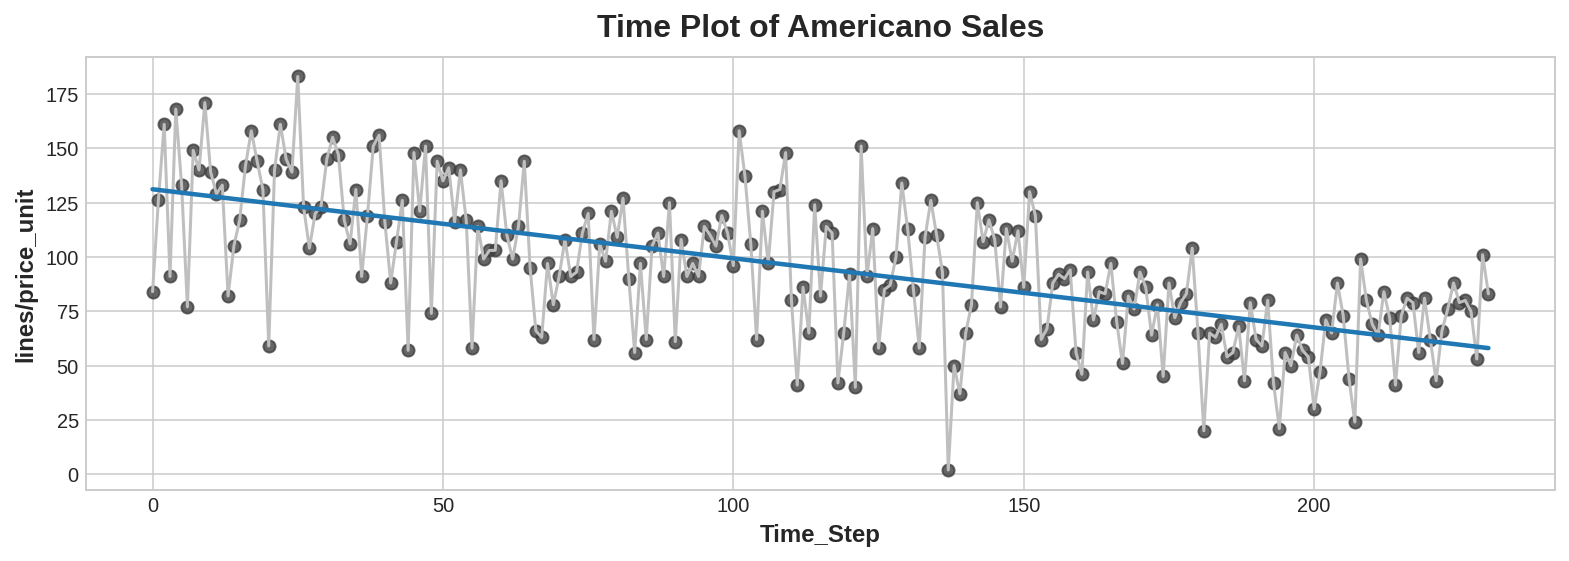

In [ ]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout = True, figsize = (11,4),
      titlesize = 18, titleweight = "bold",)
plt.rc("axes", labelweight = "bold", labelsize = "large",
      titleweight = "bold", titlesize = 16, titlepad = 10,)
%config InlineBackend.figure_format = 'retina'
fig, ax = plt.subplots()
ax.plot("Time_Step", "lines/price_unit", data = day, color = "0.75")
ax = sns.regplot(x="Time_Step", y = "lines/price_unit", data = day,
                ci = None, scatter_kws = dict(color = "0.25"))
ax.set_title("Time Plot of Americano Sales")
plt.show()

In [ ]:
day.rename(columns = {"lines/price_unit":"num_prod"}, inplace = True)


In [ ]:

day['Lag_1'] = day['num_prod'].shift(1)
day["Lag_2"] = day["num_prod"].shift(2)
day["Lag_3"] = day["num_prod"].shift(3)
day["Lag_4"] = day["num_prod"].shift(4)
day["Lag_5"] = day["num_prod"].shift(5)
day["Lag_6"] = day["num_prod"].shift(6)
day["Lag_7"] = day["num_prod"].shift(7)
day["Lag_8"] = day["num_prod"].shift(8)
day["Lag_9"] = day["num_prod"].shift(9)
day["Lag_10"] = day["num_prod"].shift(10)

day_ = day.reindex(columns=['num_prod', 'Lag_1'])

day_.head()

,num_prod,Lag_1
days,,
2021-06-14,84,NaN
2021-06-15,126,84.0
2021-06-16,161,126.0
2021-06-17,91,161.0
2021-06-18,168,91.0


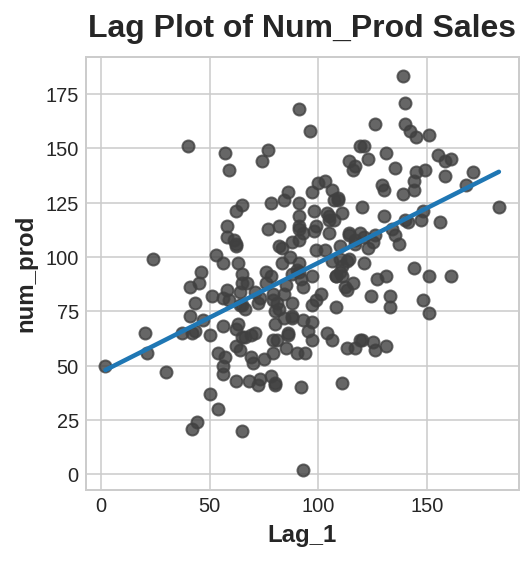

In [ ]:
fig, ax = plt.subplots()
ax = sns.regplot(x='Lag_1', y='num_prod', data=day_, ci=None, scatter_kws=dict(color='0.25'))
ax.set_aspect('equal')
ax.set_title('Lag Plot of Num_Prod Sales');
# Quando existe essa correlação com a lag e numero de vendas
# essa feature pode ser util
# Vendas altas no dia anterior indicam vendas altas no dia seguinte


In [ ]:
day.corr()

,num_prod,Time_Step,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
num_prod,1.000000,-0.639144,0.503851,0.440540,0.366658,0.370280,0.383140,0.463755,0.612391,0.457621,0.352746,0.350672
Time_Step,-0.639144,1.000000,-0.640851,-0.646559,-0.643509,-0.643716,-0.644847,-0.645791,-0.648558,-0.648968,-0.647666,-0.643372
...,...,...,...,...,...,...,...,...,...,...,...,...
Lag_9,0.352746,-0.647666,0.457243,0.614109,0.462092,0.380093,0.368808,0.363586,0.438845,0.503710,1.000000,0.501198
Lag_10,0.350672,-0.643372,0.352533,0.461435,0.610852,0.460914,0.379305,0.367716,0.364220,0.437587,0.501198,1.000000


In [ ]:
from sklearn.linear_model import LinearRegression

x = day.loc[:,["Time_Step"]]
y = day.loc[:,"num_prod"]

model = LinearRegression()
model.fit(x,y)

y_pred = pd.Series(model.predict(x), index = x.index)
y_pred

days
2021-06-14    131.116249
2021-06-15    130.798543
                 ...    
2022-01-31     58.361630
2022-02-01     58.043924
Freq: D, Length: 231, dtype: float64

In [ ]:
print(model.coef_, model.intercept_)

[-0.31770576] 131.1162486938349


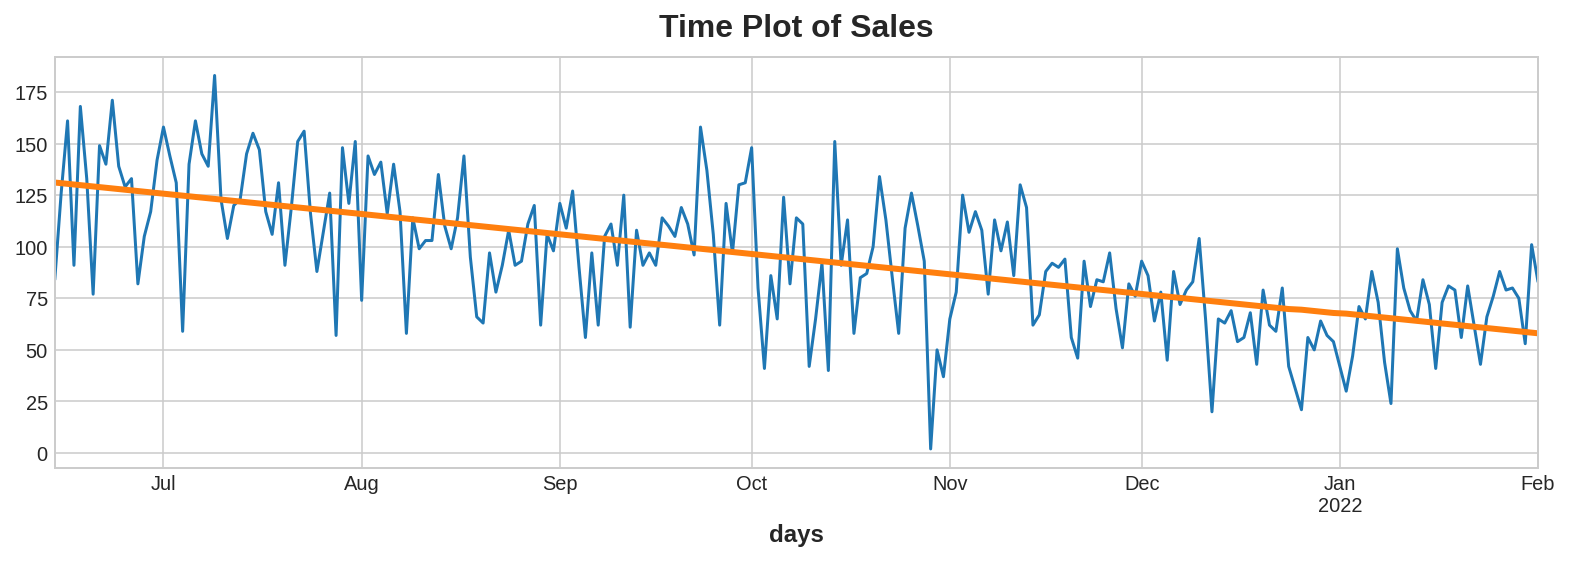

In [ ]:
ax = y.plot()
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Sales');

In [ ]:
day

,num_prod,Time_Step,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
days,,,,,,,,,,,,
2021-06-14,84,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06-15,126,1,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-31,101,229,53.0,75.0,80.0,79.0,88.0,76.0,66.0,43.0,62.0,81.0
2022-02-01,83,230,101.0,53.0,75.0,80.0,79.0,88.0,76.0,66.0,43.0,62.0


In [ ]:
x

,Time_Step
days,
2021-06-14,0
2021-06-15,1
...,...
2022-01-31,229
2022-02-01,230


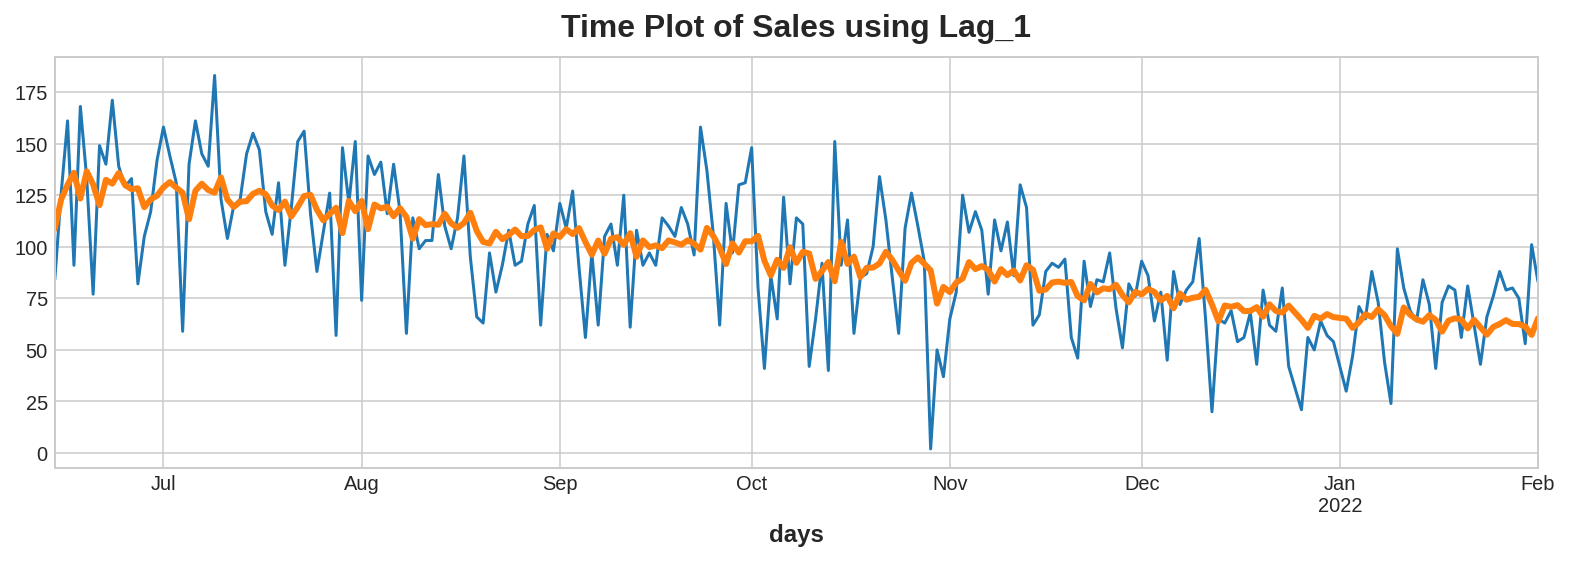

Train RMSE Days: 25.06



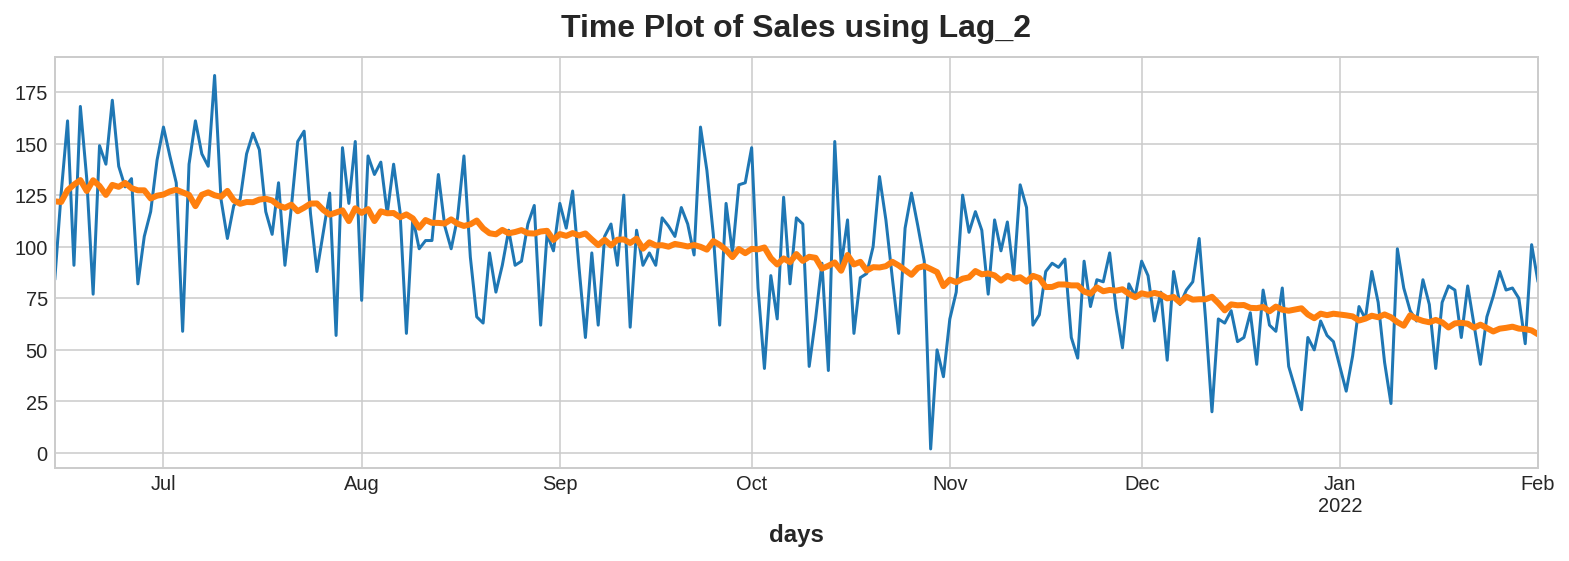

Train RMSE Days: 25.41



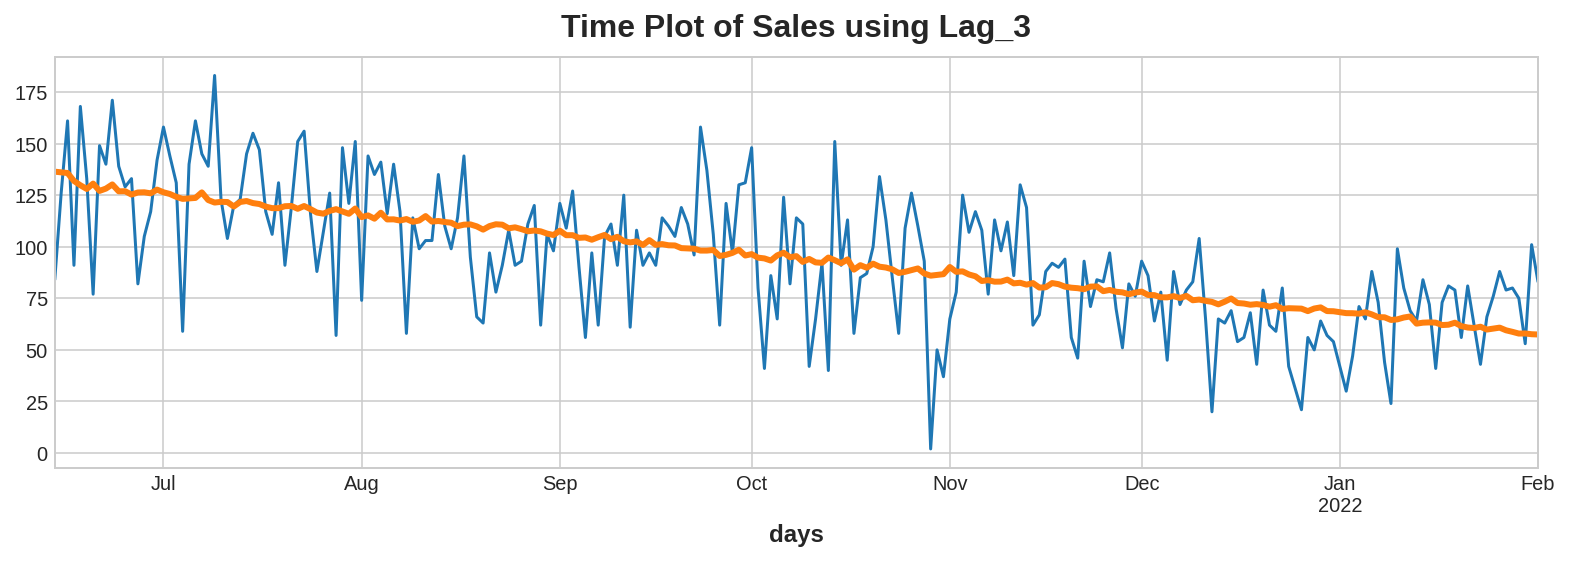

Train RMSE Days: 25.46



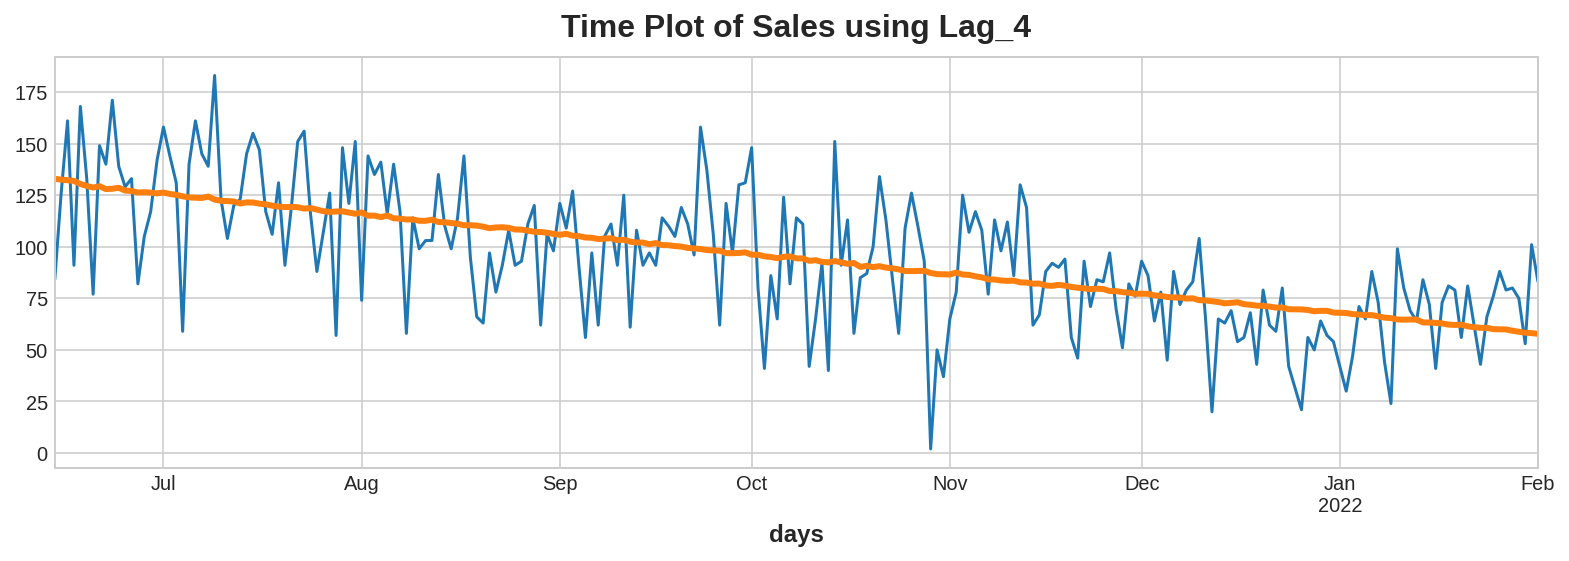

Train RMSE Days: 25.49



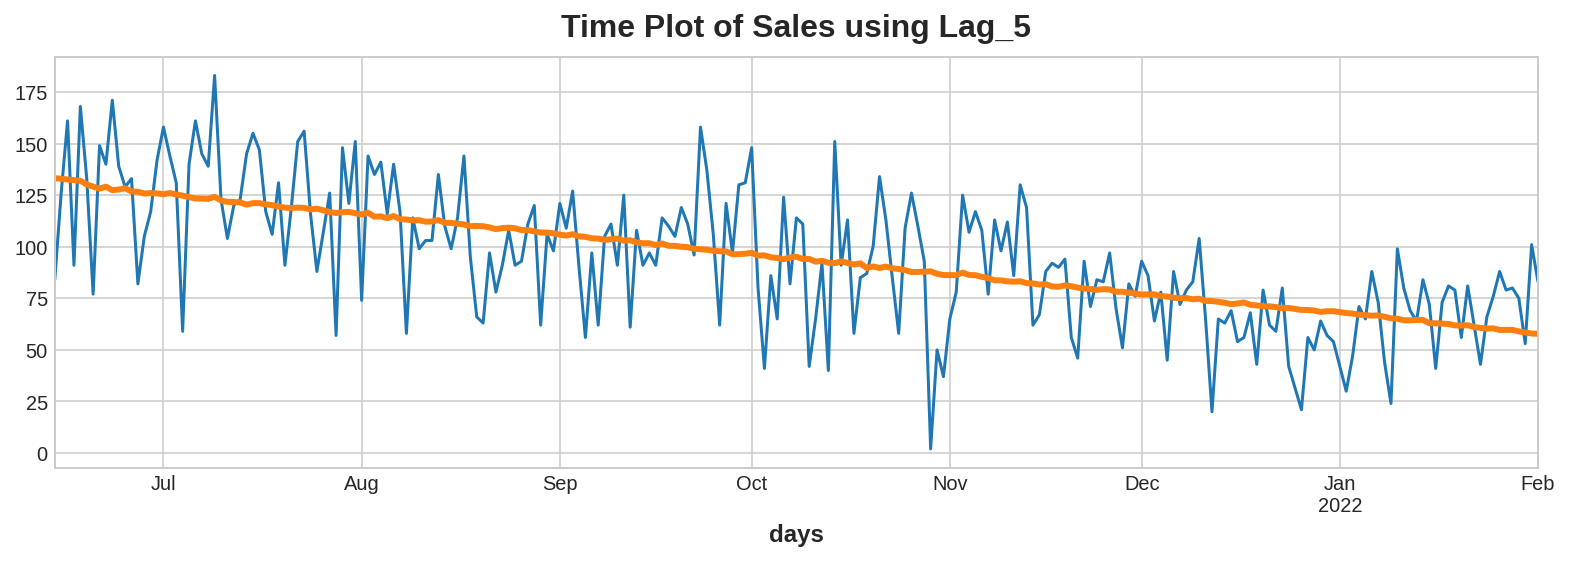

Train RMSE Days: 25.49



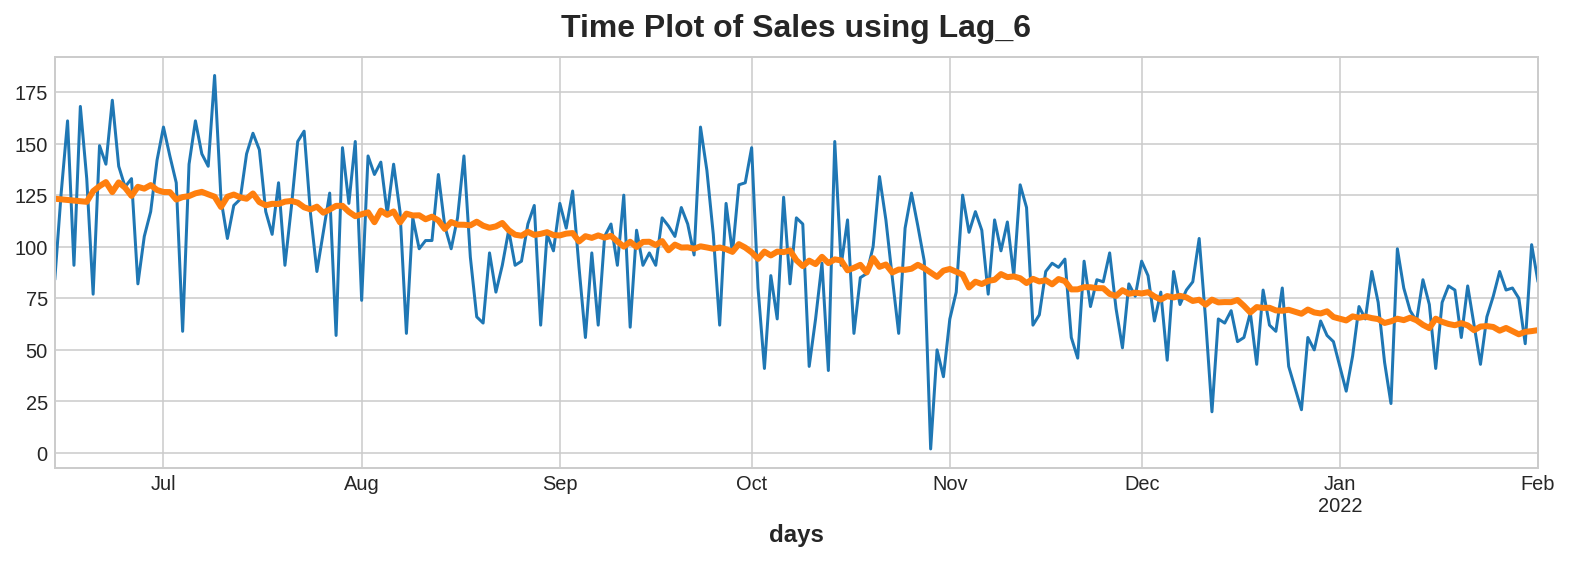

Train RMSE Days: 25.41



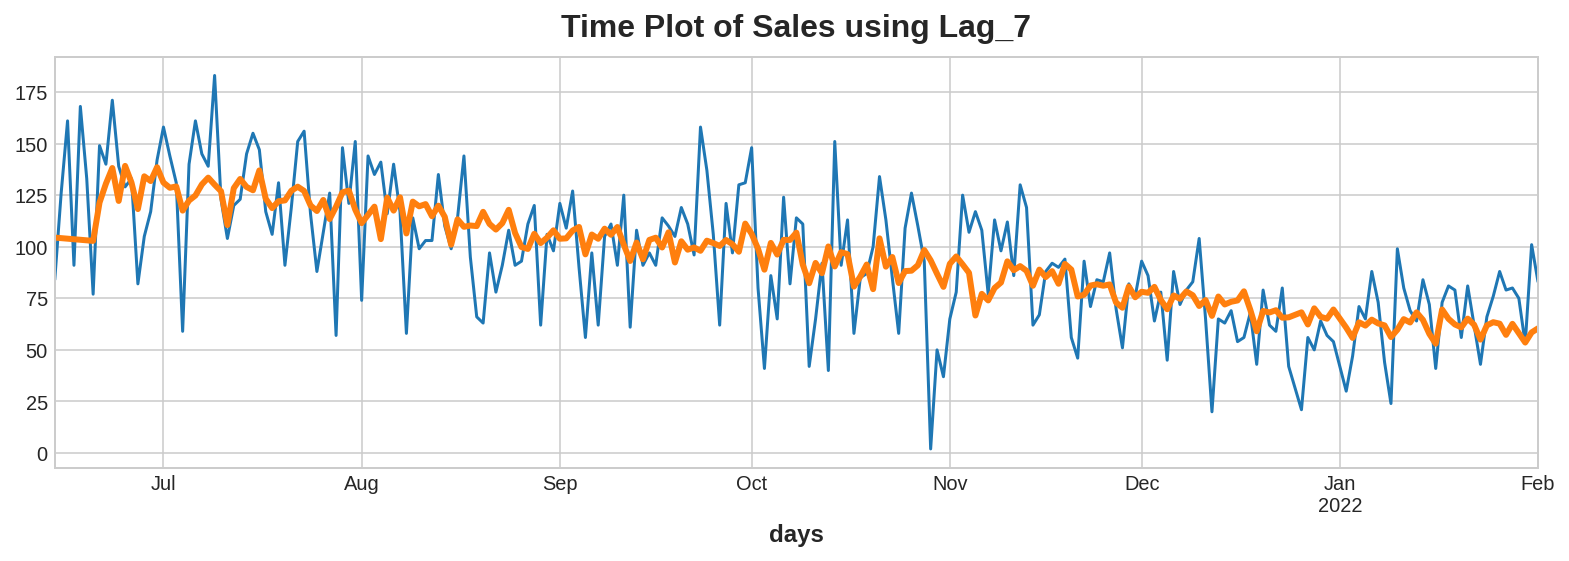

Train RMSE Days: 24.37



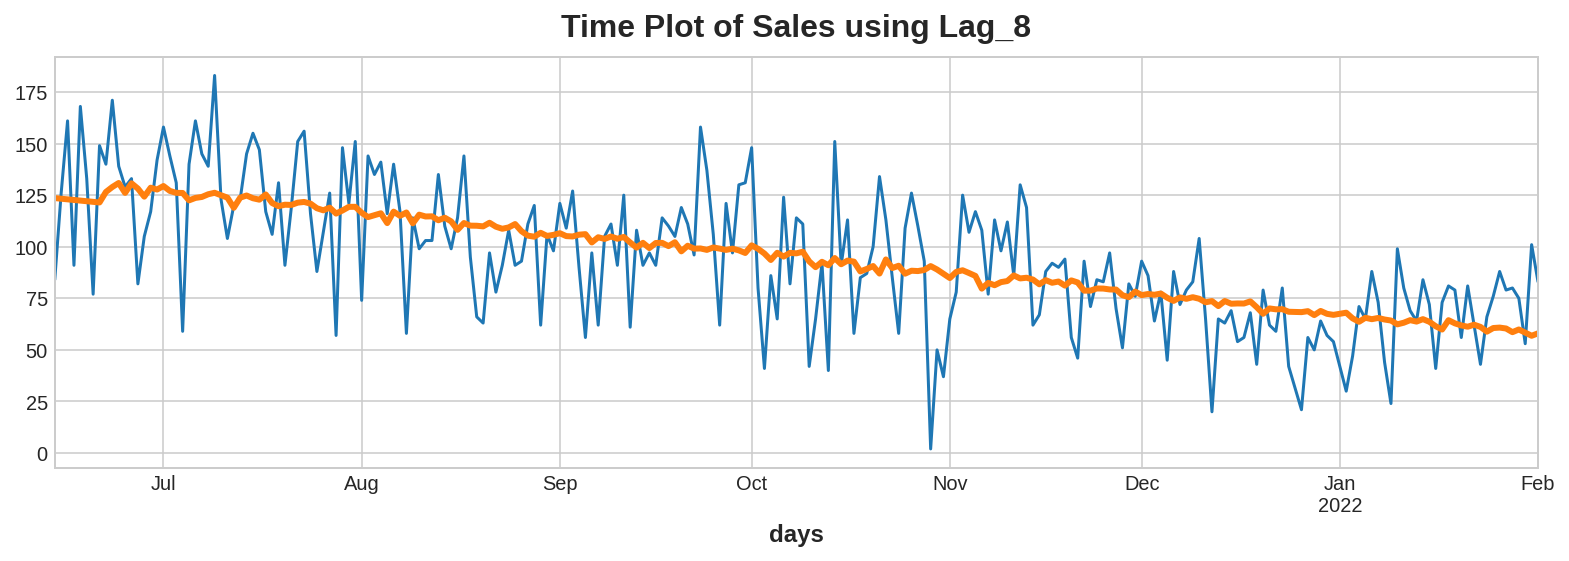

Train RMSE Days: 25.40



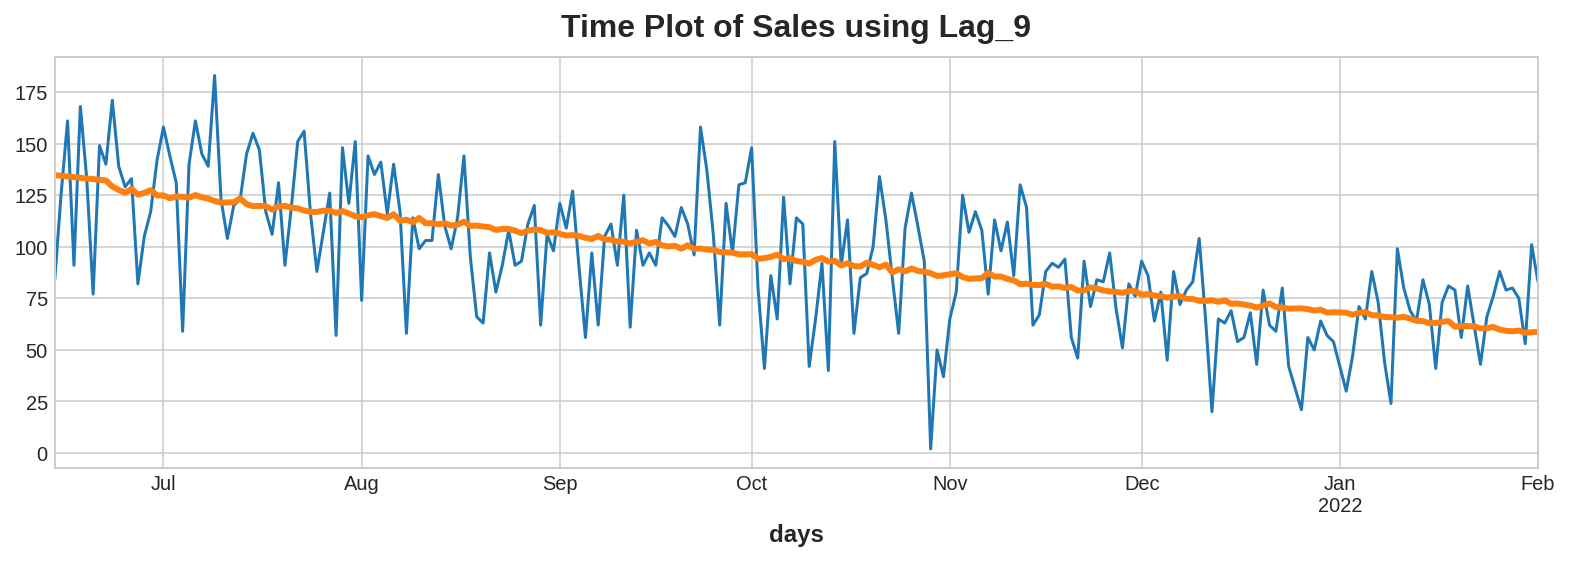

Train RMSE Days: 25.47



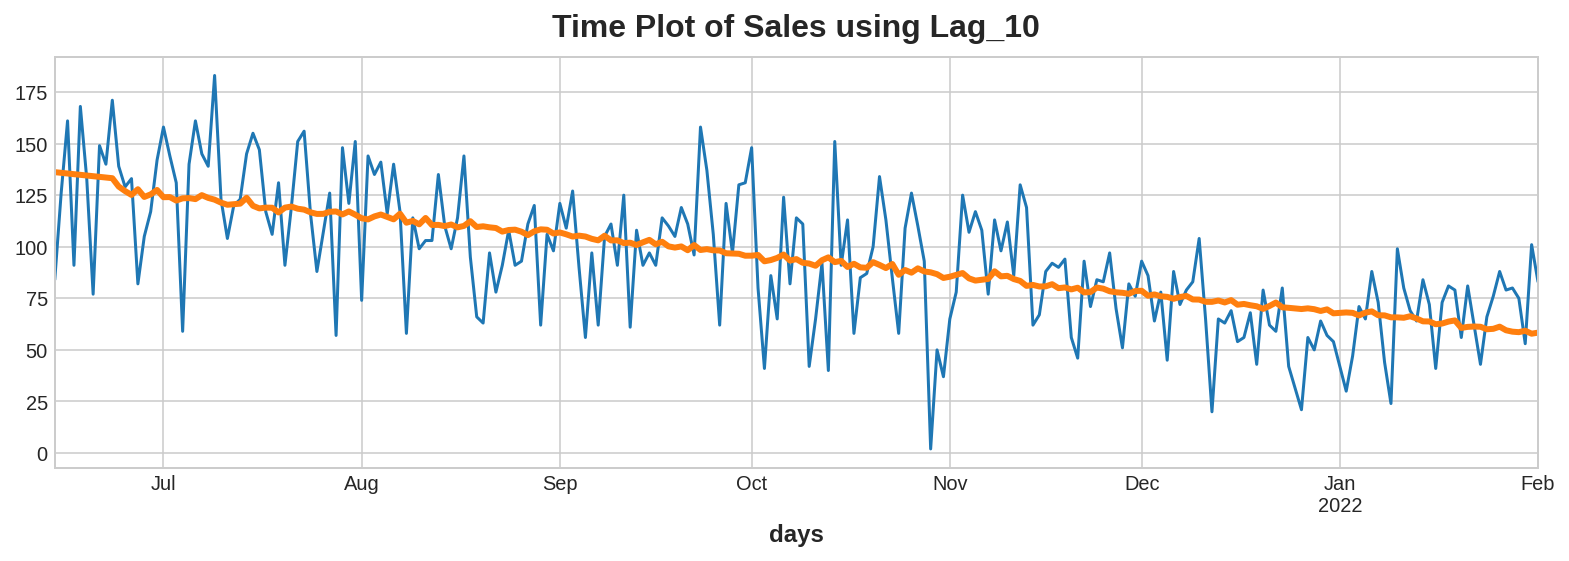

Train RMSE Days: 25.44



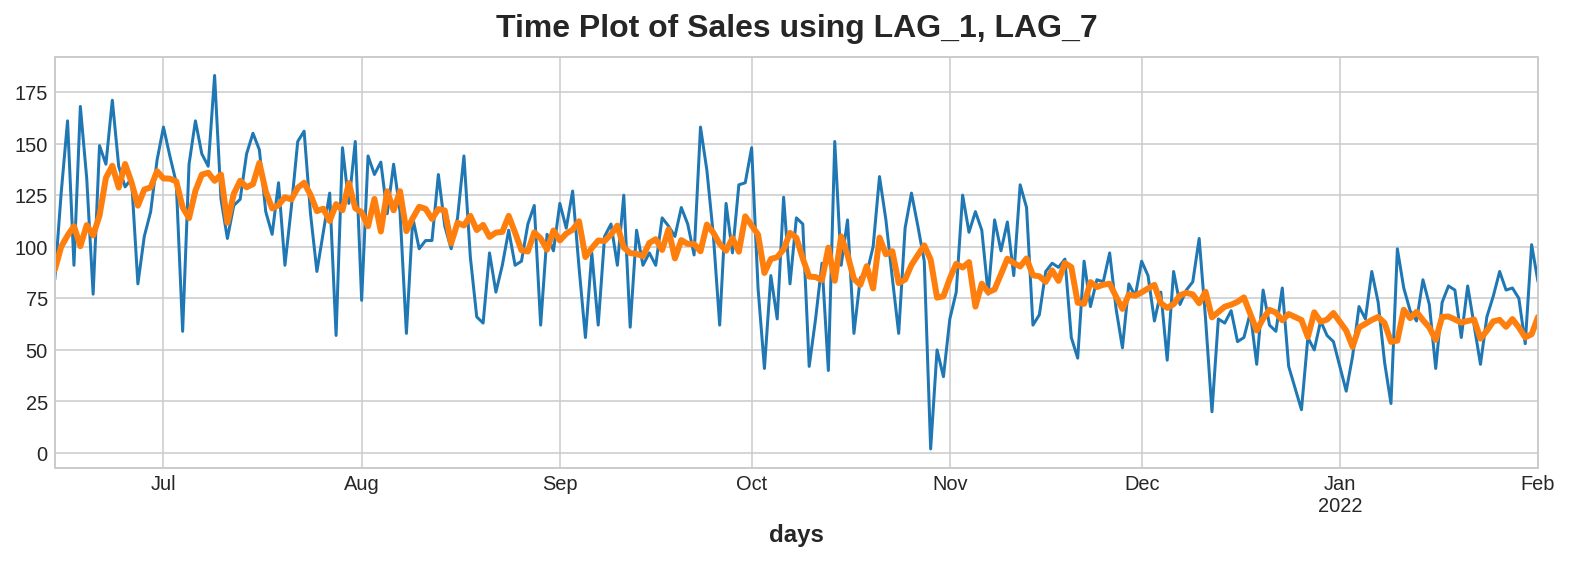

Train RMSE Days: 24.11



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
for pos, i in enumerate(day.columns):
    if i == "num_prod":
        next
    elif i == "Time_Step":
        next
    else:
        x = day.loc[:,["Time_Step",i]].fillna(0)
        y = day.loc[:,"num_prod"]
        model = LinearRegression()
        model.fit(x,y)

        y_pred = pd.Series(model.predict(x), index = x.index)
        y_pred

        ax = y.plot()
        ax = y_pred.plot(ax=ax, linewidth=3)
        ax.set_title(f'Time Plot of Sales using {i}')
        plt.show()
        rmse = mean_squared_error(y, y_pred, squared=False)

        print(f"Train RMSE Days: {rmse:.2f}\n")
x = day.loc[:,["Time_Step","Lag_1","Lag_7"]].fillna(0)
y = day.loc[:,"num_prod"]
model = LinearRegression()
model.fit(x,y)

y_pred = pd.Series(model.predict(x), index = x.index)
y_pred

ax = y.plot()
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title(f'Time Plot of Sales using LAG_1, LAG_7')
plt.show()
rmse = mean_squared_error(y, y_pred, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")

#### TRENDS IN SERIES TEMPORAIS

Representa o termo que varia de forma devagar, um aumento ou decréscimo nas medias da serie.

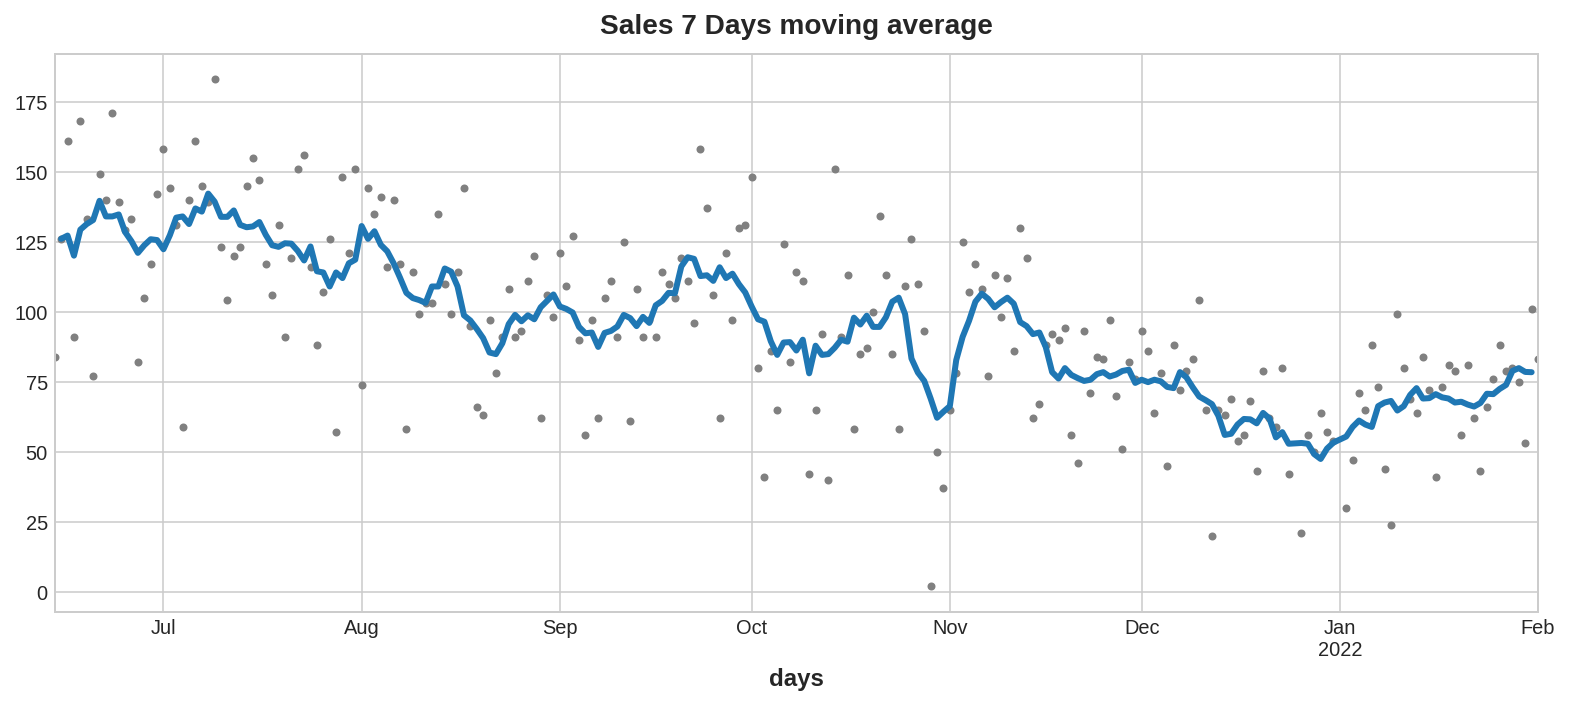

In [ ]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'

moving_average = day["num_prod"].rolling(window = 7,
                           center = True,
                           min_periods = 5).mean()
moving_average
ax = day["num_prod"].plot(style = ".", color = "0.5")
moving_average.plot(ax = ax, linewidth = 3,
                    title = "Sales 7 Days moving average",
                    legend = False)
plt.show()

In [ ]:
pip install statsmodels

In [ ]:
### OUTRA FORMA MELHOR DE FAZER TIME_STEP
# PARA AVALIAR SE A RELAÇÃO É LINEAR OU NAO NA TREND
from statsmodels.tsa.deterministic import DeterministicProcess

dp = DeterministicProcess(
    index=day["num_prod"].index,  # dates from the training data
    constant=True,       # dummy feature for the bias (y_intercept)
    order=1,             # the time dummy (trend), pode ser quad, cubica, etc
    drop=True,           # drop terms if necessary to avoid collinearity
)
# `in_sample` creates features for the dates given in the `index` argument
X = dp.in_sample()

X.head()

ModuleNotFoundError: ignored

In [ ]:
y = day["num_prod"]
model = LinearRegression()
model.fit(X,y)
y_pred = pd.Series(model.predict(X), index = X.index)

Train RMSE Days: 25.94



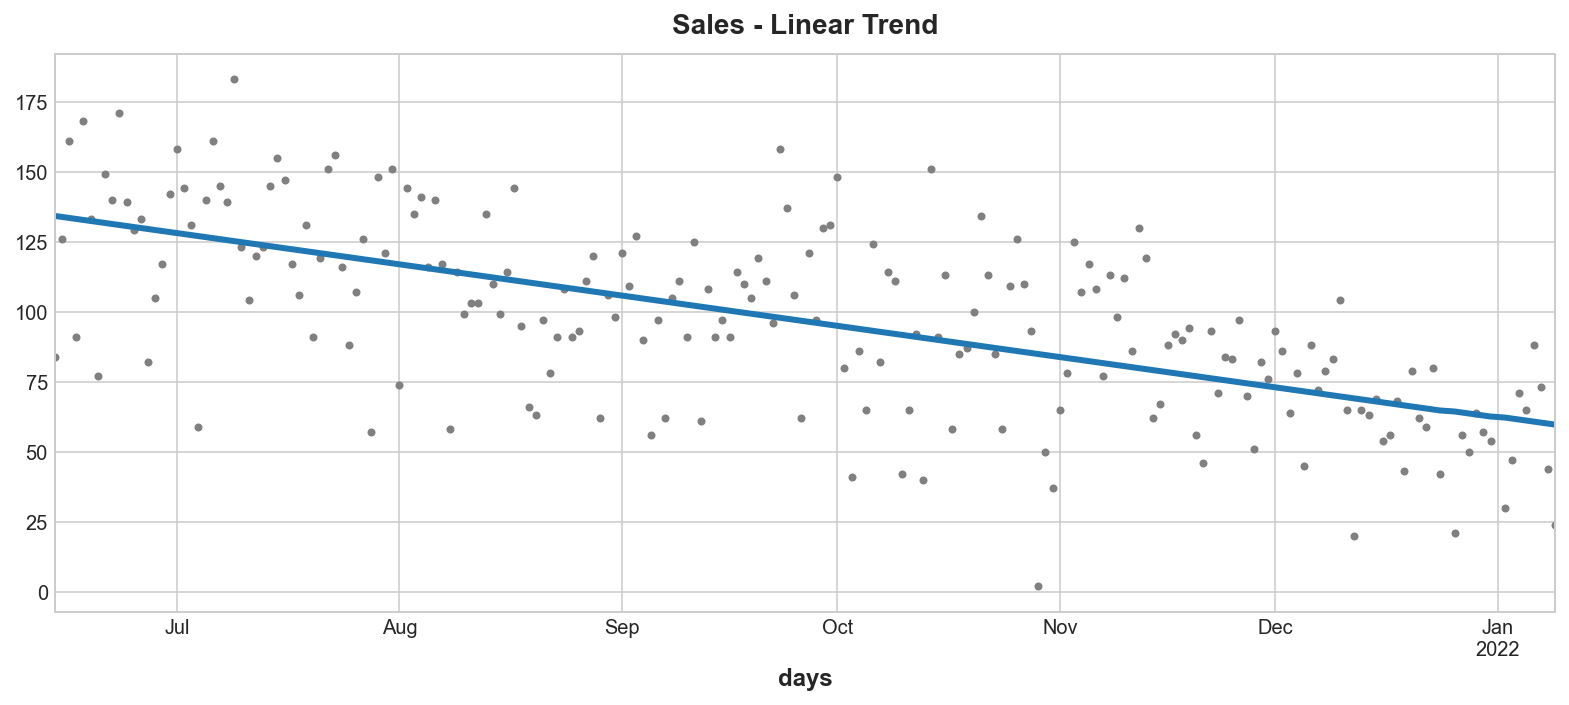

In [ ]:
ax = day["num_prod"].plot(style=".", color="0.5", title="Sales - Linear Trend")
_ = y_pred.plot(ax=ax, linewidth=3, label="Trend")
rmse = mean_squared_error(y, y_pred, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")

In [ ]:
## TESTE OUTRAS ORDENS E VEJA QUE A 1ORDEM QUE MAIS SE APROXIMA
## DA MAKING AVERAGE, SUGERINDO QUE UMA TREND LINEAR É A MELHOR

In [ ]:
X = dp.out_of_sample(steps=30)

y_fore = pd.Series(model.predict(X), index=X.index)

y_fore.head()

2022-01-10    59.335145
2022-01-11    58.975314
2022-01-12    58.615483
2022-01-13    58.255651
2022-01-14    57.895820
Freq: D, dtype: float64

In [ ]:
### Modelo é util para baseline
## Além disso, serve para modelos hibridos
## em que o algoritmo nao consegue capturar trends
## exemplos disso sao random forest e xgboost


#### SAZONALIDADE EM SERIES TEMPORAIS

Uma time series possui sazonalidade quando existe uma regularidade de mudanças periódicas na média das séries. Sazonalidade em geral segue o calendário, repetindo por meio dos intervalos. Ciclos naturais do mundo por uma convenção social de comportamento ao longo do tempo. Exemplo, comprar mais cafe no frio e mais sorvete no calor

Assim como usamos moving average plot para pegar a trend, podemos usar seazonal plot para descobrir as características sazonais.

Ele mostra segmentos de tempo sobre períodos comuns, cada período é uma sessão.

**1) modelo para sazonalidade, quando se tem poucos dados**
Indicadores de sazonalidade sao binarios e representam diferenças no nivel da serie. É o que voce obtem se tratar um periodo como categórico e aplicar one hot encoder.

Por exemplo, voce pode considerar os dias da semana como influenciadores, por exemplo, cinema tem sazonalidade no fim de semana, para o modelo captar isso, faz one hot encoder de todos os dias da semana, assim quando for um na sexta, sabado ou domingo, o modelo saberá que ali tem sazonalidade. Esse caso é para sazonalidades com poucas mudanças. 7 dias por exemplo.

**2) Modelo para sazonalidade quando se tem mais dados**

Fourier Features and the Periodogram -> Quando temos temporadas/períodos maiores para apresentar a sazonalidade (por exemplo considerar horas do dia) o indicators torna-se impraticável, porque teríamos que criar uma feature para cada data. A Fourier Features tenta capturar uma media da sazonalidade com apenas algumas features.

Um exemplo é o das estações do ano, se formos fazer semanal, temos 52 semanas e 3 ou 4 movimentos ciclicos de sazonalidade. A ideia é incluir no dado de treinamento curvas com períodos de frequencia igual ao do período que tentaremos modelar.

Fourier Features sao pares de seno e cosseno, um par para cada frequencia potencial  na temporada, começando com a mais longa. Os pares de fourier que modelam a sazonalidade anual teriam frequencias 1 vez por ano, duas vezes, tres, etc.

Se nos adicionarmos essas curvas ao nosso dado de treinamento, o modelo conseguirá implicar pesos que nessas curvas que modelarao o componente de sazonalidade. Exemplo para linear Regression isso. Esse modelo de fourier, é muito melhor que o de indicadores quando tenho sazonalidade demorada, porque necessito de muito menas features, reduzindo tempo computacional e overfitting

Quantas features de fourier usar? Usamos o periodogram para responder isso. Ele dita as forças das frequencias da serie. A imagem abaixo, mostra isso, o eixo y é (a^2 + b^2)/2 onde a e b sao os coeficientes do par seno cosseno naquela frequencia

![image.png](attachment:2b37a456-83a4-4ea6-b2eb-eb3f4877c182.png)![image.png](attachment:f3d0aedb-bb85-43e1-8835-98012b6fcef1.png)

Note que da esquerda para a direita, o periodograma cai após a quadrimestral (4 vezes ao ano) Neste caso escolheriamos 4 pares de frequencia anual. A frequencia semanal ignoramos porque é melhor para o indicadores

A seguir veremos como computar as features de fourier, derivando elas do tempo da time series. Posteriormente usaremos funções da statsmodels.


In [ ]:
day_ = day["num_prod"]

In [ ]:
def fourier_features(index, freq, order):
    time = np.arange(len(index), dtype = np.float32)
    j = 2*np.pi*(1/freq)*time  # note que aqui o time nao é período
    features = {} # order é quantas vezes no ano, como era 4 no ex.
    for i in range(1, order + 1):
        features.update({f"sin_{freq}_{i}":np.sin(i*j),
                         f"cos_{freq}_{i}":np.cos(i*j)})


    return pd.DataFrame(features, index = index)

# Compute Fourier features to the 4th order (8 new features) for a
# series y with daily observations and annual seasonality:
#
# fourier_features(y, freq=365.25, order=4)

In [ ]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

simplefilter("ignore")

# Set matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout = True, figsize = (11,5))
plt.rc("axes", labelweight = "bold",
      labelsize = "large", titleweight = "bold",
      titlesize = 16, titlepad = 10)
plot_params = dict(color = "0.75", style = ".-",
                   markeredgecolor = "0.25",
                   markerfacecolor = "0.25",
                   legend = False)

%config InlineBackend.figure_format = "retina"

# annotations: https://stackoverflow.com/a/49238256/5769929
def seasonal_plot(X,y, period, freq, ax = None):
    if ax is None:
        _, ax = subplots()
    palette = sns.color_palette("husl", n_colors = X[period].nunique(),)
    ax = sns.lineplot(x = freq, y = y, hue = period, data = X,
                      ci = False, ax = ax, palette = palette, legend = False)

    ax.set_title(f'Seazonal Plot ({period}/{freq})')
    for line, name in zip(ax.lines, X[period].unique()):

        y_ = line.get_ydata()[-1]

        ax.annotate(name, xy=(1,y_),
                    xytext=(6,0),color = line.get_color(),
                    xycoords=ax.get_yaxis_transform(),
                    textcoords="offset points",
                    size = 14, va = "center")

    return ax


def plot_periodogram(ts, detrend = "linear", ax = None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("1Y")/pd.Timedelta("1D")
    frequencies, spectrum = periodogram(ts, fs=fs,
                                        detrend = detrend,
                                        window = "boxcar",
                                        scaling = "spectrum")

    if ax is None:
        _, ax = plt.subplots()
    ax.step(frequencies, spectrum, color = "purple")
    ax.set_xscale("log")
    ax.set_xticks([1,2,4,6,12,26,52,104])
    ax.set_xticklabels([
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis = "y", style = "sci",
                        scilimits = (0,0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax



In [ ]:
def sem(x):
    if (x>1)&(x<=7):
        return 1
    elif (x>7)&(x<=14):
        return 2
    elif (x>14)&(x<=21):
        return 3
    elif (x>21)&(x<=28):
        return 4
    else:
        return 5


p = dados[dados["café"]==1.0].groupby("days")["lines/price_unit"].count()

p = pd.DataFrame(p)
p["Time_Step"] = np.arange(len(p.index))


#p = pd.DataFrame(dados.groupby("days")["lines/price_unit"].sum())
p["day"] = p.index.dayofweek
p["week"] = p.index.week

p["day_month"] = p.index.day

p["week_in_month"] = pd.Series(p.index.day, index = p.index).apply(sem)
p["month"] = p.index.month

p["dayofyear"] = p.index.dayofyear
p["year"] = p.index.year
p = p.rename(columns = {"lines/price_unit":"num_prod"})


LEMBRAR DE USAR COM MONTH TAMBEM, PORQUE TEM QUE TER UM PERIODO QUE REPETE, SENAO ELE FICA SO UMA JANELA COMO NO DE ANO

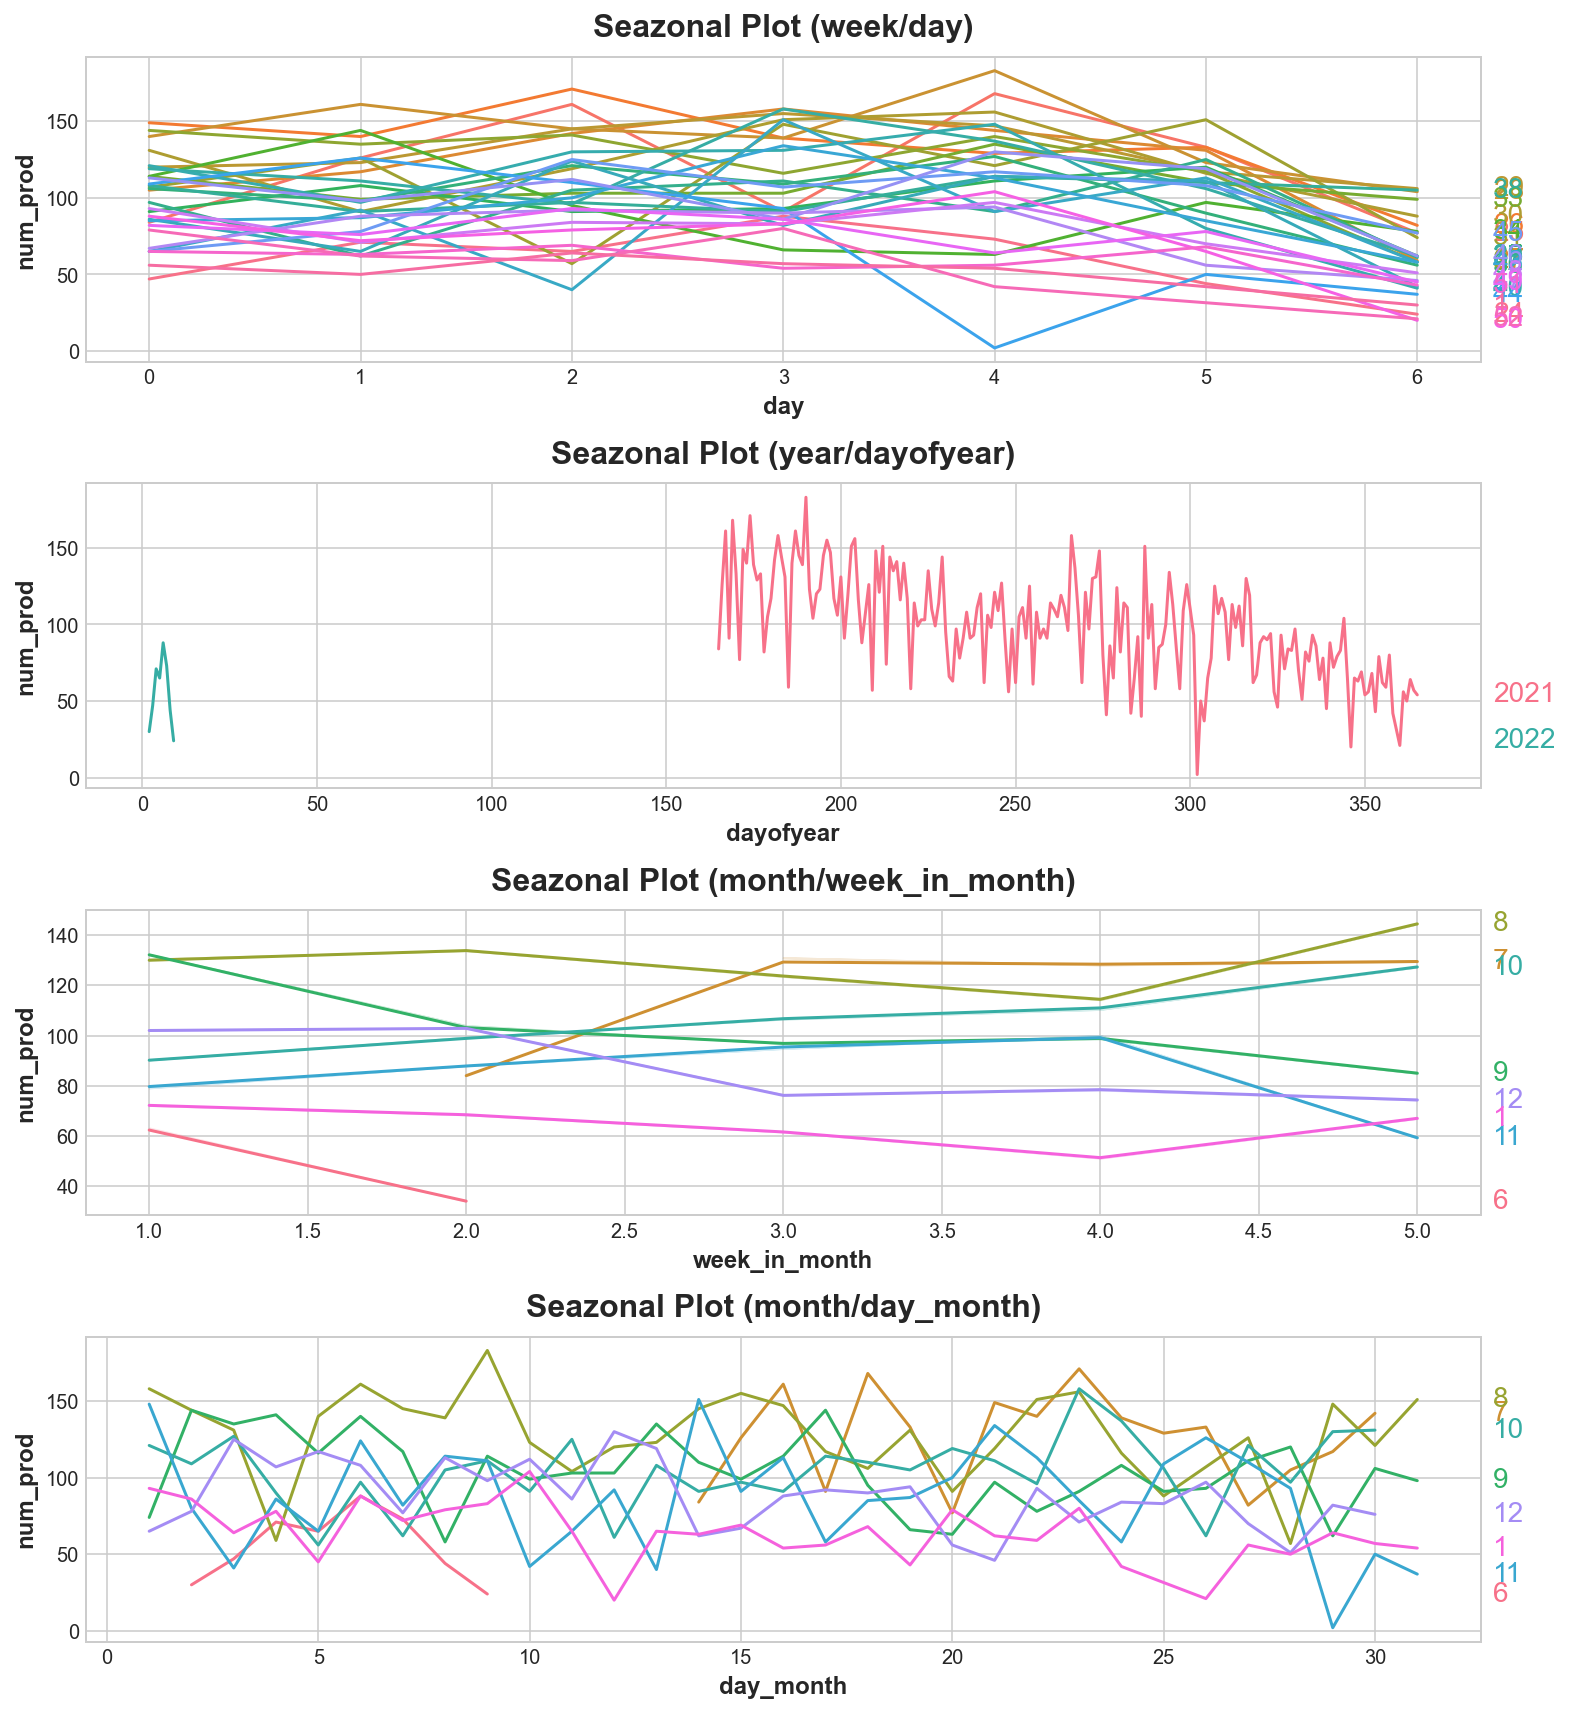

In [ ]:
fig, (ax0, ax1, ax2, ax3) = plt.subplots(4, 1, figsize=(11, 12))
seasonal_plot(p, y="num_prod", period="week", freq="day", ax=ax0)
seasonal_plot(p, y="num_prod", period="year", freq="dayofyear", ax=ax1)
seasonal_plot(p, y="num_prod", period="month", freq="week_in_month", ax=ax2)
seasonal_plot(p, y="num_prod", period="month", freq="day_month", ax=ax3);

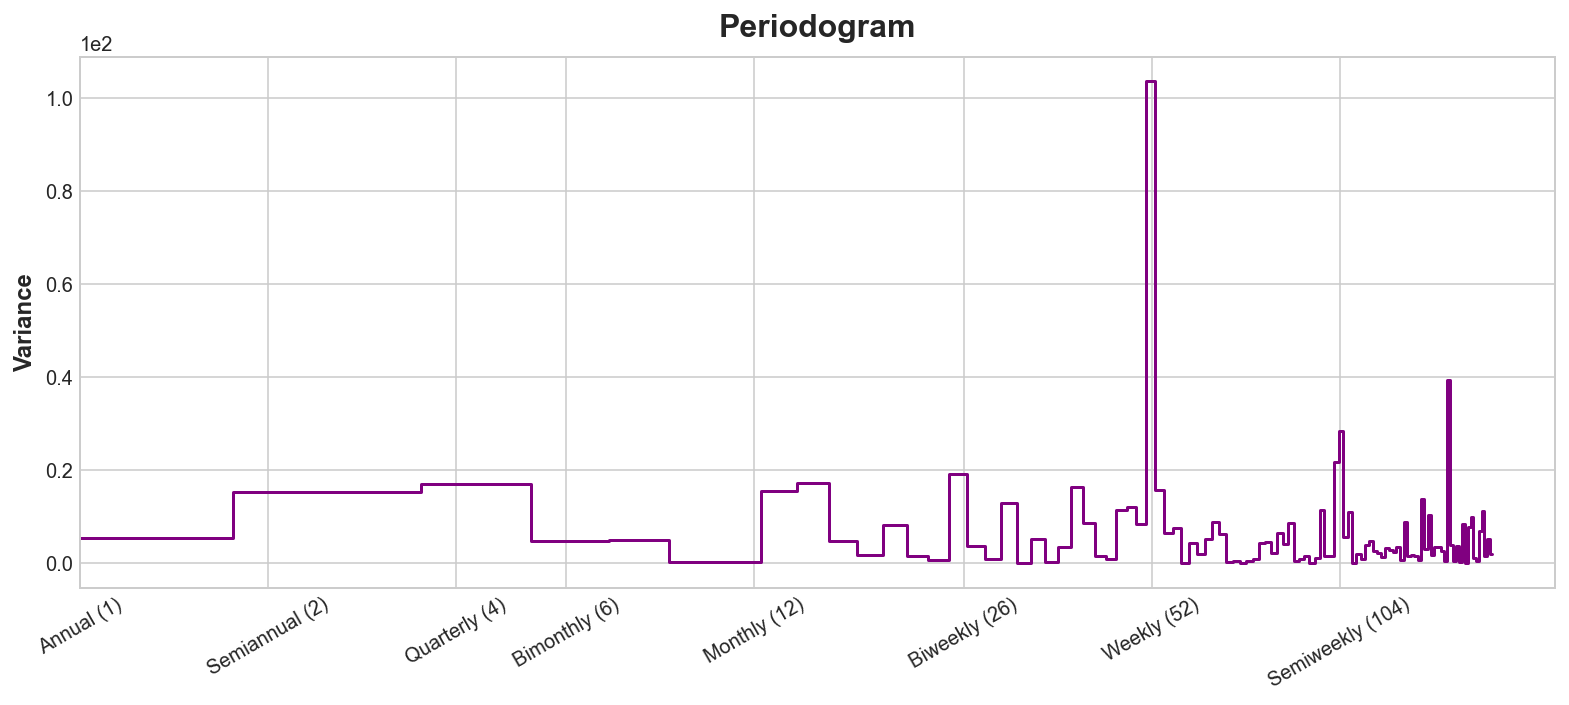

In [ ]:
plot_periodogram(p.num_prod);

# ATE AQUI DE BOA!

Train RMSE Days: 21.29



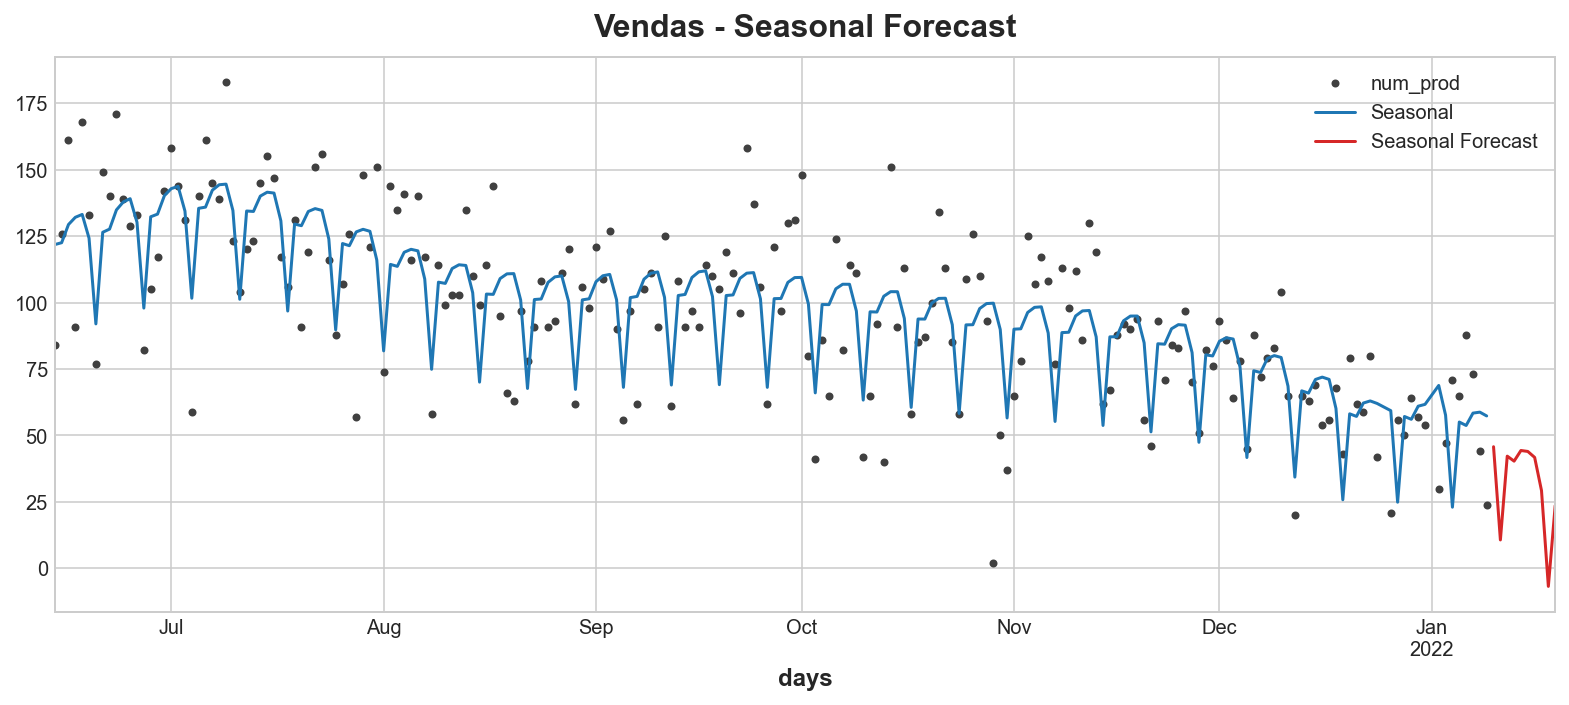

In [ ]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
fourier = CalendarFourier(freq="A", order=4)  # 12 sin/cos pairs for "A"nnual seasonality

dp = DeterministicProcess(
    index=p.index,
    period = 7,
    constant=True,               # dummy feature for bias (y-intercept)
    order=1,                     # trend (order 1 means linear)
    seasonal=True,               # weekly seasonality (indicators)
    additional_terms=[fourier],  # annual seasonality (fourier)
    drop=True,                   # drop terms to avoid collinearity
)

X = dp.in_sample()  # create features for dates in tunnel.index
X

#Vamos extrapolar os dados para fazer predições

y = p["num_prod"]

model = LinearRegression(fit_intercept=False)
_ = model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=y.index)
X_fore = dp.out_of_sample(steps=10)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(color='0.25', style='.', title="Vendas - Seasonal Forecast")
ax = y_pred.plot(ax=ax, label="Seasonal")
ax = y_fore.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()
rmse = mean_squared_error(y, y_pred, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")



In [ ]:
X["lag1"] = y.shift(1)
X['lag7'] = y.shift(7)
X

,const,trend,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=A-DEC)","cos(1,freq=A-DEC)","sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)",lag1,lag7
days,,,,,,,,,,,,,,,,,,
2021-06-14,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.313107,-0.949718,-0.594727,0.803928,0.816538,-0.577292,-0.956235,0.292600,NaN,NaN
2021-06-15,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.296713,-0.954967,-0.566702,0.823923,0.785650,-0.618671,-0.933837,0.357698,84.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-08,1.0,207.0,0.0,0.0,1.0,0.0,0.0,0.0,0.120208,0.992749,0.238673,0.971100,0.353676,0.935368,0.463550,0.886071,73.0,54.0
2022-01-09,1.0,208.0,0.0,0.0,0.0,1.0,0.0,0.0,0.137279,0.990532,0.271958,0.962309,0.401488,0.915864,0.523416,0.852078,44.0,30.0


In [ ]:
# NAO TEM COMO FAZER PREDICT USANDO O SHIFT PORQUE VAI FICAR VALOR NULO AONDE DEVERIA SER O LAG, A MENOS QUE EU DE LAG MAIOR

days
2021-06-14     84
2021-06-15    126
             ... 
2022-01-08     44
2022-01-09     24
Freq: D, Name: num_prod, Length: 208, dtype: int64

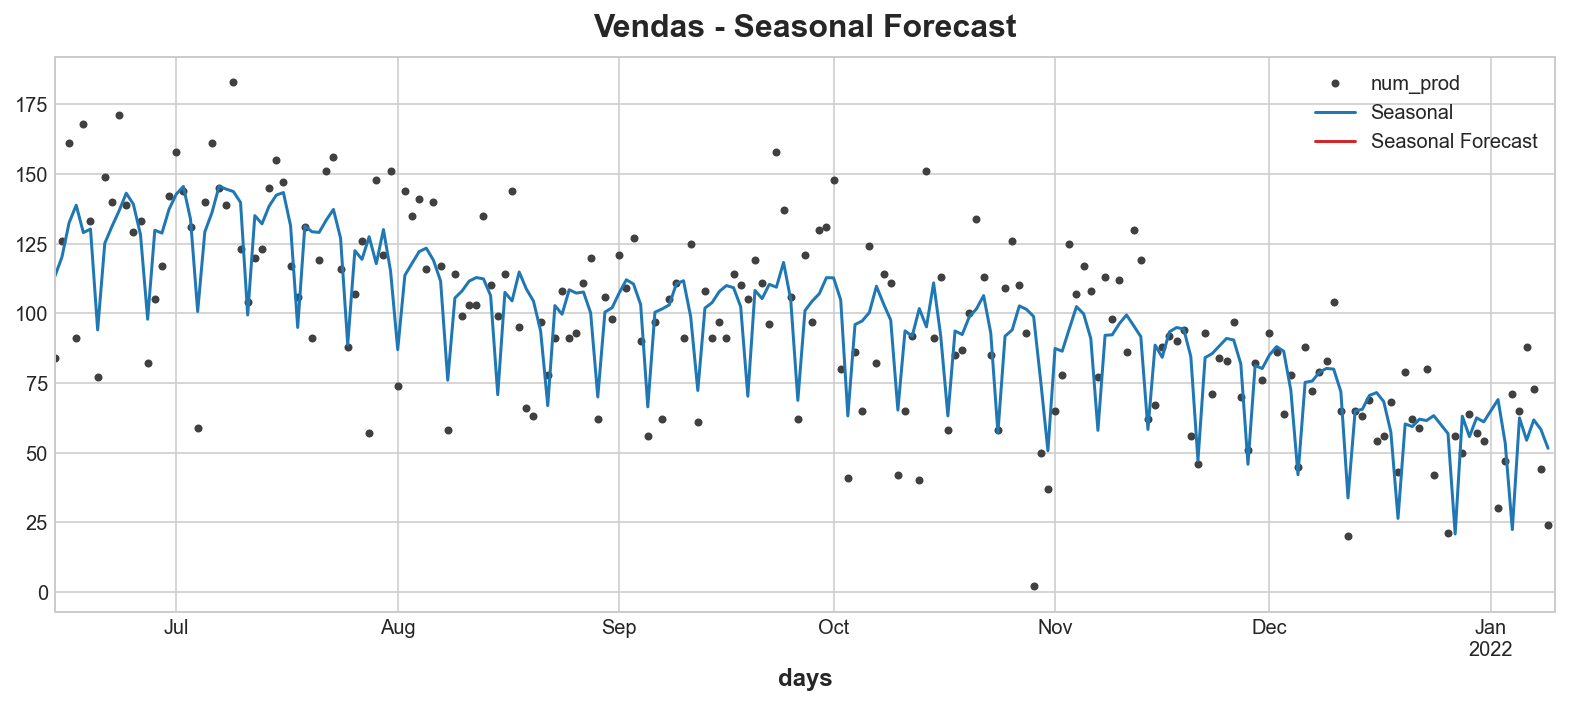

In [ ]:
y = p["num_prod"]
X = X.fillna(0)

model = LinearRegression(fit_intercept=False)
_ = model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=y.index)
X_fore = dp.out_of_sample(steps=1)
X_fore['lag1'] = y.iloc[y.shape[0]-1]
X_fore['lag7'] = y.iloc[y.shape[0]-7]
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(color='0.25', style='.', title="Vendas - Seasonal Forecast")
ax = y_pred.plot(ax=ax, label="Seasonal")
ax = y_fore.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()

#### TIME SERIES AS FEATURES

Anteriormente vimos propriedades para modelar dependencia no tempo. Algumas time series, entretanto, so podem ser modeladas com propriedades dependentes em série. Um exemplo disso, é o passado dos valores da target.

**Cycles**
One caminho especial e bem comum para série dependencia se manifestar é por ciclos. Ciclos são padrões de decaimento ou crescimento em uma time series associado a quanto o valor da serie depende de valores prévios mas não necessariamente do tempo. Comportamentos ciclicos em geral são feitos por sistemas que se afetam ao longo do tempo. Economia, epidemias, população de animais, e outros fenomenos naturais.

O que diferencia o comportamento ciclíco da sazonalidade é que ele nao precisa ser dependente do tempo. A (possivel) independencia do tempo significa que os cíclicos tem comportamento mais irregular que a sazonalidade

**Lagged Series and Lag Plots**

Para investigar a dependencia em serie em uma time series, precisamos criar lags, copias da serie. Colocar um lag numa time series significa shiftar os valores para frente de um step ou mais.


In [ ]:
k = day.copy()
k

,num_prod,Time_Step,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
days,,,,,,,,,,,,
2021-06-14,84,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06-15,126,1,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-08,44,206,73.0,88.0,65.0,71.0,47.0,30.0,54.0,57.0,64.0,50.0
2022-01-09,24,207,44.0,73.0,88.0,65.0,71.0,47.0,30.0,54.0,57.0,64.0


Fazendo o lagging da time series nos conseguimos fazer os valores do passado aparecerem com o valor do presente que queremos predizer (na mesma linha). Por isso é util usar lagging quando tem dependencia em série.

**Lag Plots**
mostra os valores da target plotados com os seus laggings, para ver alguma dependencia. Avaliamos pela autocorrelação.

''Autocorrelation is a correlation coefficient. However, instead of correlation between two different variables, the correlation is between two values of the same variable at times Xi and Xi+k.''

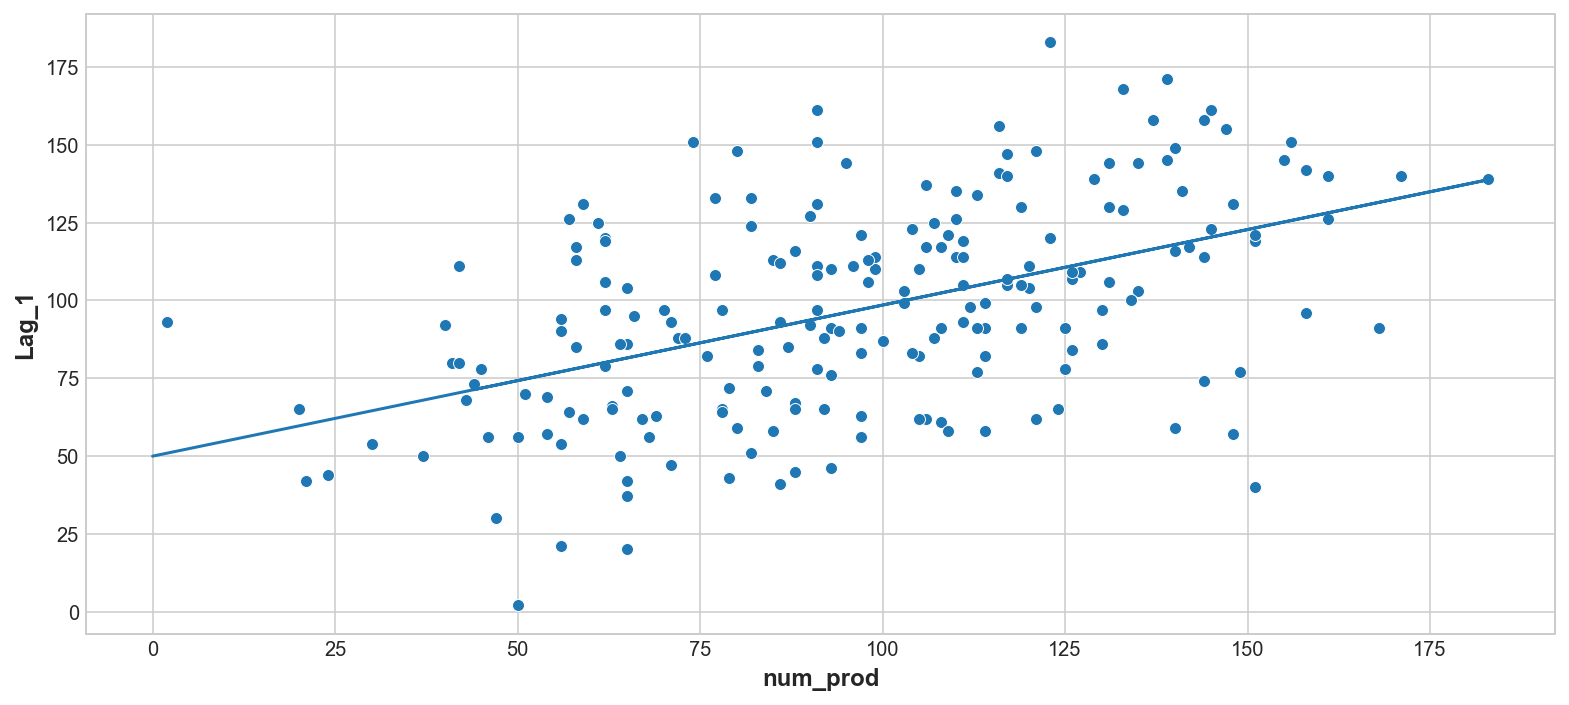

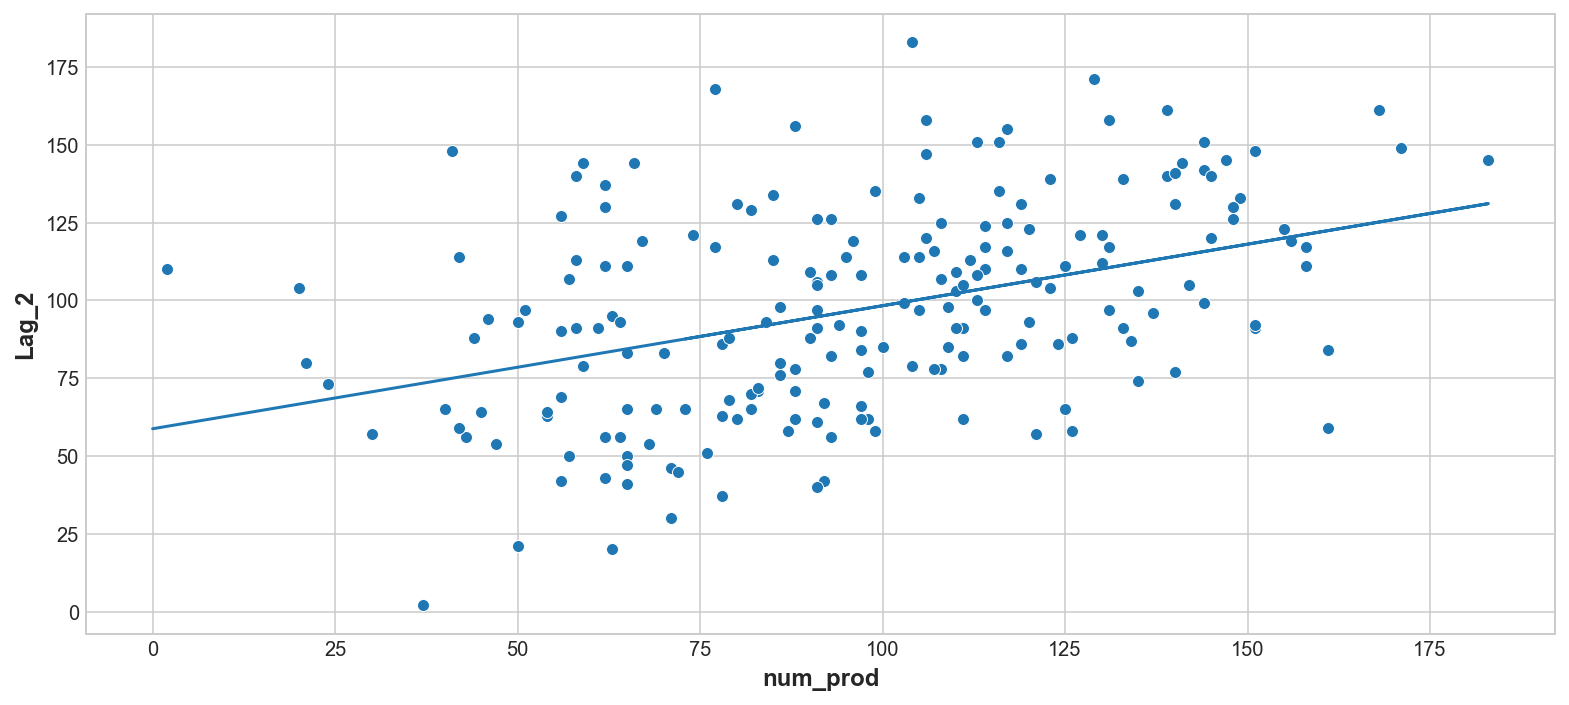

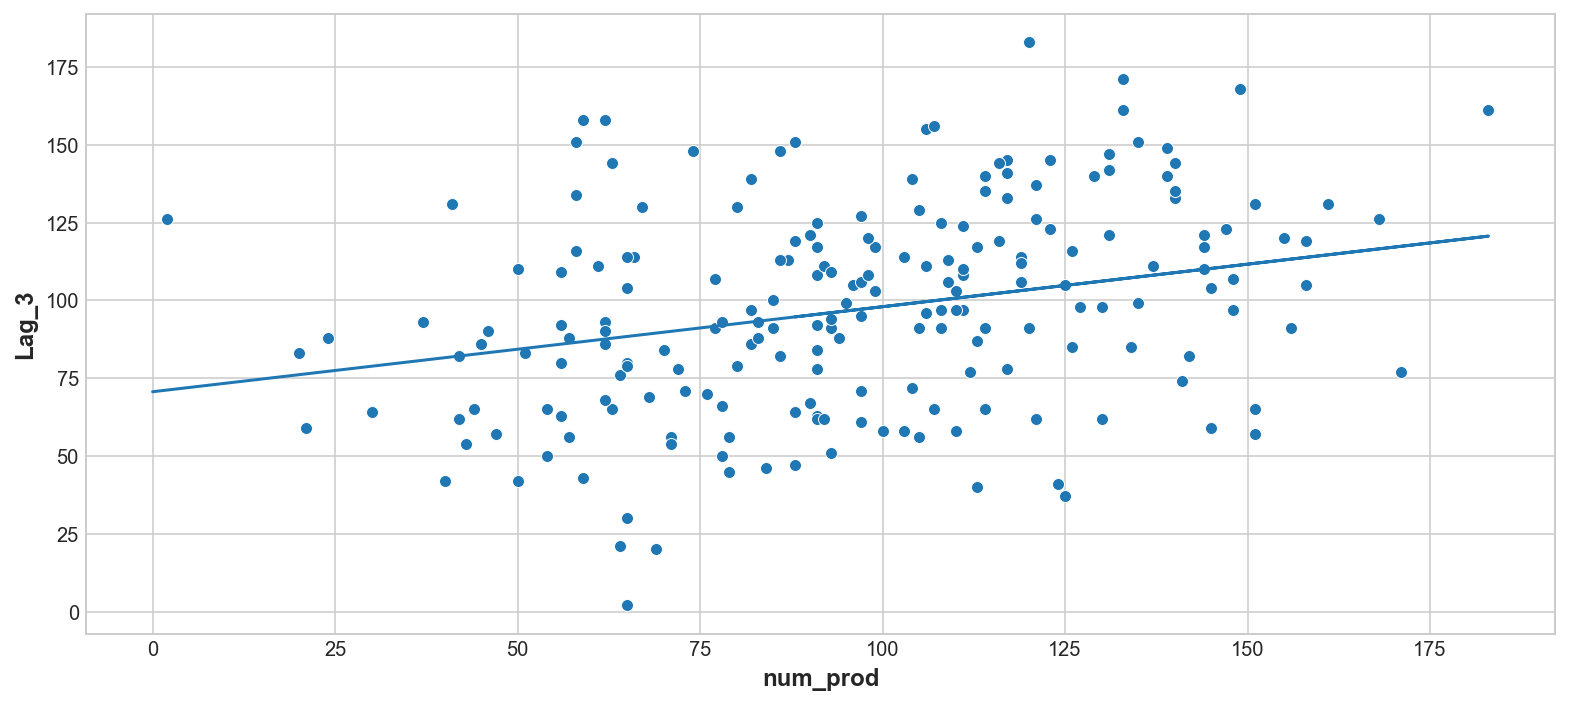

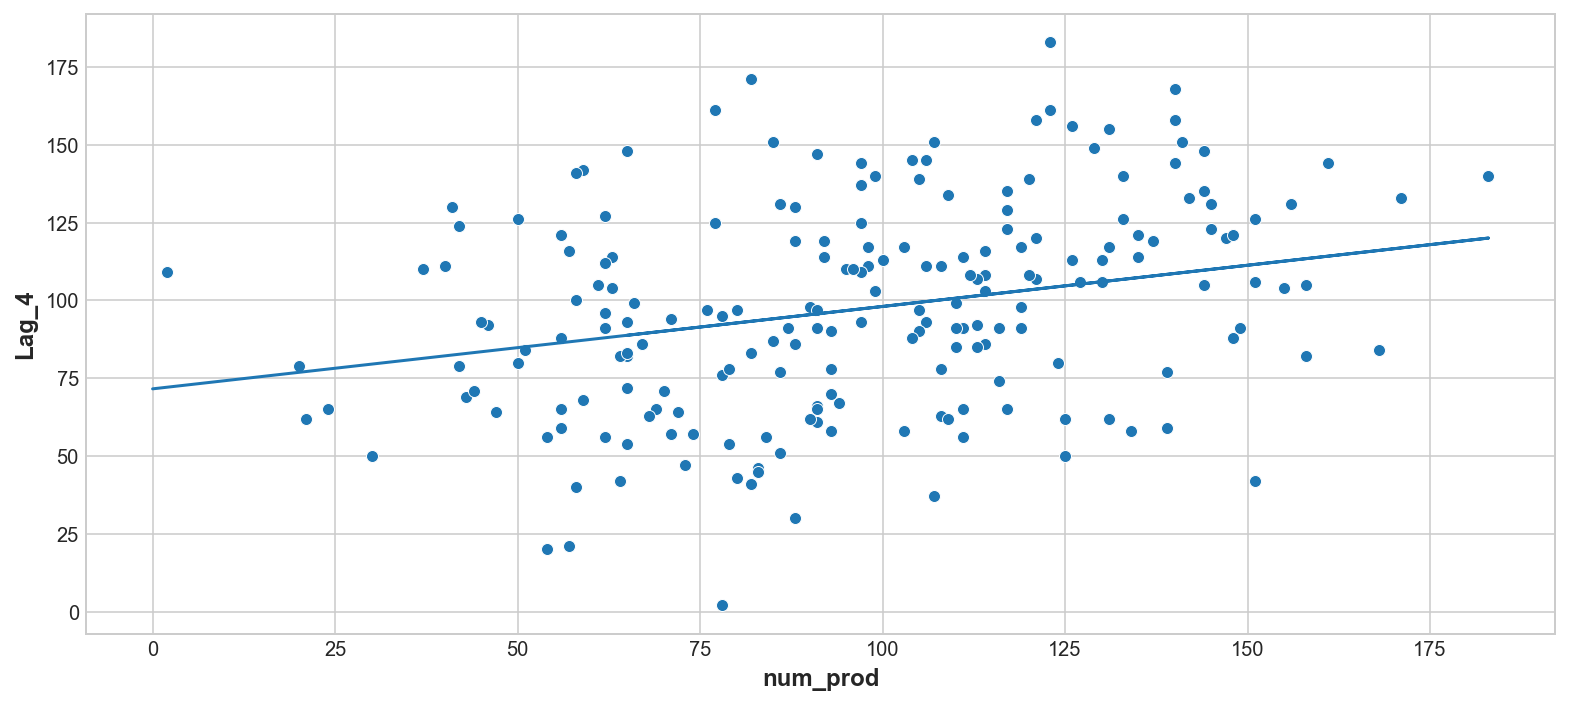

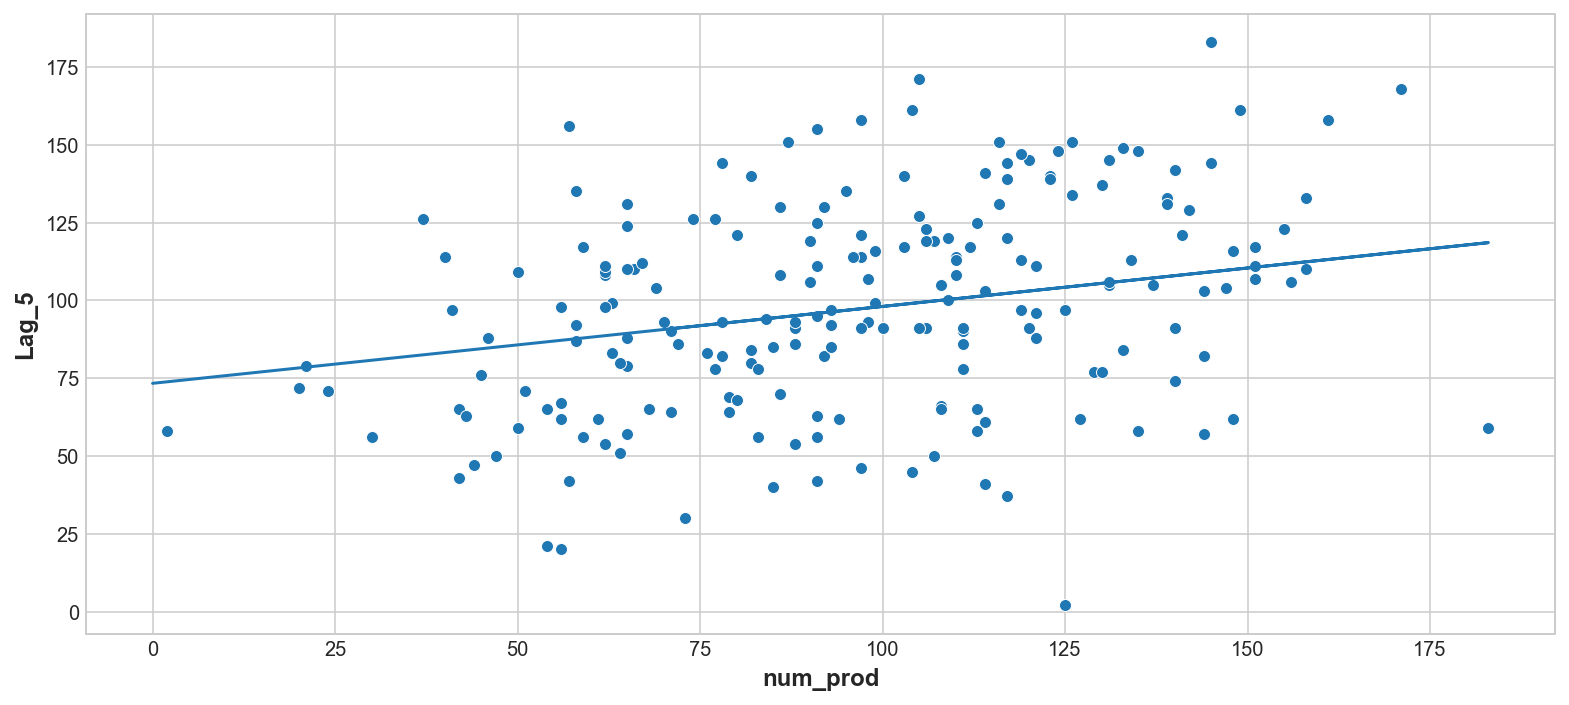

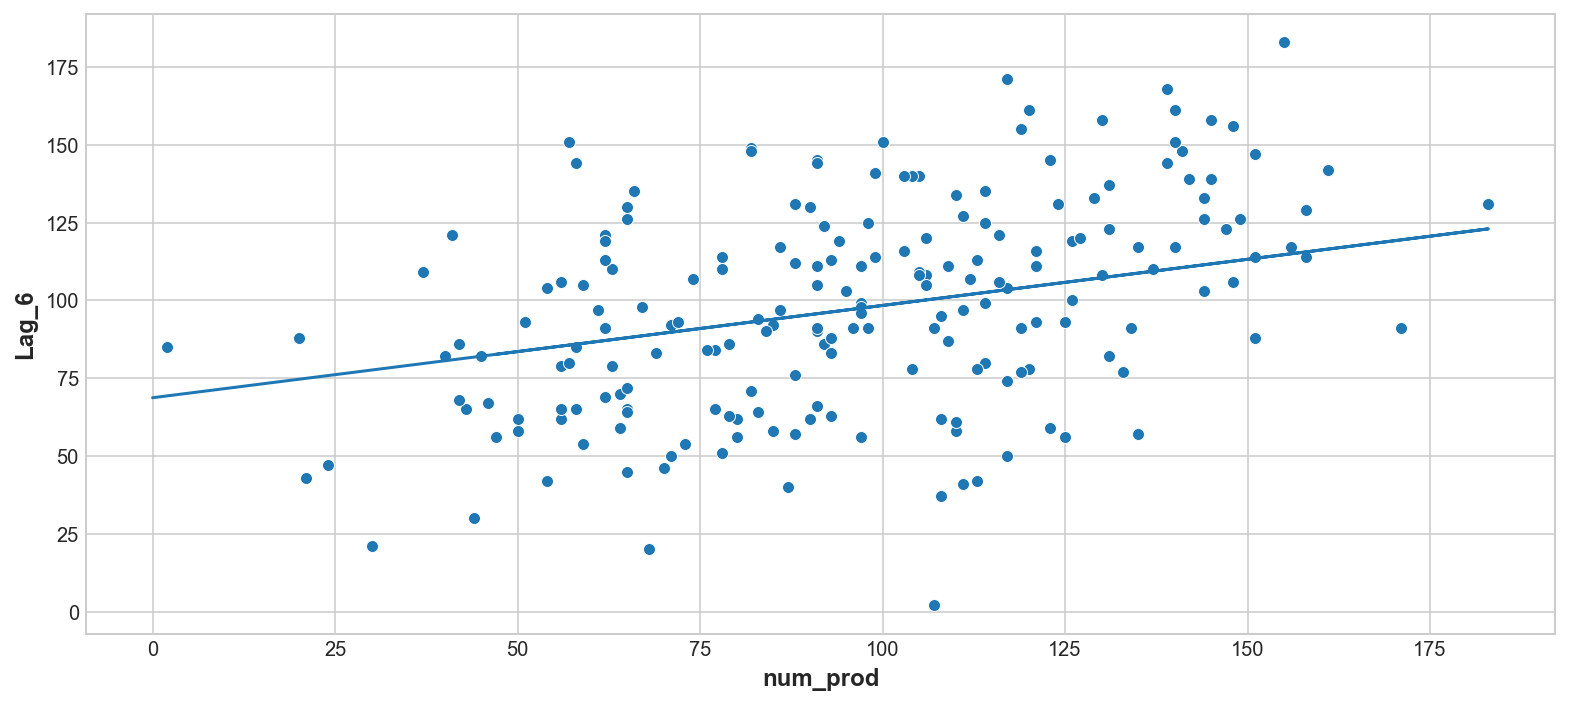

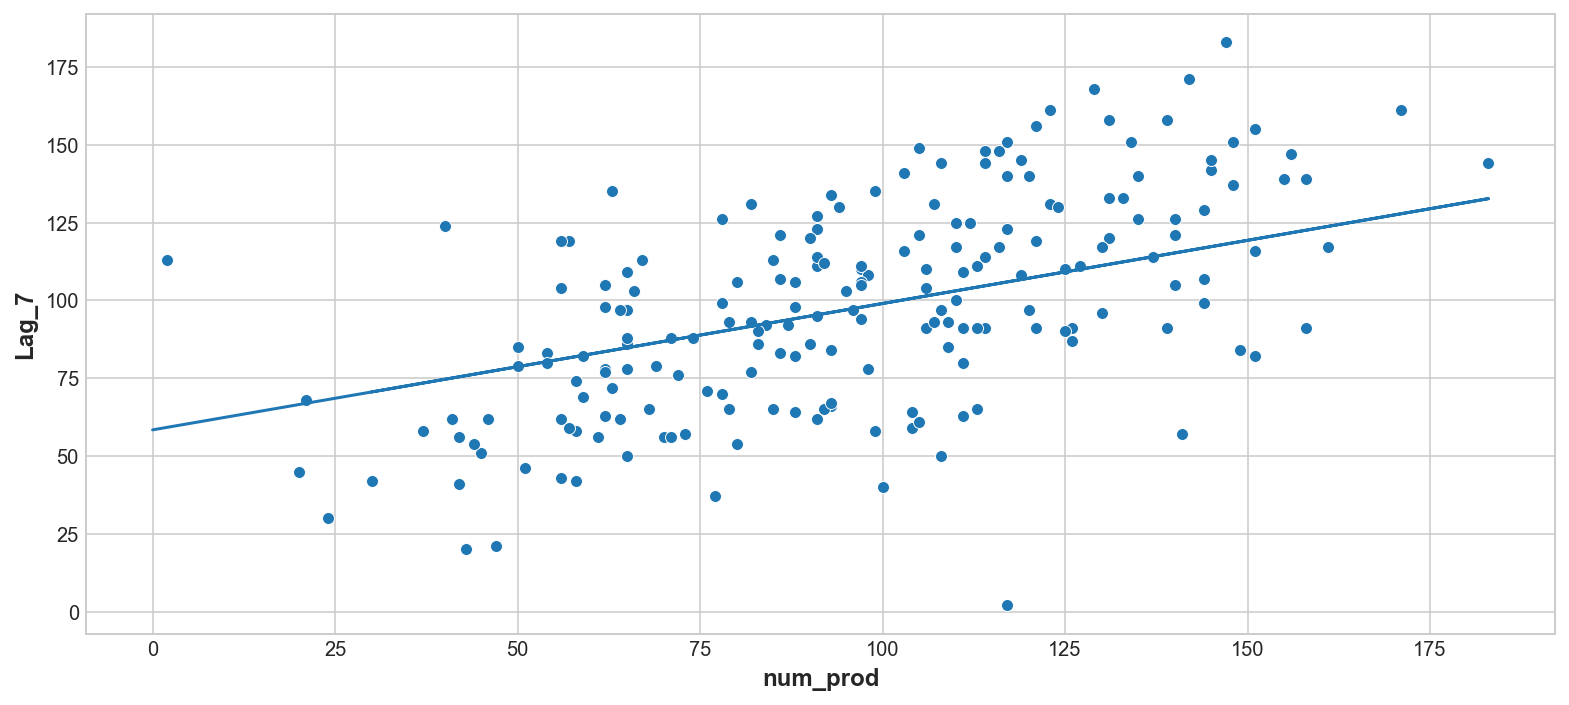

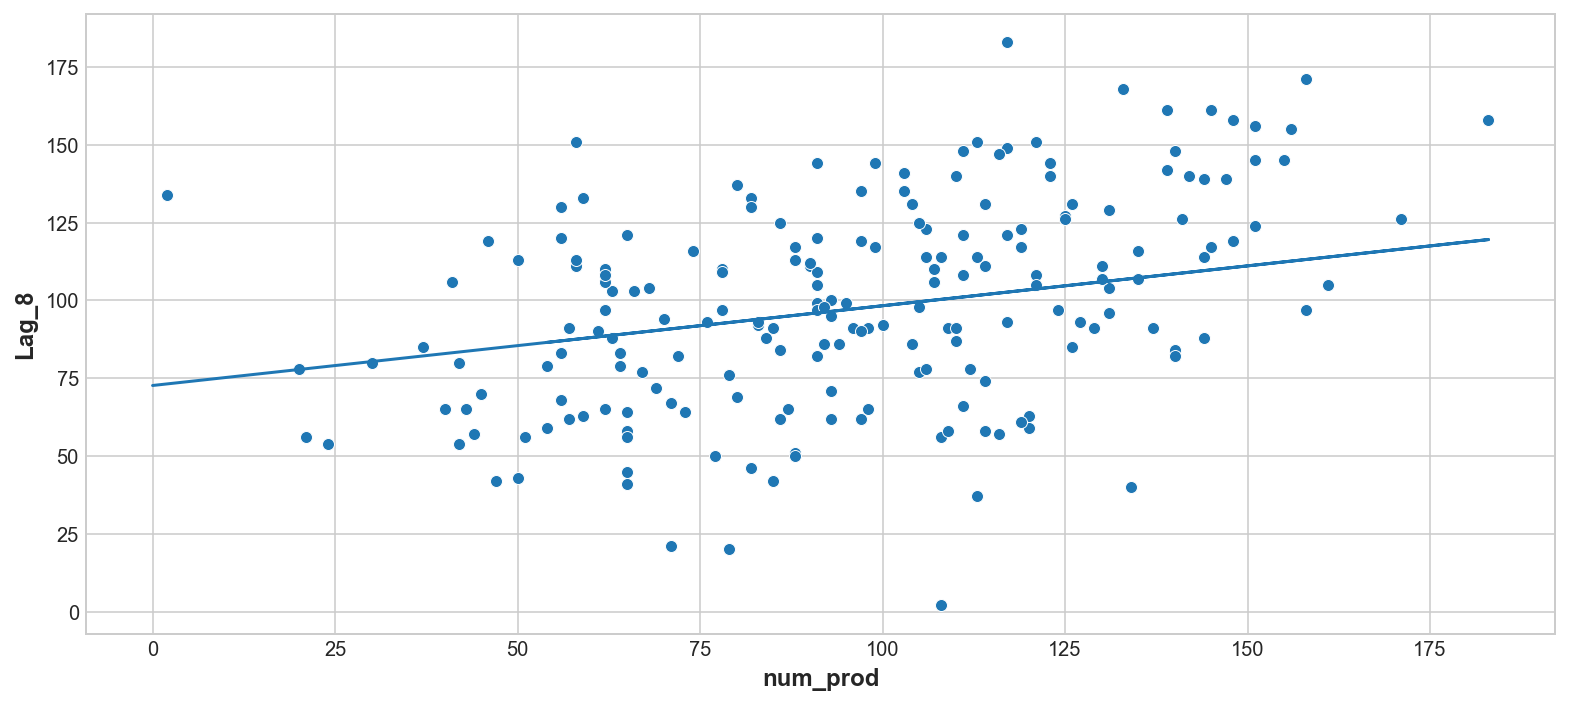

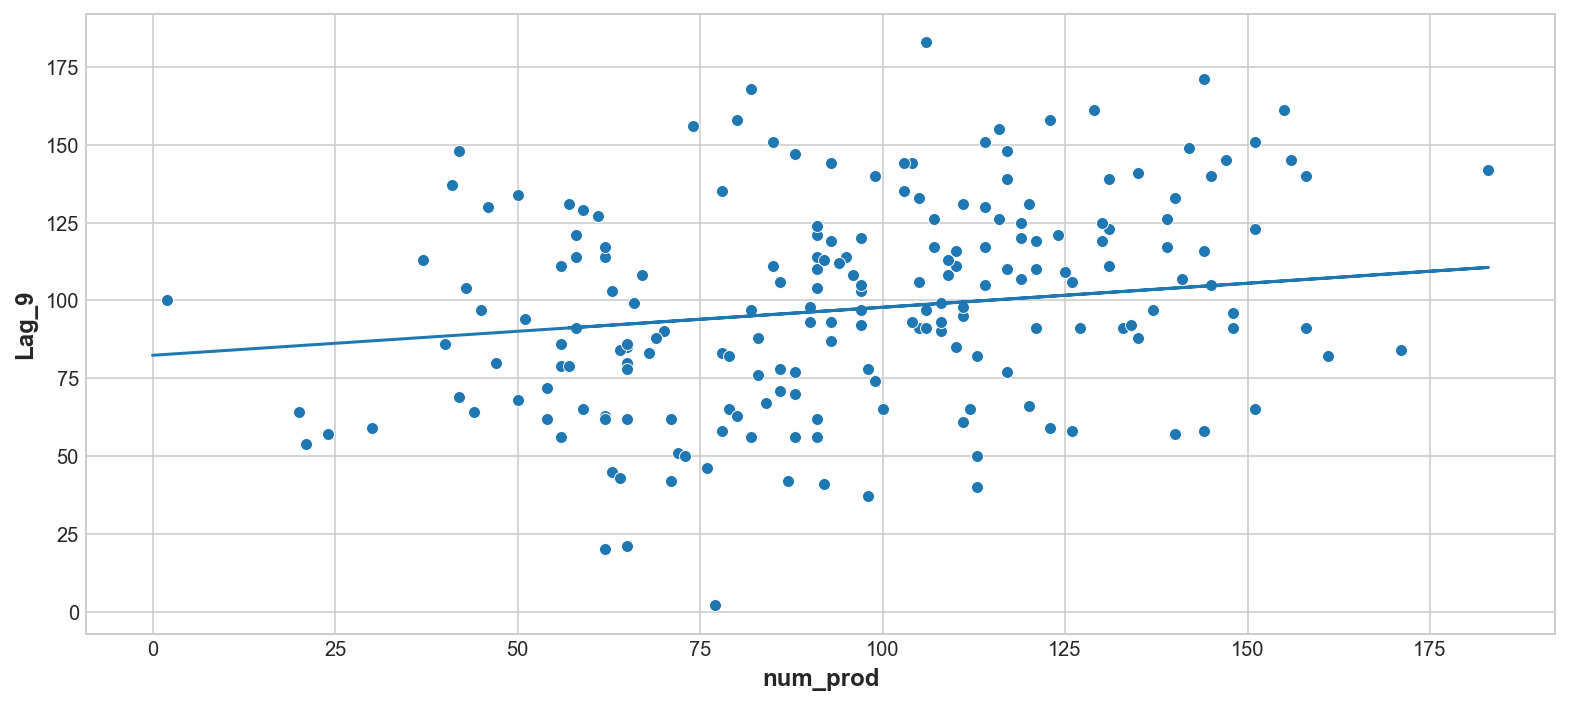

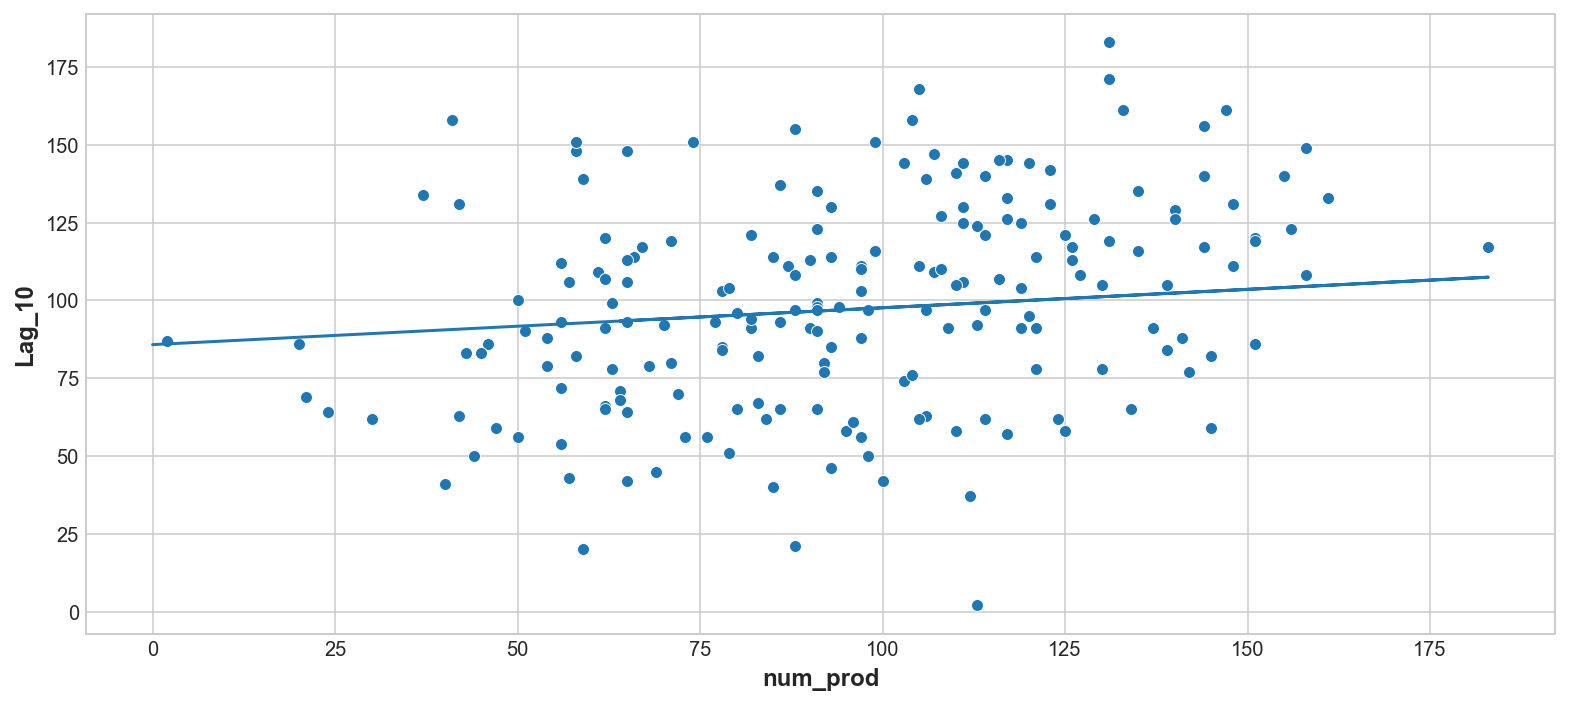

In [ ]:

for i in day.drop("Time_Step", axis = 1).drop("num_prod",axis = 1).columns:

    model = LinearRegression()
    model.fit(np.array(day[i].fillna(0)).reshape(-1,1),day["num_prod"])
    y_pred = model.predict(np.array(day[i].fillna(0)).reshape(-1,1))
    sns.scatterplot(x=day["num_prod"], y = day[i])
    plt.plot(np.array(day[i].fillna(0)).reshape(-1,1), y_pred)
    plt.show()

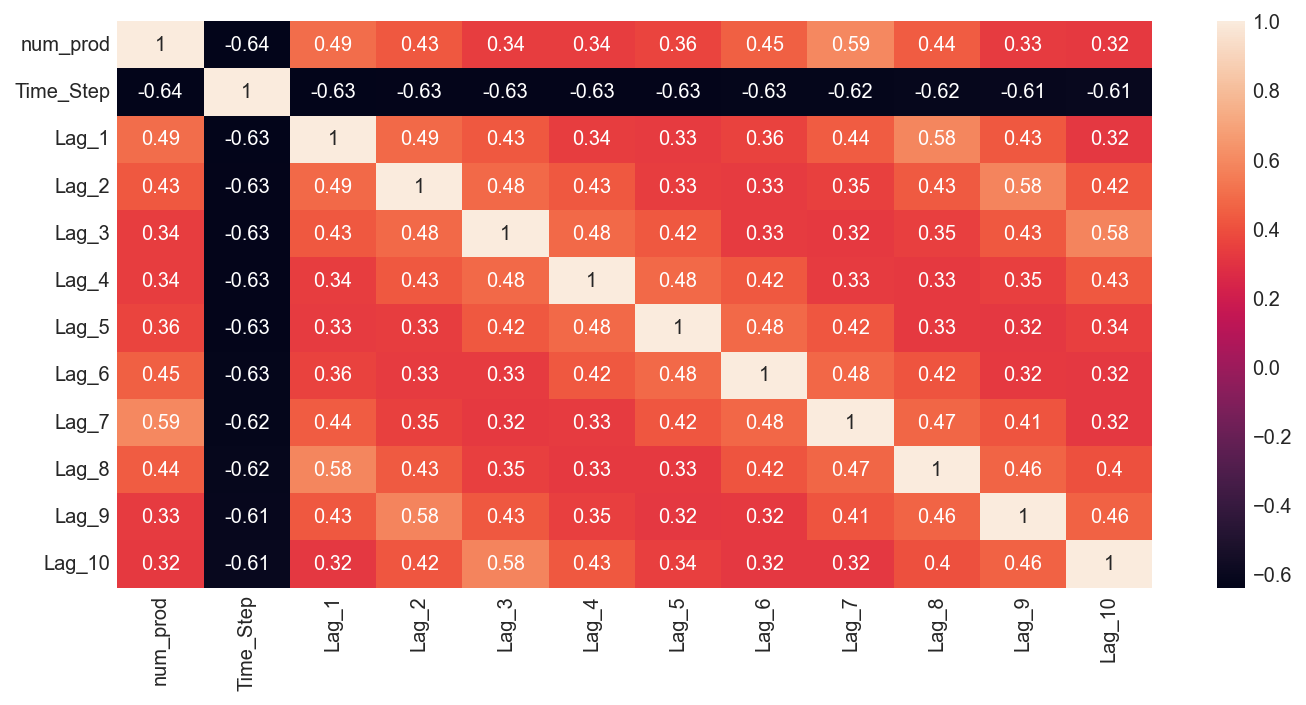

In [ ]:
plt.figure(figsize = (10,5))
sns.heatmap(k.corr(), annot = True)
plt.show()
## LAG_1, LAG_2

In [ ]:
k

,num_prod,Time_Step,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
days,,,,,,,,,,,,
2021-06-14,84,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06-15,126,1,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-08,44,206,73.0,88.0,65.0,71.0,47.0,30.0,54.0,57.0,64.0,50.0
2022-01-09,24,207,44.0,73.0,88.0,65.0,71.0,47.0,30.0,54.0,57.0,64.0


Nao devemos pegar todos os lags com alta autocorrelação, é provavelmente que a autocorrelação do lag_2 seja provinda do decaimento da lag_1. Se ela nao contem nada de novo, nao tem porque manter ela.

A autocorrelação parcial nos diz sobre a correlação de um lag levando em conta todos os lags anteriores. Seria o quanto aquele lag de fato contribui, sem considerar os outros. Plotar a autocorrelação parcial ajuda a escolher qual das features usar.

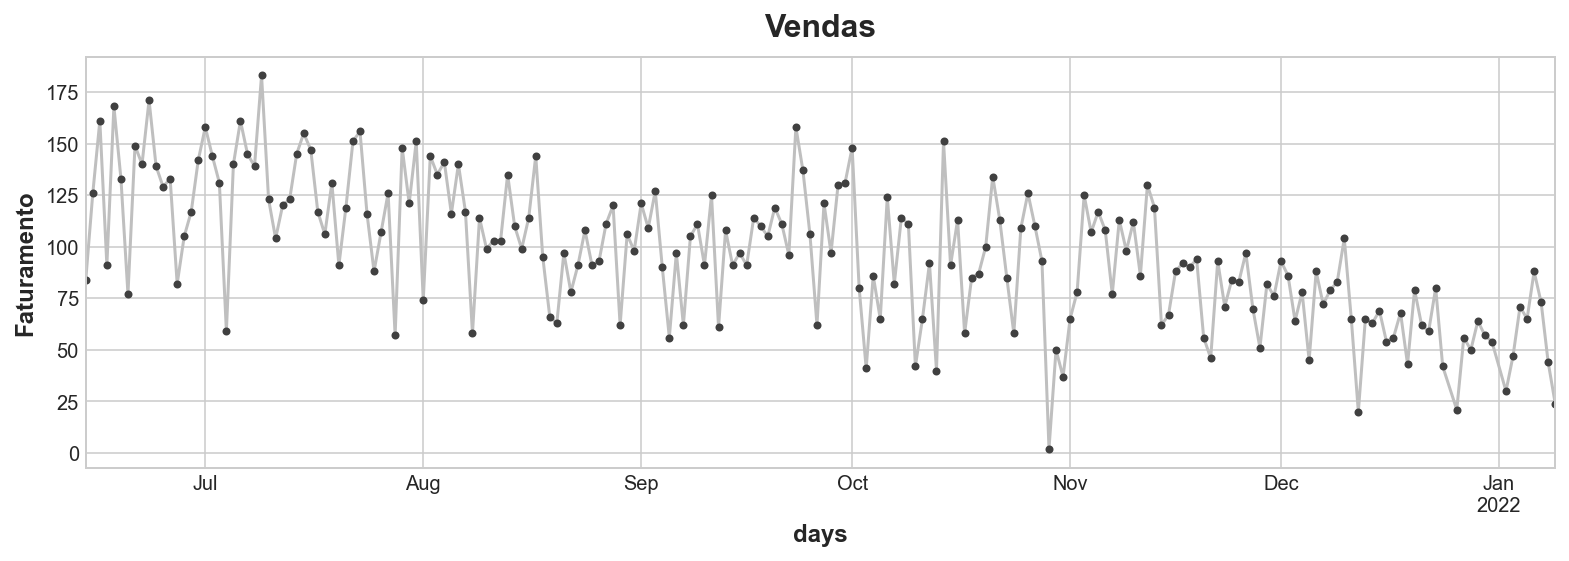

In [ ]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import periodogram
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_pacf

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig




ax = p.num_prod.plot(title='Vendas', **plot_params)
_ = ax.set(ylabel="Faturamento")

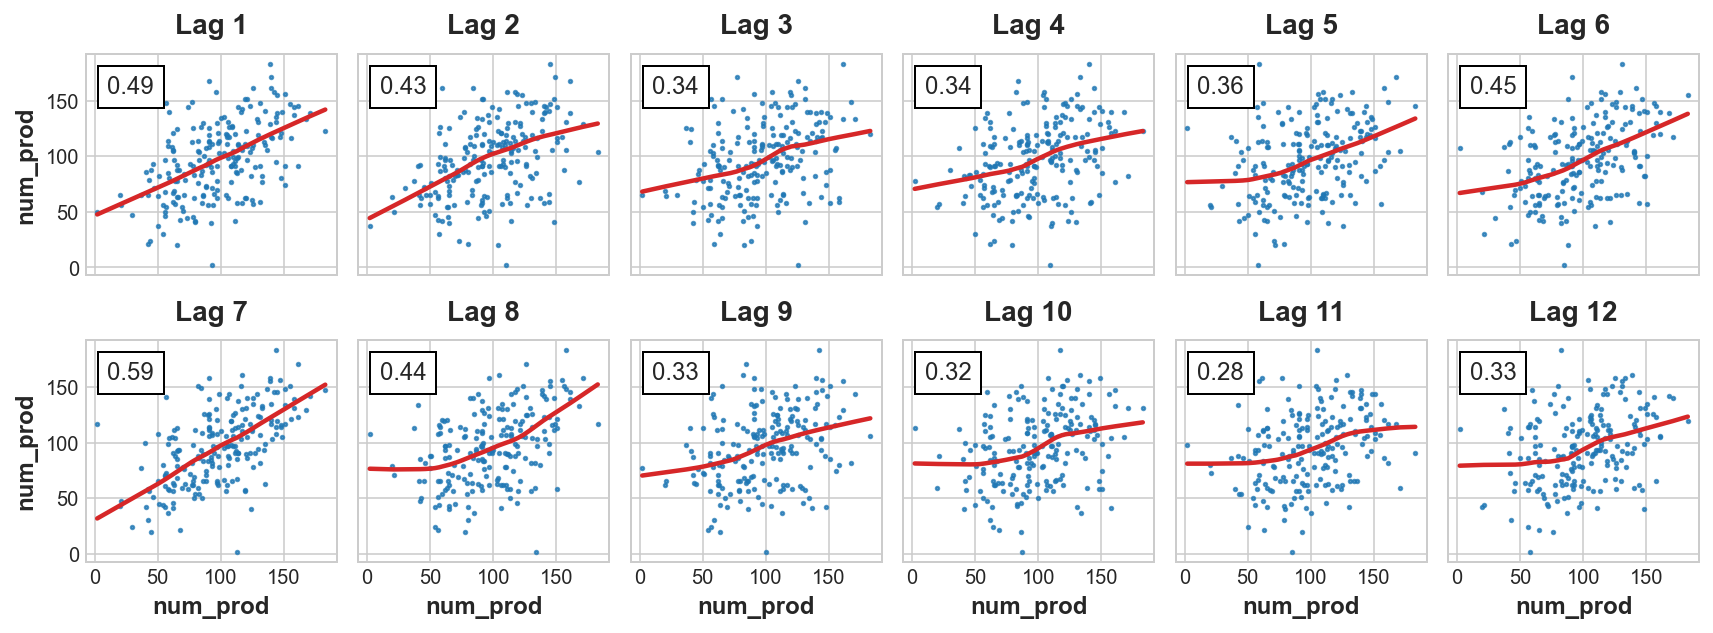

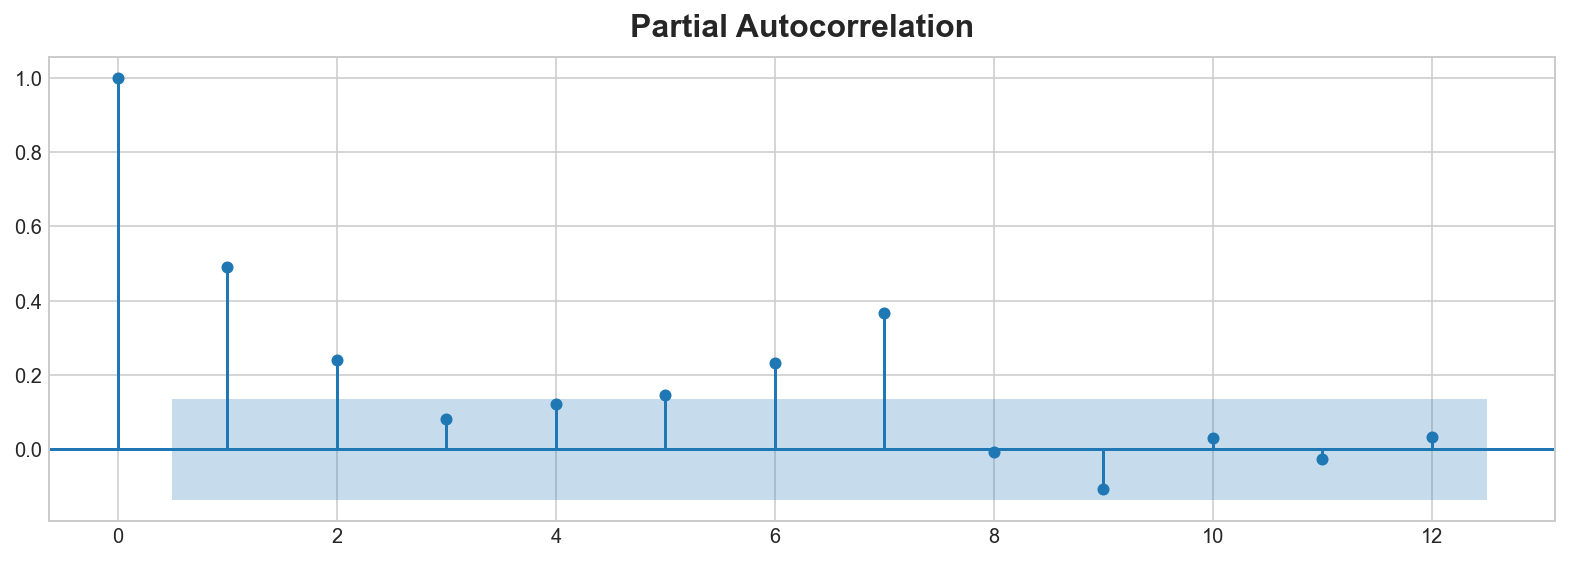

In [ ]:
_ = plot_lags(p.num_prod, lags=12, nrows=2)
_ = plot_pacf(p.num_prod, lags=12)
# Pouquissima correlação com os lags

In [ ]:
def make_lags(ts, lags):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)


Xk = make_lags(p.num_prod, lags=7)
Xk = Xk.fillna(0.0)
Xk = Xk.drop(['y_lag_2','y_lag_3','y_lag_4','y_lag_5','y_lag_6'], axis = 1)
Xk

,y_lag_1,y_lag_7
days,,
2021-06-14,0.0,0.0
2021-06-15,84.0,0.0
...,...,...
2022-01-08,73.0,54.0
2022-01-09,44.0,30.0


In [ ]:
k.iloc[:,0]

days
2021-06-14     84
2021-06-15    126
             ... 
2022-01-08     44
2022-01-09     24
Freq: D, Name: num_prod, Length: 208, dtype: int64

In [ ]:
40 +8*21

208

In [ ]:

train_cf = []
test_cf = []
y_train_cf = []
y_test_cf = []
s = []
count = 0
for i in range(40,208,21):
    train_cf.append(Xk.iloc[:i,:])
    test_cf.append(Xk.iloc[i:i+21,:])
    y_train_cf.append(k.iloc[:i,0])
    y_test_cf.append(k.iloc[i:i+21,0])
    print(train_cf[count].shape)
    print(test_cf[count].shape)
    count = count + 1
print(count-1)

(40, 2)
(21, 2)
(61, 2)
(21, 2)
(82, 2)
(21, 2)
(103, 2)
(21, 2)
(124, 2)
(21, 2)
(145, 2)
(21, 2)
(166, 2)
(21, 2)
(187, 2)
(21, 2)
7


Usando 40 dados
RMSE TREINO: 25.676159196667854
RMSE TESTE: 31.656837673384867
Sub das Somas das 3 semanas: -349.37120785115803


,num_prod,Previsao
2021-07-24,116.0,134.223128
2021-07-25,88.0,128.555092
...,...,...
2021-08-13,135.0,132.179180
TOTAL,2393.0,2742.371208


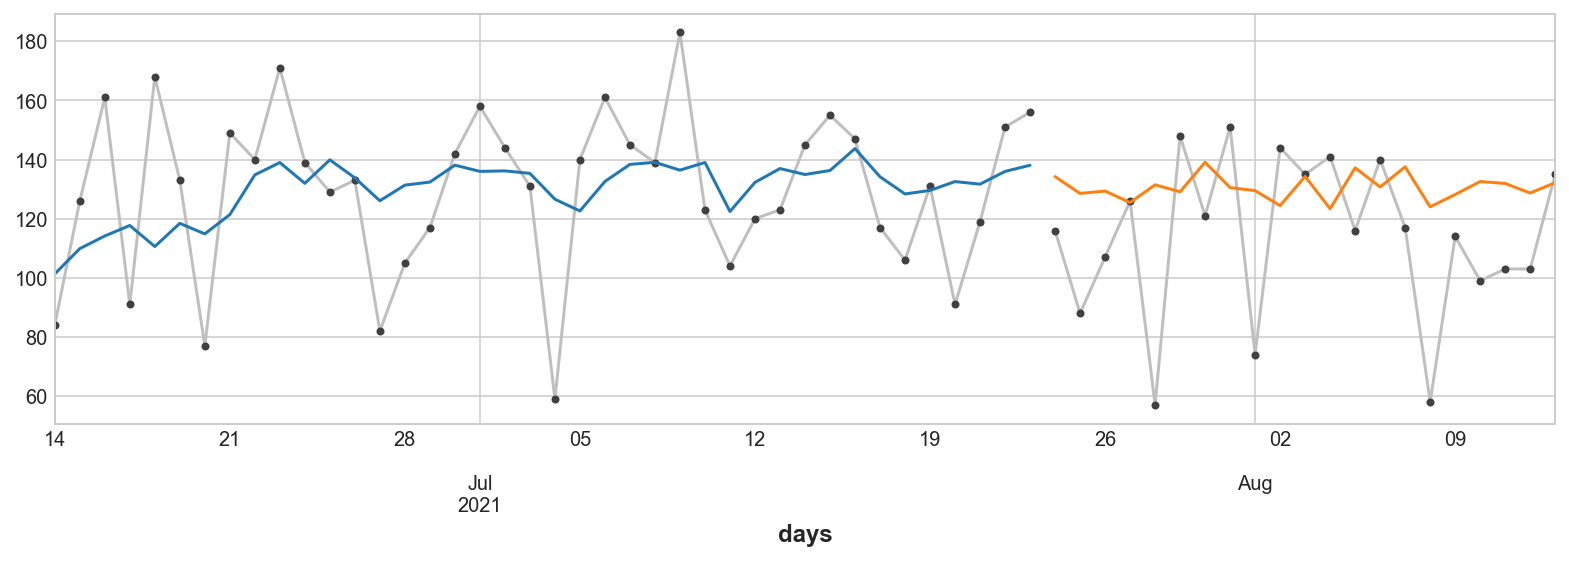

Usando 61 dados
RMSE TREINO: 27.2627891723873
RMSE TESTE: 29.259563913081546
Sub das Somas das 3 semanas: -439.59945837814894


,num_prod,Previsao
2021-08-14,110.0,125.924821
2021-08-15,99.0,115.990879
...,...,...
2021-09-03,127.0,123.268584
TOTAL,2103.0,2542.599458


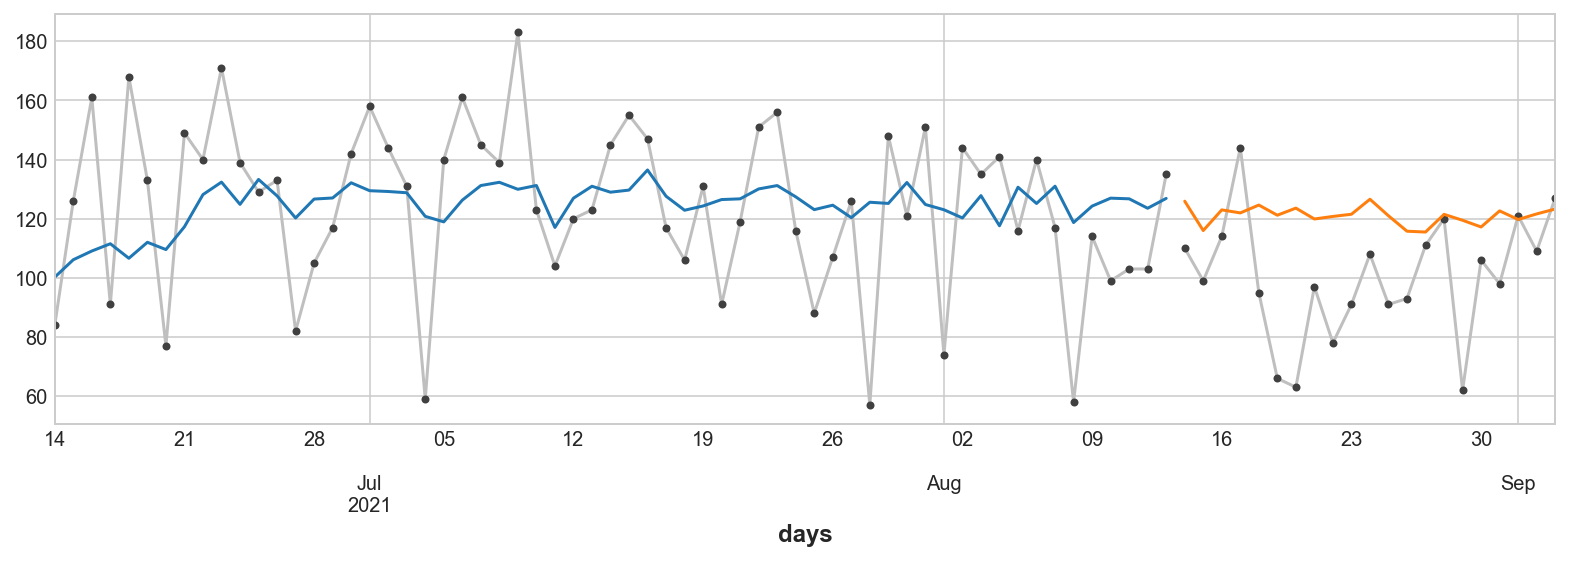

Usando 82 dados
RMSE TREINO: 27.056277515420884
RMSE TESTE: 25.751315970050744
Sub das Somas das 3 semanas: -253.38752248398487


,num_prod,Previsao
2021-09-04,90.0,121.592751
2021-09-05,56.0,106.627811
...,...,...
2021-09-24,137.0,126.174949
TOTAL,2135.0,2388.387522


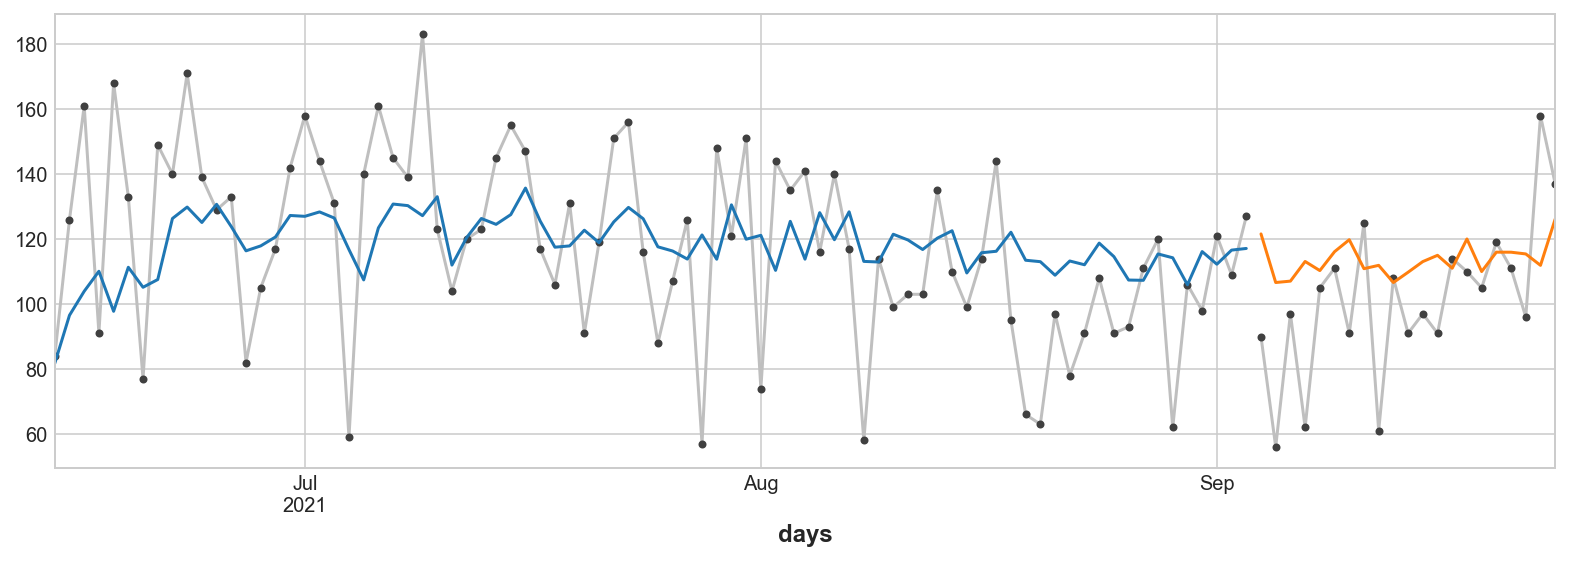

Usando 103 dados
RMSE TREINO: 26.6567278395429
RMSE TESTE: 36.424713435088584
Sub das Somas das 3 semanas: -360.08401591101483


,num_prod,Previsao
2021-09-25,106.0,119.908762
2021-09-26,62.0,113.084006
...,...,...
2021-10-15,91.0,123.287020
TOTAL,1979.0,2339.084016


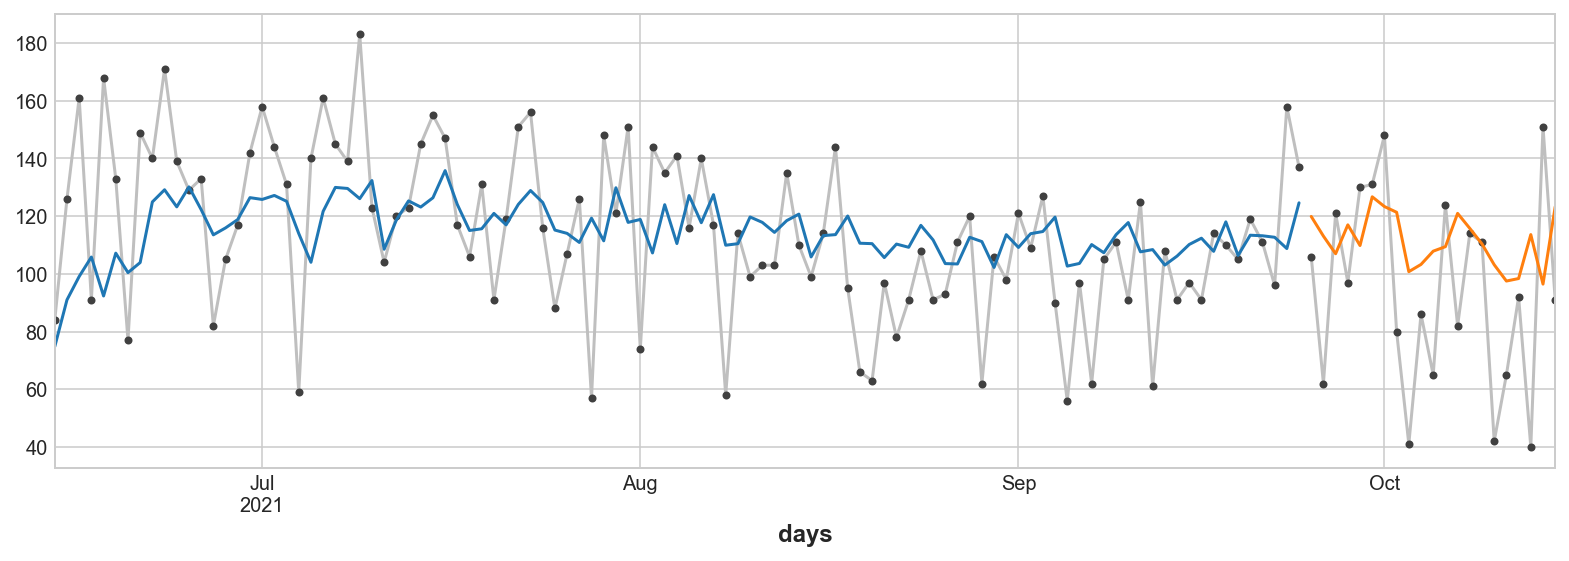

Usando 124 dados
RMSE TREINO: 28.376815603034302
RMSE TESTE: 34.19845867235264
Sub das Somas das 3 semanas: -321.18161790089243


,num_prod,Previsao
2021-10-16,113.0,108.645801
2021-10-17,58.0,98.899790
...,...,...
2021-11-05,117.0,89.832930
TOTAL,1852.0,2173.181618


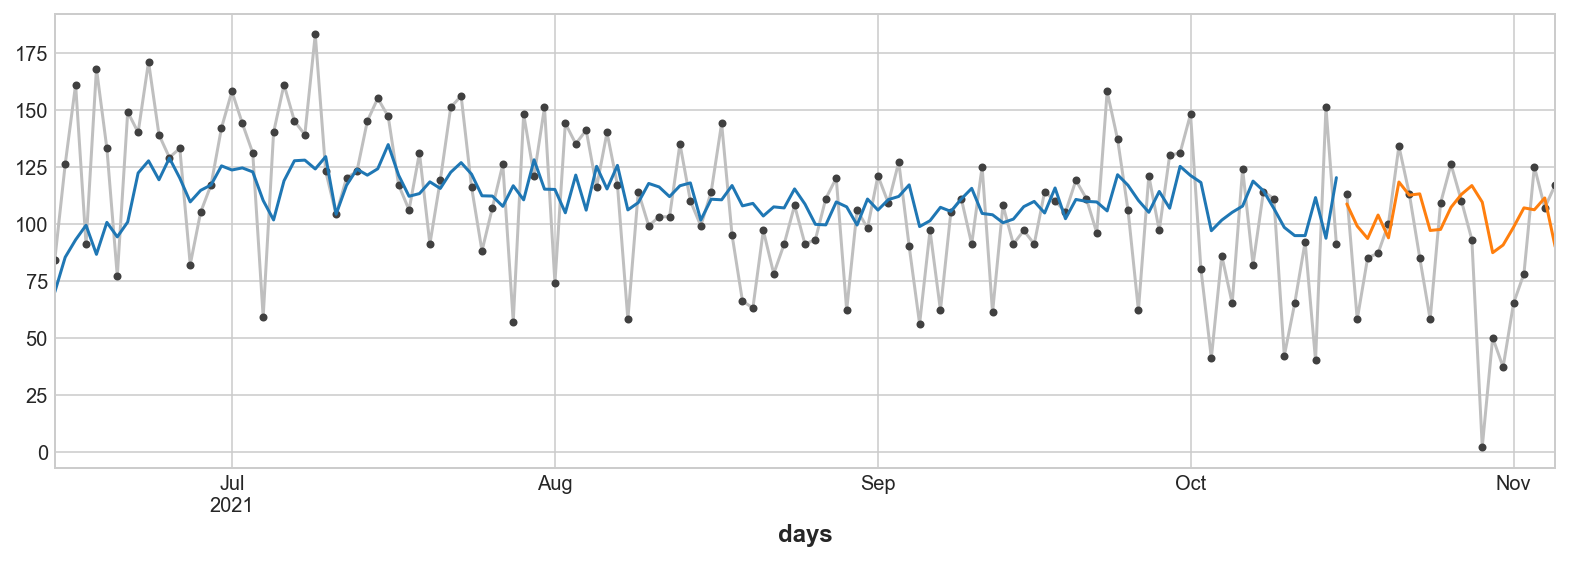

Usando 145 dados
RMSE TREINO: 29.103722130957276
RMSE TESTE: 23.079269459093467
Sub das Somas das 3 semanas: -254.16610475800917


,num_prod,Previsao
2021-11-06,108.0,99.729113
2021-11-07,77.0,94.819712
...,...,...
2021-11-26,97.0,99.770182
TOTAL,1866.0,2120.166105


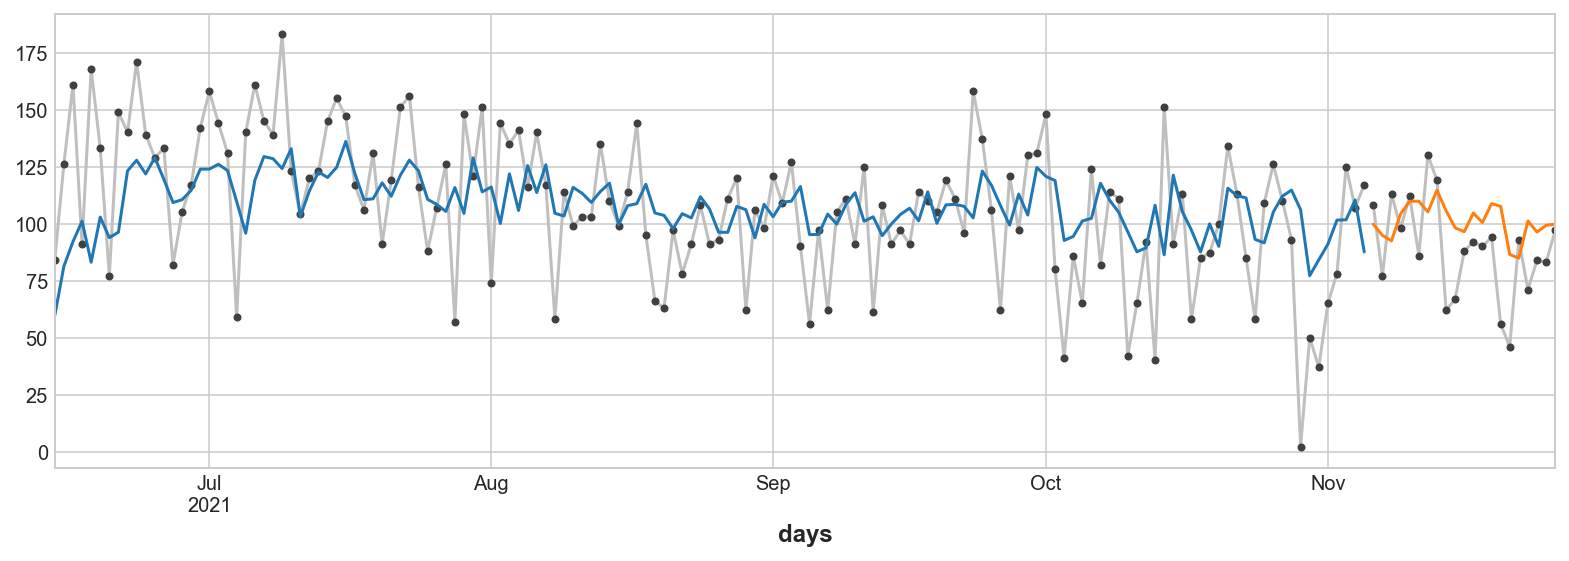

Usando 166 dados
RMSE TREINO: 28.361419473131335
RMSE TESTE: 27.14647123001129
Sub das Somas das 3 semanas: -446.37632298016615


,num_prod,Previsao
2021-11-27,70.0,93.803107
2021-11-28,51.0,84.249837
...,...,...
2021-12-17,56.0,91.745444
TOTAL,1463.0,1909.376323


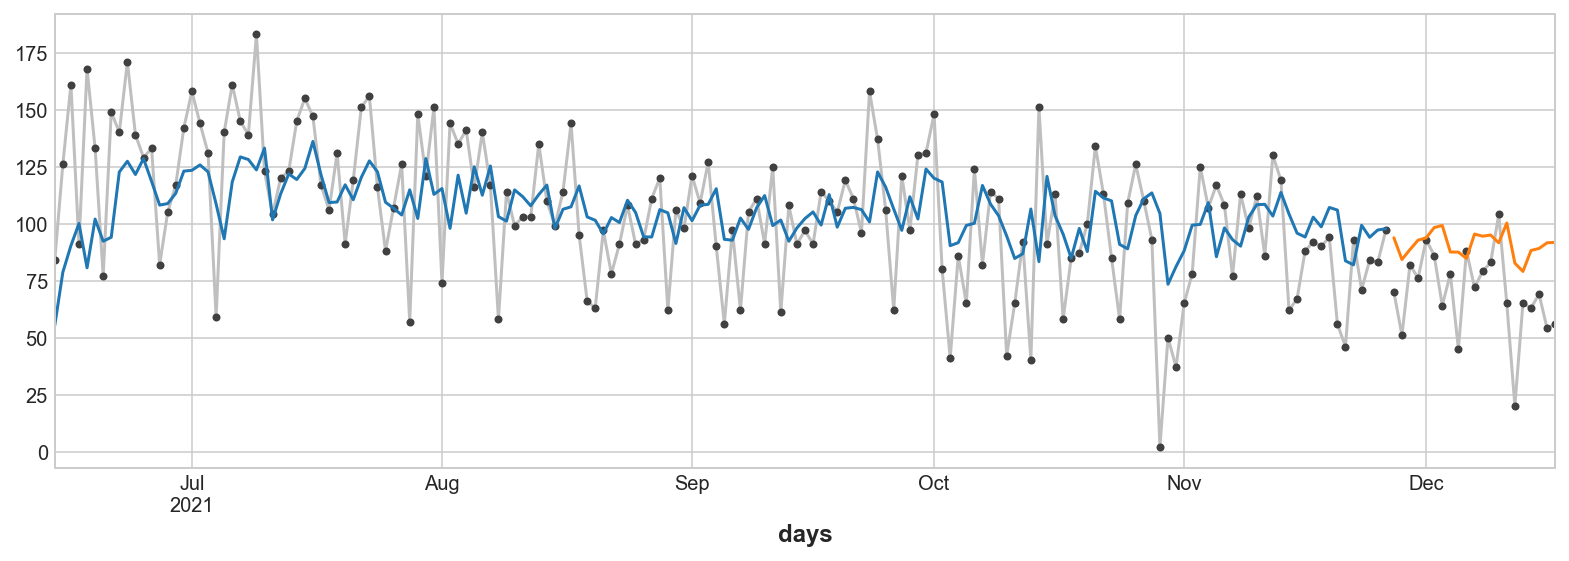

Usando 187 dados
RMSE TREINO: 28.021394496736296
RMSE TESTE: 26.288455802066743
Sub das Somas das 3 semanas: -425.79148563220383


,num_prod,Previsao
2021-12-18,68.0,78.225825
2021-12-19,43.0,71.182894
...,...,...
2022-01-09,24.0,65.724273
TOTAL,1177.0,1602.791486


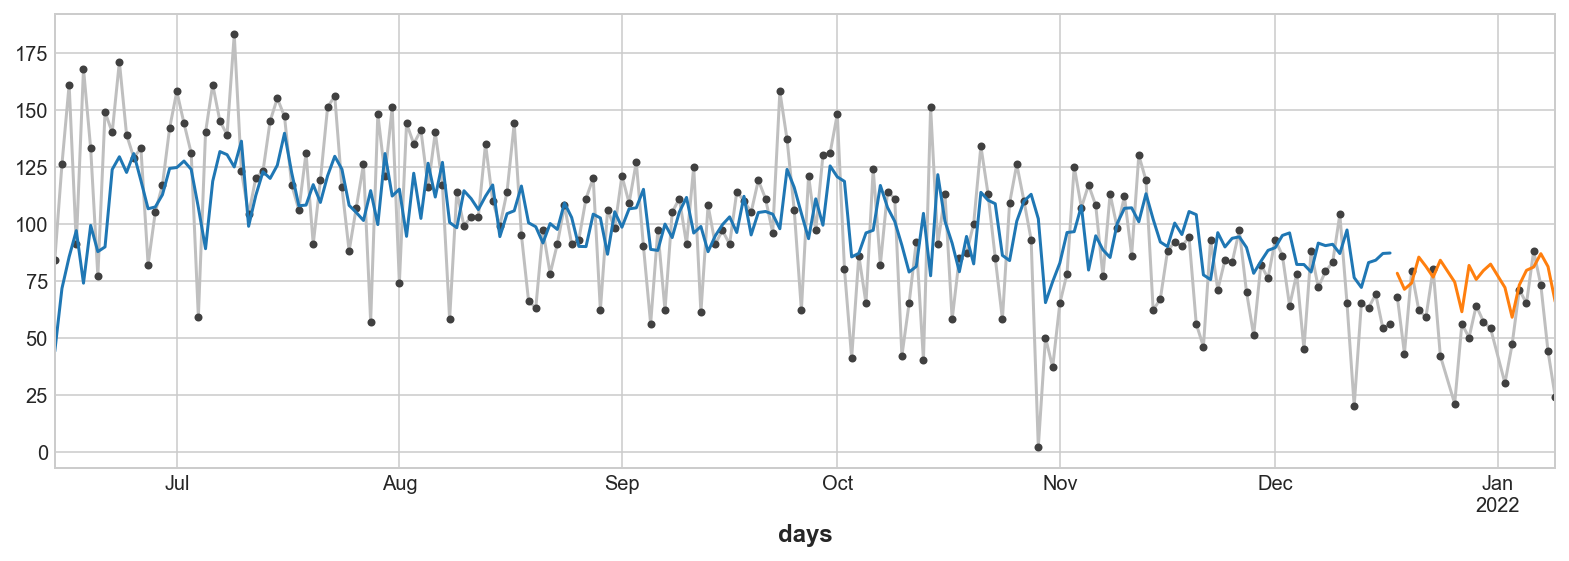

In [ ]:
from sklearn.metrics import make_scorer
def score_fun(y, y_pred):
    return y.sum() - y_pred.sum()

def result(X_train = train_cf[-1], y_train = y_train_cf[-1],
           X_test = test_cf[-1], y_test = y_test_cf[-1], modelo = LinearRegression()):
    model.fit(X_train, y_train)
    y_pred_train = pd.Series(model.predict(X_train), index = y_train.index)
    y_pred_test = pd.Series(model.predict(X_test), index = y_test.index, name = 'Previsao')
    rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
    rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)
    result = pd.concat([y_test, y_pred_test], axis = 1)
    total = []
    total.append(result.iloc[:,0].sum())
    total.append(result.iloc[:,1].sum())
    total = pd.DataFrame(total).rename(index = {0:'num_prod', 1:'Previsao'},columns={0:'TOTAL'})
    dados = pd.concat([result,total.T], axis = 0)
    return y_pred_train, y_pred_test, dados, score_fun(y_test, y_pred_test), rmse_train, rmse_test

# Create target series and data splits
dicti = dict()
for pos, train in enumerate(train_cf):
    X_train = train
    X_test = test_cf[pos]
    y_train = y_train_cf[pos]
    y_test = y_test_cf[pos]

    print('='*30)
    print(f'Usando {len(X_train)} dados')
    # Fit and predict
    model = LinearRegression()  # `fit_intercept=True` since we didn't use DeterministicProcess
    # When we use, we put as false because the const make this

    y_pred_train, y_pred_test, dad, score, rmse_train, rmse_test = result(X_train = train_cf[pos], y_train = y_train_cf[pos],
           X_test = test_cf[pos], y_test = y_test_cf[pos], modelo = model)
    dicti[f'{pos}'] = dict({'dados':dad, 'Score':score,'RMSE_TRAIN': rmse_train,'RMSE_TEST': rmse_test})
    print(f'RMSE TREINO: {rmse_train}')
    print(f'RMSE TESTE: {rmse_test}')
    print(f'Sub das Somas das 3 semanas: {score}')
    display(dad)
    ax = y_train.plot(**plot_params)
    ax = y_test.plot(**plot_params)
    ax = y_pred_train.plot(ax=ax)
    ax = y_pred_test.plot(ax=ax)
    #_ = y_fore.plot(ax=ax, color='C3')
    plt.show()

Train RMSE Days: 40.05

Test RMSE Days: 38.39



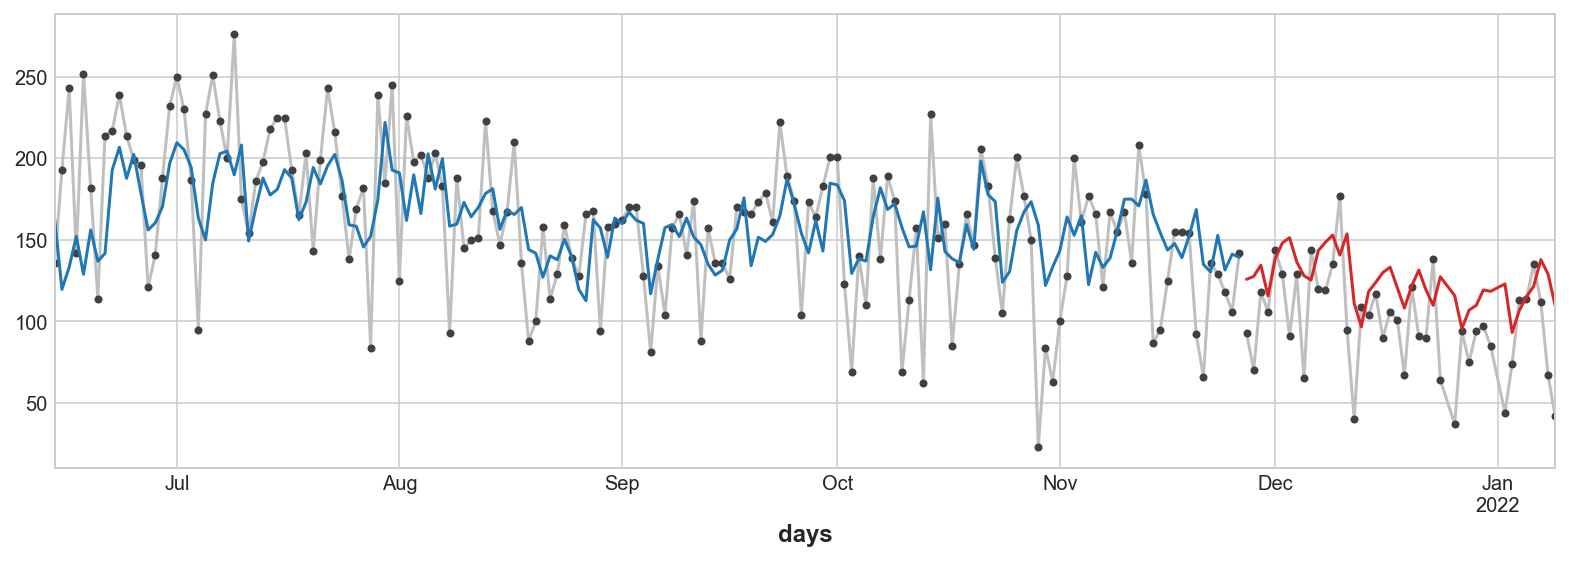

In [ ]:
c = pd.DataFrame(dados.groupby("days")["lines/price_unit"].count())
d = pd.DataFrame(dados.groupby("days")["Temperatura"].mean())
cd = pd.concat([c,d], axis = 1)

cd["day"] = cd.index.dayofweek
cd["day_month"] = cd.index.day
cd["week"] = cd.index.week
#
cd["dayofyear"] = cd.index.dayofyear
cd["year"] = cd.index.year
cd["month"] = cd.index.month
cd = cd.rename(columns = {"lines/price_unit":"num_prod"})

dad = cd[["num_prod","Temperatura","week"]]
y = cd["num_prod"]

cd

search_terms = ["Temperatura"]

# Create three lags for each search term
X0 = make_lags(dad[search_terms], lags=1)
#X0 = ab["Temperatura"]
# Create four lags for the target, as before
X1 = make_lags(dad['num_prod'], lags=1)

X1 = make_lags(p.num_prod, lags=7)
#X1 = X1.fillna(0.0)
X1 = X1.drop(['y_lag_2','y_lag_3','y_lag_4','y_lag_5','y_lag_6'], axis = 1)
#X1

X2 = cd["day_month"]
# Combine to create the training data
#X = pd.concat([X0, X1, X2], axis=1).fillna(0.0)
X = pd.concat([X0, X1], axis=1).fillna(0.0)
X
#X = X1.fillna(0.0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# Fit and predict
model = LinearRegression()  # `fit_intercept=True` since we didn't use DeterministicProcess
# When we use, we put as false because the const make this
model.fit(X_train, y_train)
y_pred = pd.Series(model.predict(X_train), index=y_train.index)
y_fore = pd.Series(model.predict(X_test), index=y_test.index)

ax = y_train.plot(**plot_params)
ax = y_test.plot(**plot_params)
ax = y_pred.plot(ax=ax)
_ = y_fore.plot(ax=ax, color='C3')


rmse = mean_squared_error(y_train, y_pred, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")
rmse = mean_squared_error(y_test, y_fore, squared=False)

print(f"Test RMSE Days: {rmse:.2f}\n")

In [ ]:
y_fore

days
2021-11-27    125.793778
2021-11-28    127.576893
                 ...    
2022-01-08    129.167840
2022-01-09    109.495885
Freq: D, Length: 42, dtype: float64

#### MODELOS HIBRIDOS EM TIME SERIES

Linear Regression extende a extrapolação de trends mas nao consegue aprender interações. XGBoost extende o aprendizado de interações mas não extrapola as trends. Vamos aprender a criar modelos hibridos que combinam as complementaridades dos algoritmos e deixa eles fortes nas fraquezas dos outros.

Tree models do not capture the trend because they do not work well on out of sample data. The model has learnt the trend in the actuals w.r.t to date, through its splits, [which is each day:this value] . For everyday in future, it stays the same, cause the future date does not fall in any of its seen buckets, it just splits out a mean value for that date, in combination with other attributes

**Components and Residuals**

Nós estudamos até agora três modos de dependecia: trend, sazonalidade e ciclos. Muitas vezes as time series sao descritas como esses 3 componentes mais uma parte randomica de erro.

series = trend + seasonz + cycles + error.

Cada um desses termos podemos chamar de componentes da time series.

O residúo do modelo é a diferença entre a target na qual o modelo foi treinado e as predições que o modelo faz. A diferença entre a curva atual e a curva predita.

Predizer os residuos sobre uma feature voce é capaz de ver que parte da target o modelo falha em aprender por ela.

Podemos imaginar uma forma de aprender os componentes da time series como um processo iterativo: Primeiro prevemos a trend e subtraimos ela da serie normal, depois aprendemos a sazonalidade e subtraimos da normal, depois aprendemos os ciclos e subtraimos da normal e finalmente sobrará a parte randomica e não preditiva.

![image.png](attachment:e6b172cb-0d5f-4c99-8c0a-08e845b3d5f3.png)

Ao final somamos todos os componentes que aprendemos e completamos o modelo. Isso é o que a linear regression faz se voce treinar ela com o modelo completo de componentes.

**Previsões Hibridas com Resíduo**

É possivel usar um algoritmo para um componente e outro para outro componente. Desta forma podemos escolher o melhor algoritmo para cada componente.

Para fazer isso, usamos um algoritmo para fitar a serie original e depoisum segundo para fitar os residuos da serie.

#1. Train and predict with first model
model_1.fit(X_train_1, y_train)
y_pred_1 = model_1.predict(X_train)

#2. Train and predict with second model on residuals
model_2.fit(X_train_2, y_train - y_pred_1)
y_pred_2 = model_2.predict(X_train_2)

#3. Add to get overall predictions
y_pred = y_pred_1 + y_pred_2

Geralmente usa-se features diferentes dependendo do que voce quer que o modelo aprenda, se você quiser que ele aprenda trend no primeiro modelo, não precisamos da feature de trend para o segundo modelo, por exemplo.

Apesar de ser possivel usar mais de 2 modelos, na pratica isso nao ajuda muito. geralmente usam-se dois modelos, em geral um simples e linear seguido por um bem complexo e nao linear. O modelo linear age como um ajudante para o modelo pesado que o segue.

**Desenhando os hibridos**

Existem muitas formas de combinar modelos de machine learning, uma combinação boa necessita entender a fundo como os algoritmos funcionam.

Os mais comuns sao dois tipos de algoritmos de regressao: transformando as features ou transformando a target. Os algoritmos que transformam as features aprendem algumas funções matematicas que fazem das features um input que sao combinados e produzem o output que tenta igualar a target no dado de treino. Regressao Linear e redes neurais agem assim.

Algoritmos de transformação da target usa as as features para agrupar as targets no conjunto de treino e prever calculando as medias de valores no grupo. Um conjunto de features apenas indica em qual grupo fazer a media. Arvores de decisao e KNN usam esse tipo. (IMAGINE NA DECISION TREE, OLHAMOS PARA TARGET E FAZEMOS DIVISAO E NO KNN CHEGA UM DADO< VEMOS O VIZINHO MAIS PROXIMO E AGRUPAMOS AO GRUPO E PEGAMOS VALOR MEDIO.)

A parte importante é que: transformação pela feature geralmente podemos extrapolar a target além do conjunto de treino se possuirem as features como inputs. Já os transformadores pelas targets sempre estão vinculados ao intervalo do conjunto de treino. Se o tempo continuar aumentando, a regressão linear continuará a desenhar a linha de tendencia. Dado o mesmo tempo (crescendo), uma arvore de decisao irá prever a tendencia indicada pela última etapa dos dados de treinamento para o futuro para sempre. As árvores de decisao nao podem extrapolar tendencias. Algoritmos baseados em decision tree sofrem do mesmo problema. RF e xgboost.

Esta diferença motiva o modelo hibrido. Aqui usaremos a linear regression para extrapolar a trend, transformaremos a target removendo a trend e aplicaremos o xgboost para aprender do que sobra. Para hibridizar com redes neurais, você pode em vez deste formato, incluir as predições de um outro modelo como uma feature que ela poderá incluir como parte das suas predições.

Este primeiro metodo de ajuste aos residuos é o que faz o gradiente boosting, entao chamaremos isso de **bosted** hibridos. O que usa as predições de outros modelos é o stacking, por isso chamamos de **stacked** hibridos.

ALEM DE CRIAR UMA REGRESSAO LINEAR COM XGBOOST VEREMOS COMO SETAR A TIME SERIES COM XGBOOST

In [ ]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from xgboost import XGBRegressor


simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc(
    "figure",
    autolayout=True,
    figsize=(11, 4),
    titlesize=18,
    titleweight='bold',
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)

cd = cd[["num_prod","Temperatura"]]
cd = pd.concat({"Sales":cd}, names = [None, "Industries"], axis = 1)
display(cd.head())

Sales            
Industries num_prod Temperatura
days                           
2021-06-14      136   22.286713
2021-06-15      193   22.783251
2021-06-16      243   20.828794
2021-06-17      142   20.238095
2021-06-18      252   20.412698

**Primeiro**
Usaremos a linear regression para aprender sobre a trend da time series.

COM A LINEAR REGRESSION É POSSIVEL PREVER DUAS COLUNAS AO MESMO TEMPO, NO CASO PREVEMOS TEMPERATURA TAMBEM. MAS NAO SERIA NECESSÁRIO.

In [ ]:
cd = cd.to_period("D")

Train RMSE Days: 21.50

Train RMSE Days: 24.28



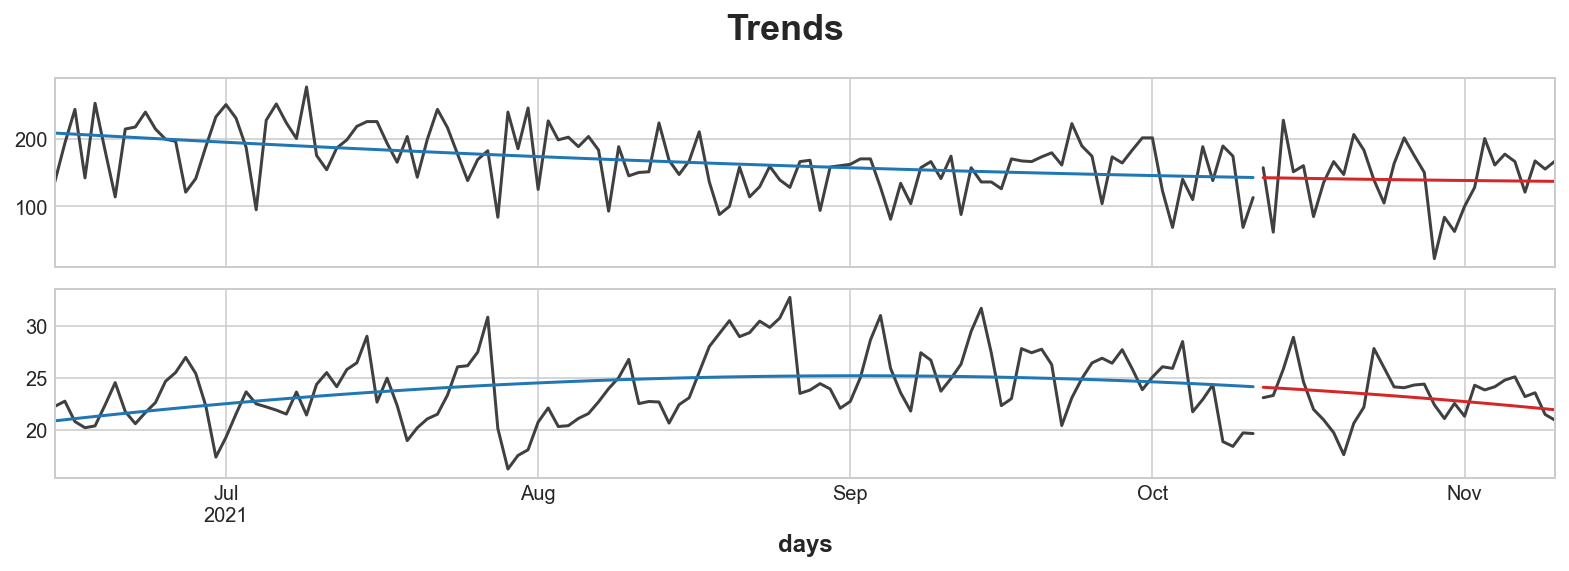

In [ ]:
ycd = cd.copy()

# Create trend features
dpcd = DeterministicProcess(
    index=ycd.index,  # dates from the training data
    constant=True,  # the intercept
    order=2,        # quadratic trend
    drop=True,      # drop terms to avoid collinearity
)
Xcd = dpcd.in_sample()  # features for the training data

# Test on the years 2016-2019. It will be easier for us later if we
# split the date index instead of the dataframe directly.
idx_traincd, idx_testcd = train_test_split(
    ycd.index, test_size=0.2, shuffle=False,
)


X_traincd, X_testcd = Xcd.loc[idx_traincd, :], Xcd.loc[idx_testcd, :]
y_traincd, y_testcd = ycd.loc[idx_traincd], ycd.loc[idx_testcd]

# Fit trend model
modelcd = LinearRegression(fit_intercept=False)
modelcd.fit(X_traincd, y_traincd)

# Make predictions
y_fitcd = pd.DataFrame(
    modelcd.predict(X_traincd),
    index=y_traincd.index,
    columns=y_traincd.columns,
)
y_predcd = pd.DataFrame(
    modelcd.predict(X_testcd),
    index=y_testcd.index,
    columns=y_testcd.columns,
)

# Plot
axs = y_traincd.plot(color='0.25', subplots=True, sharex=True)
axs = y_testcd.plot(color='0.25', subplots=True, sharex=True, ax=axs)
axs = y_fitcd.plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_predcd.plot(color='C3', subplots=True, sharex=True, ax=axs)
for ax in axs: ax.legend([])
_ = plt.suptitle("Trends")



rmse = mean_squared_error(y_traincd, y_fitcd, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")
rmse = mean_squared_error(y_testcd, y_predcd, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")

XGBOOST NECESSITA SEPARAR AS MULTIPLAS SERIES PARA PREDIZER. INVES DE FAZER UMA SERIE POR COLUNA, USAMOS AS SERIES INDEXADAS PELAS LINHAS.

In [ ]:
# The `stack` method converts column labels to row labels, pivoting from wide format to long
Xcd = cd.stack()  # pivot dataset wide to long
display(Xcd.head())
ycd = Xcd.pop('Sales')  # grab target series

Sales
days       Industries             
2021-06-14 num_prod     136.000000
           Temperatura   22.286713
2021-06-15 num_prod     193.000000
           Temperatura   22.783251
2021-06-16 num_prod     243.000000

ASSIM O XGBOOST CONSEGUE APRENDER E DISTINGUIR ESSAS DUAS SERIES, MODIFICAREMOS AS LINHAS DE INDUSTRIES EM CATEGORICA COM LABEL ENCODING E CRIAREMOS UMA FEATURE DE SAZONALIDADE COM NUMERO DA SEMANA NO MES E COM NUMERO DO DIA NO MES. NECESSITA REPETIR, VEREMOS QUE A QUE ESTAMOS USANDO EM SEMANA NAO SERA MTO EFICIENTE PQ A SAZONALIDADE ESTÁ ENTRE AS SEMANAS DO MES E VIMOS QUE NAO TEM MUITA

In [ ]:
# Turn row labels into categorical feature columns with a label encoding
Xcd = Xcd.reset_index('Industries')


# Label encoding for 'Industries' feature
for colname in Xcd.select_dtypes(["object", "category"]):
    Xcd[colname], _ = Xcd[colname].factorize()

Xcd

# Label encoding for annual seasonality
Xcd["day"] = Xcd.index.day # values are 1, 2, 3, ... 31
Xcd

# Create splits
X_traincd, X_testcd = Xcd.loc[idx_traincd, :], Xcd.loc[idx_testcd, :]
y_traincd, y_testcd = ycd.loc[idx_traincd], ycd.loc[idx_testcd]

Agora vamos converter as previsões de trend feitas anteriormente para o formato float e subtraí-las da serie original. Restando a série residual que o XGBOOST aprende

In [ ]:
# Pivot wide to long (stack) and convert DataFrame to Series (squeeze)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
y_fitcd = y_fitcd.stack().squeeze()    # trend from training set
y_predcd = y_predcd.stack().squeeze()  # trend from test set

# Create residuals (the collection of detrended series) from the training set
y_residcd = y_traincd - y_fitcd

est = [("XGB", XGBRegressor()),("LINEAR",LinearRegression()),
      ("Gradiente", GradientBoostingRegressor()), ("KNN",KNeighborsRegressor())]
# Train XGBoost on the residuals
#modelcd = VotingRegressor(est)
modelcd = KNeighborsRegressor()
#modelcd = GradientBoostingRegressor()
#modelcd = StackingRegressor(estimators=est, final_estimator=RandomForestRegressor())


#xgb = XGBRegressor()
modelcd.fit(X_traincd, y_residcd)

# Add the predicted residuals onto the predicted trends
y_fit_boostedcd = modelcd.predict(X_traincd) + y_fitcd
y_pred_boostedcd = modelcd.predict(X_testcd) + y_predcd


rmse = mean_squared_error(y_traincd, y_fit_boostedcd, squared = False)
print(f"RMSE train {rmse}")

rmse = mean_squared_error(y_testcd, y_pred_boostedcd, squared = False)
print(f"RMSE Test {rmse}")

RMSE train 25.386832087769804
RMSE Test 39.16897488996663


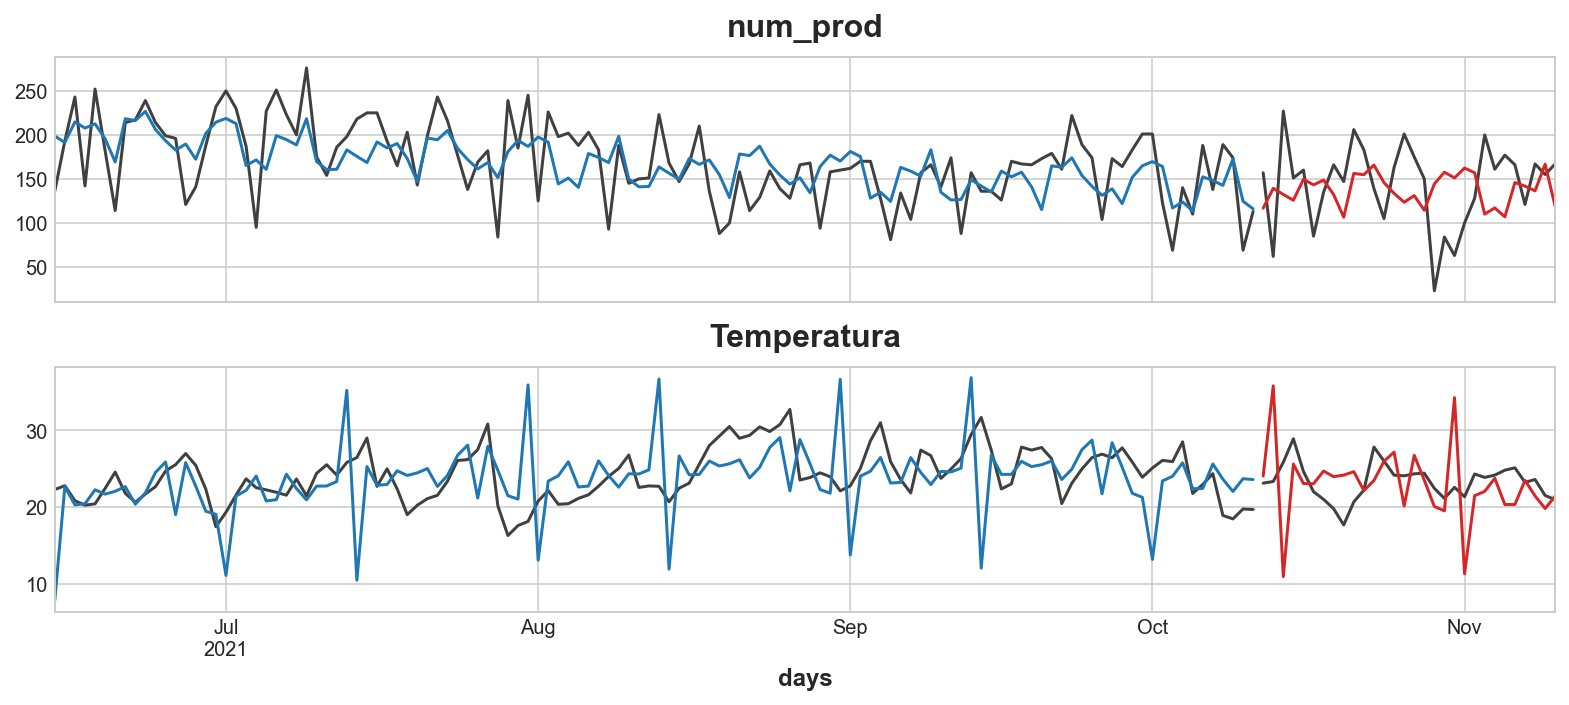

In [ ]:
axs = y_traincd.unstack(['Industries']).plot(
    color='0.25', figsize=(11, 5), subplots=True, sharex=True,
    title=['num_prod', 'Temperatura'],
)
axs = y_testcd.unstack(['Industries']).plot(
    color='0.25', subplots=True, sharex=True, ax=axs,
)
axs = y_fit_boostedcd.unstack(['Industries']).plot(
    color='C0', subplots=True, sharex=True, ax=axs,
)
axs = y_pred_boostedcd.unstack(['Industries']).plot(
    color='C3', subplots=True, sharex=True, ax=axs,
)
for ax in axs: ax.legend([])

### FORECASTING WITH MACHINE LEARNING

Problemas de lagging que vimos só podem ser aplicados a um futuro curto, porque eu precisaria do lag da target que estou tentando prever e no geral nao tenho, porque ainda nao ocorreu.

Para fazer previsões é necessario saber qual informação você tem **disponivel** (features) e qual o período de tempo que você necessita para prever esses valores.




para fazer predições temos os dados origin que seria o que temos, os dados futuros que são o horizonte que queremos prever e existe ainda o lead_time que seria o tempo entre um e outro, devido a delays na aquisição dos dados ou processamento dos mesmos. É o nosso caso para coleta de temperatura, por exemplo.

Para fazer previsões em time series com algoritmos de ML nos precisamos transformar a time series em um data frame, a menos que sejam apenas  features deterministicas como trend e sazonalidade.

Temos que preparar a target e isso depende da tarefa de predição. Cada linha no dataframe representa uma unica predição. O indice de tempo na primeira linha é o primeiro tempo do horizonte de previsão, mas nos arranjamos os valores para o horizonte inteiro na mesma linha. Por multiplos passos de previsao, isso significa que usamos o modelo para multiplas saidas, uma em cada passo.


In [ ]:
import numpy as np
import pandas as pd

N = 20
ts = pd.Series(
    np.arange(N),
    index=pd.period_range(start='2010', freq='A', periods=N, name='Year'),
    dtype=pd.Int8Dtype,
)

# Lag features
X = pd.DataFrame({
    'y_lag_2': ts.shift(2),
    'y_lag_3': ts.shift(3),
    'y_lag_4': ts.shift(4),
    'y_lag_5': ts.shift(5),
    'y_lag_6': ts.shift(6),
})

# Multistep targets
y = pd.DataFrame({
    'y_step_3': ts.shift(-2),
    'y_step_2': ts.shift(-1),
    'y_step_1': ts,
})

data = pd.concat({'Targets': y, 'Features': X}, axis=1)

data.head(10).style.set_properties(['Targets'], **{'background-color': 'LavenderBlush'}) \
                   .set_properties(['Features'], **{'background-color': 'Lavender'})

O Codigo acima mostra como o  dataset deve ser preparado para previsão de um problema com 3 passos de horizonte e duas de lead, necessitando 5 laggs. A serie temporal é y_step_1.

**Estratégias de Previsões multiplas**

Existe um numero grande de estrategias para produzir os multiplos passos para a target requeridos para a previsao. Vamos ver algumas com suas fraquezas e forças.

**Multipleoutput model**

Usar um modelo que produz multiplas saidas naturalmente. Regressao linear e redes neurais podem produzir multiplas saidas. Essa estratégia é simples e eficiente, mas não é possível para todos algoritmos, XGBoost nao consegue fazer isso, por exemplo. Prevê todas as targets de uma vez.

**Direct Strategy**

Treina o modelo separado para cada step do horizonte: um modelo prevê o primeiro step a frente, outro preve o segundo e assim por diante. Prever o primeiro é diferente de prever o segundo a frente e assim por diante. O problema deste modo é o gasto computacional.

**Recursive Strategy**

Treina o modelo para o primeiro step e usa as predições dele para preencher os lags das features para o próximo passo. Com esse modelo nós  alimentamos a previsão de um step do modelo de volta no mesmo modelo para usar como um atraso para a próxima previsão.  Nós apenas precisamos treinar o modelo, mas os erros sao propagados step por step e perde muito valor quando usa horizontes grandes.



**DirRec Strategy**

Uma combinação da estratégia direta com a recursiva: Treinamos o modelo para cada step e usamos as previsões dos steps anteriores como novos lags para as features step by step. Cada modelo ganha um input de lag adicional uma vez que cada modelo sempre tem um conjunto atualizado de features, esse modelo pode capturar melhor do que a forma direta, mas propaga erros como na recursiva.


VAMOS FAZER EXEMPLOS DE MULTIOUTPUTS E DIRECT STRATEGIES

Vamos considerar os dados diarios cd e os semanais ab

o horizonte para os diarios será de 10 dias e 1 de lead time e semanais de 3 semanas com 1 de lead time


In [ ]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds))
        preds.plot(ax=ax)
    return ax




Vamos preparar a target para o multistep forecasting.

In [ ]:

cd.columns = cd.columns.droplevel()

In [ ]:
def make_lags(ts, lags, lead_time=1):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(lead_time, lags + lead_time)
        },
        axis=1)


# Usaremos lag de 1 nas features(num_prod) e de os avanços na target
# Four weeks of lag features


ycd = cd.num_prod.copy()
Xcd = make_lags(ycd, lags=1).fillna(0.0)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)



# Eight-week forecast

ycd = make_multistep_target(ycd, steps=10).dropna()
# Shifting has created indexes that don't match. Only keep times for
# which we have both targets and features.

ycd, Xcd = ycd.align(Xcd, join='inner', axis=0)

Usaremos a regressao linear como estrategia de **Multi Output Strategy**, uma vez que os dados preparados possuem multiplas saidas, treinar e predizer é a mesma coisa.

Depois colocaremos a temperatura tambem para avaliar efeito

In [ ]:


# Create splits
X_traincd, X_testcd, y_traincd, y_testcd = train_test_split(Xcd, ycd, test_size=0.25, shuffle=False)

modelcd = LinearRegression()
modelcd.fit(X_traincd, y_traincd)

y_fitcd = pd.DataFrame(modelcd.predict(X_traincd), index=X_traincd.index, columns=ycd.columns)
y_predcd = pd.DataFrame(modelcd.predict(X_testcd), index=X_testcd.index, columns=ycd.columns)

Train RMSE Days: 41.92
Test RMSE Days: 54.39


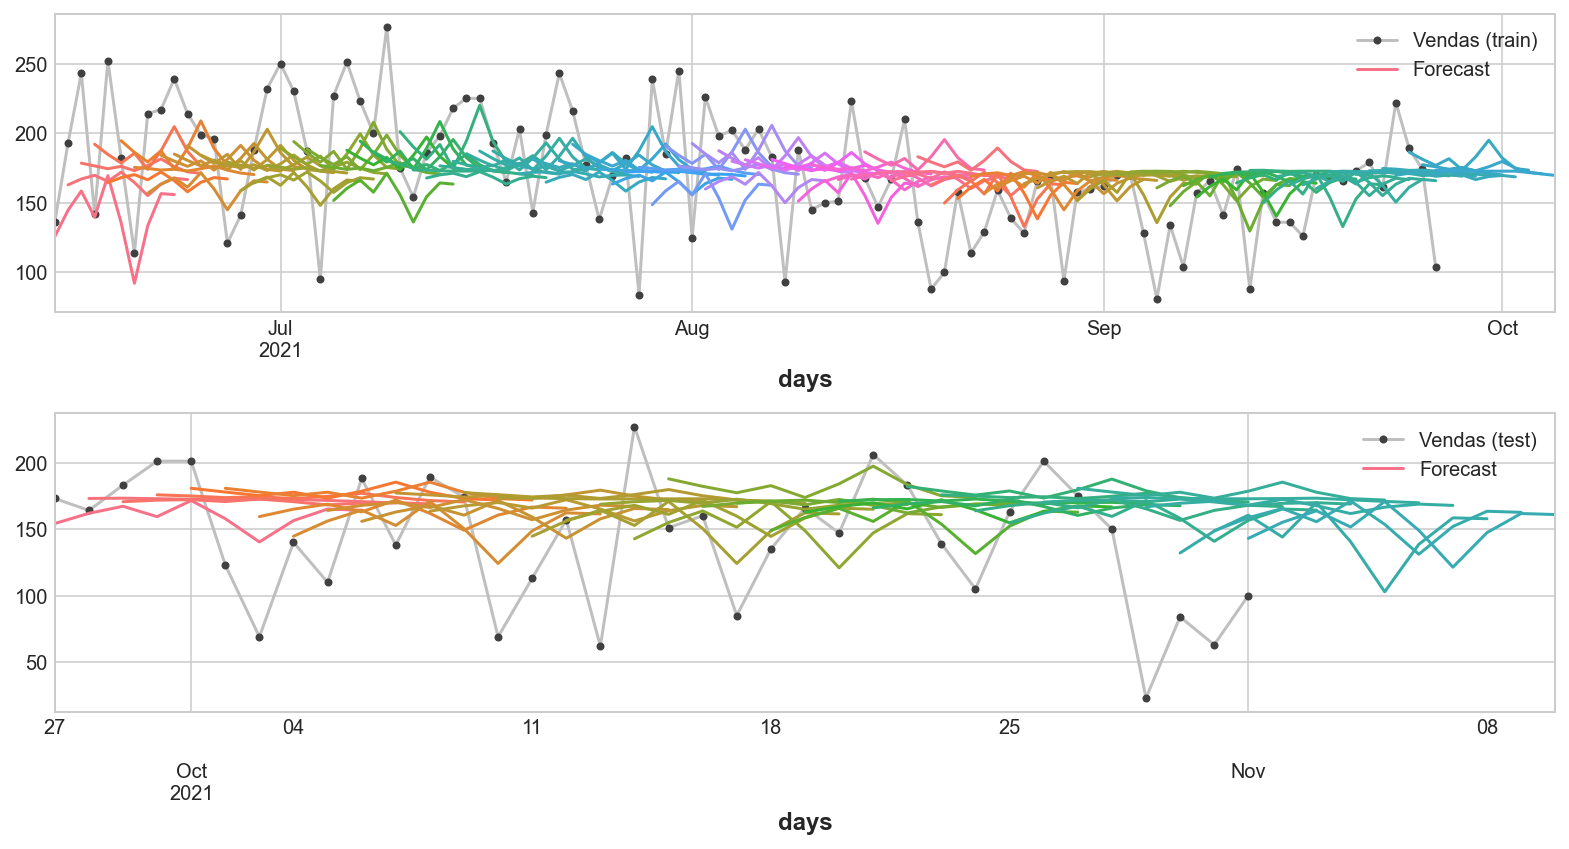

In [ ]:
train_rmsecd = mean_squared_error(y_traincd, y_fitcd, squared=False)
test_rmsecd = mean_squared_error(y_testcd, y_predcd, squared=False)
print((f"Train RMSE Days: {train_rmsecd:.2f}\n" f"Test RMSE Days: {test_rmsecd:.2f}"))

palettecd = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = cd.num_prod[y_fitcd.index].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fitcd, ax=ax1, palette_kwargs=palettecd)
_ = ax1.legend(['Vendas (train)', 'Forecast'])
ax2 = cd.num_prod[y_predcd.index].plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_predcd, ax=ax2, palette_kwargs=palettecd)
_ = ax2.legend(['Vendas (test)', 'Forecast'])

**Direct Strategy**

XGBoost nao faz multiple output mas aplicando o metodo de reducao direta podemos usar isso para prever muitos steps. É tao facil quanto puxar a função multioutput do scikitlearn rs

In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import VotingRegressor

est = [("XGB", XGBRegressor()),("LINEAR",LinearRegression()),
      ("Gradiente", GradientBoostingRegressor())]

model = VotingRegressor(est)
#model = GradientBoostingRegressor()
#model = StackingRegressor(estimators=est, final_estimator=RandomForestRegressor())

modelcd = MultiOutputRegressor(model)
modelcd.fit(X_traincd, y_traincd)

y_fitcd = pd.DataFrame(modelcd.predict(X_traincd), index = X_traincd.index, columns = ycd.columns)
y_predcd = pd.DataFrame(modelcd.predict(X_testcd), index = X_testcd.index, columns = ycd.columns)

Train RMSE Days: 26.53
Test RMSE Days: 57.06


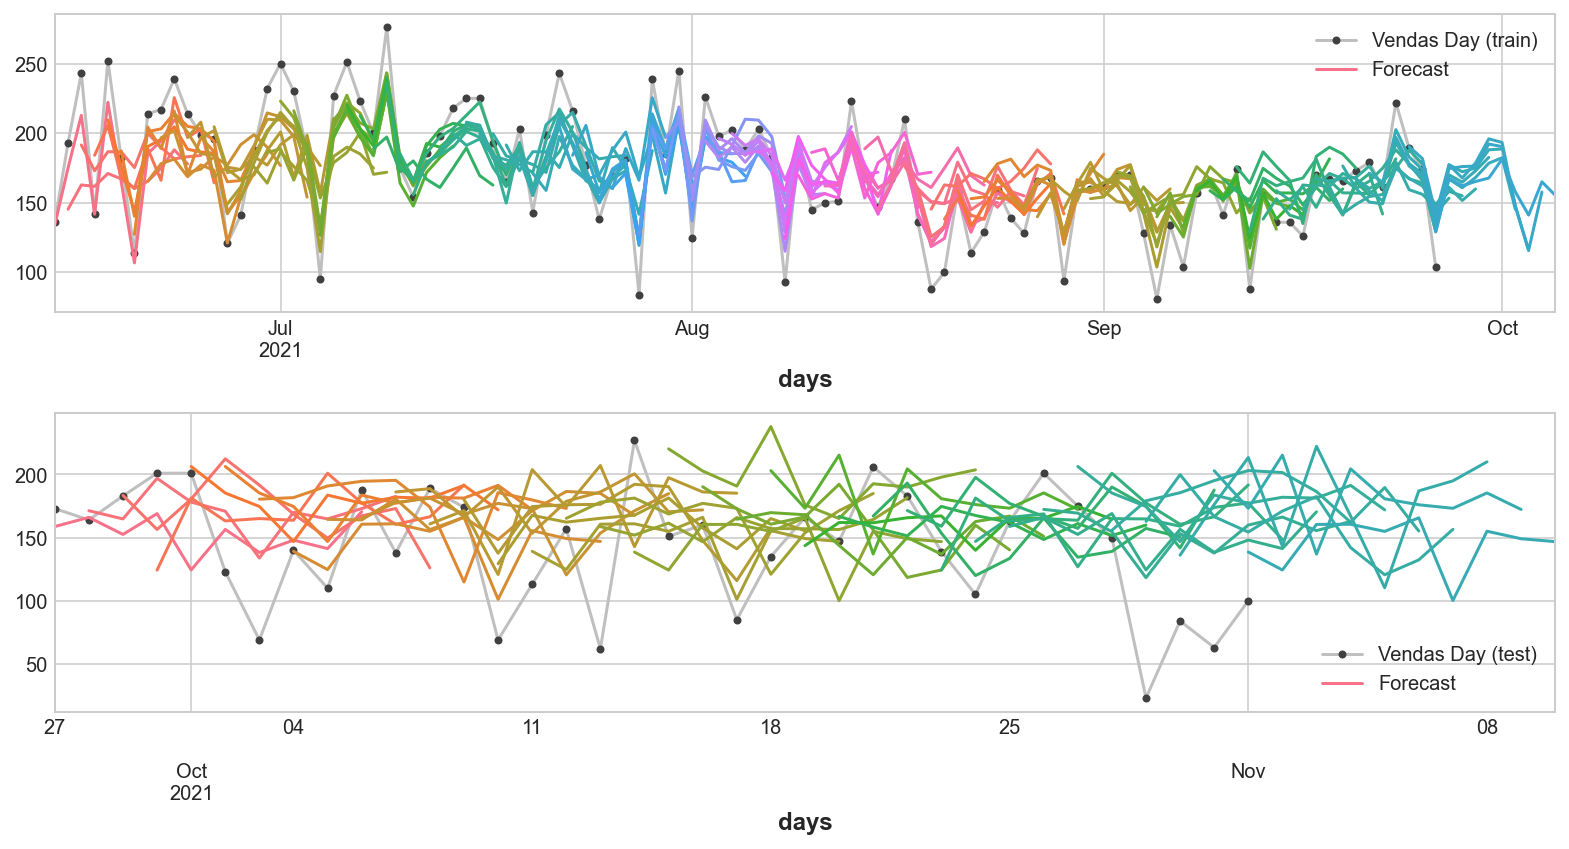

In [ ]:
train_rmsecd = mean_squared_error(y_traincd, y_fitcd, squared=False)
test_rmsecd = mean_squared_error(y_testcd, y_predcd, squared=False)
print((f"Train RMSE Days: {train_rmsecd:.2f}\n" f"Test RMSE Days: {test_rmsecd:.2f}"))

palettecd = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = cd.num_prod[y_fitcd.index].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fitcd, ax=ax1, palette_kwargs=palettecd)
_ = ax1.legend(['Vendas Day (train)', 'Forecast'])
ax2 = cd.num_prod[y_predcd.index].plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_predcd, ax=ax2, palette_kwargs=palettecd)
_ = ax2.legend(['Vendas Day (test)', 'Forecast'])

To use the DirRec strategy, you would only need to replace MultiOutputRegressor with another scikit-learn wrapper, RegressorChain. The Recursive strategy we would need to code ourselves.

Train RMSE Days: 38.70
Test RMSE Days: 54.70


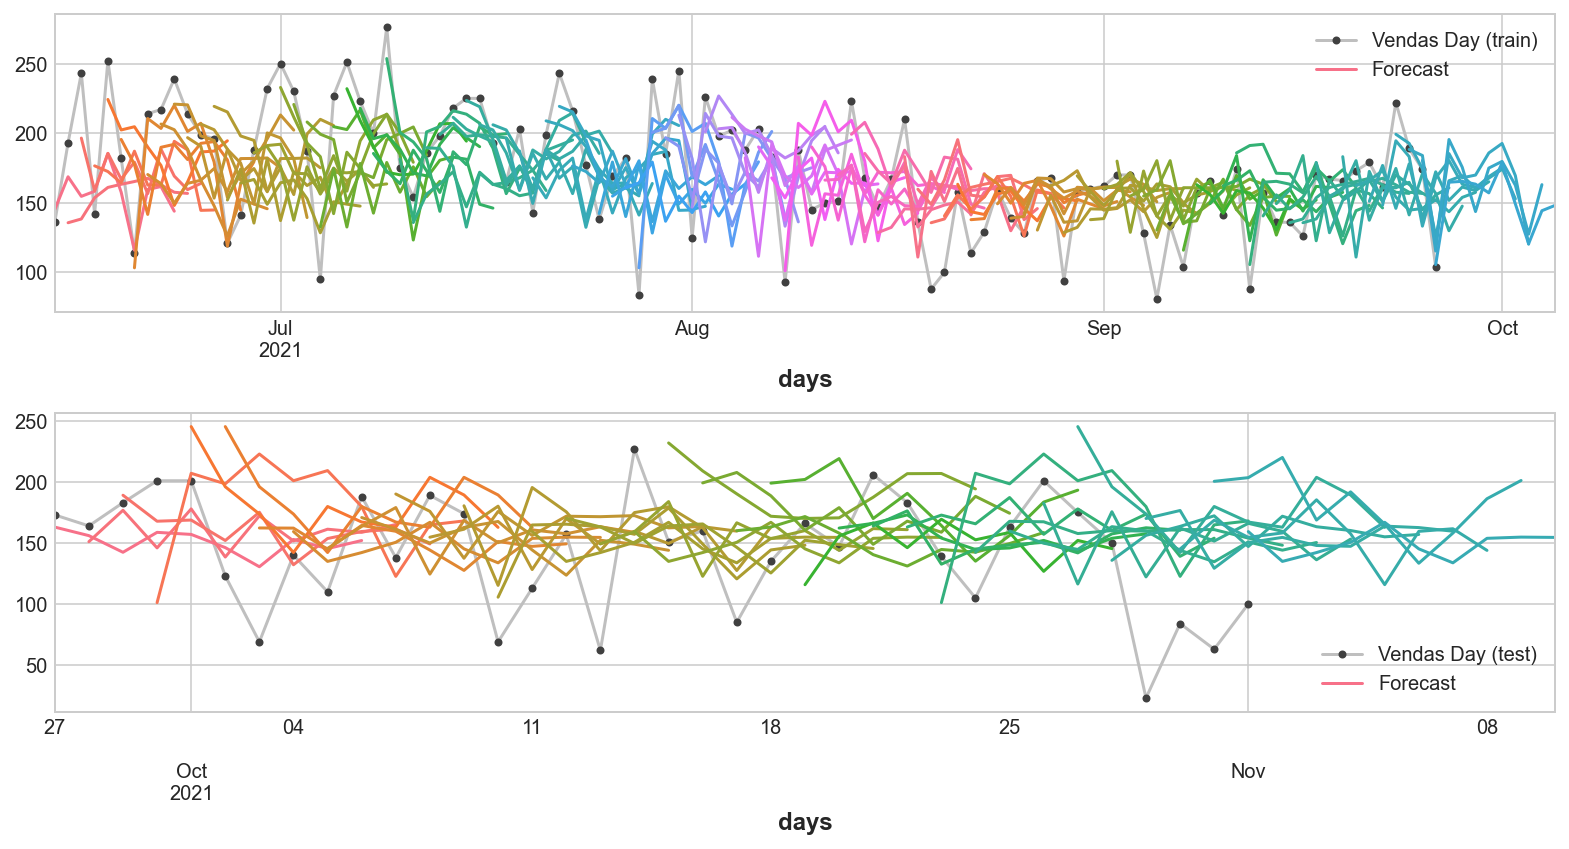

In [ ]:
from sklearn.multioutput import RegressorChain
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
est = [("LINEAR",LinearRegression()),
      ("Gradiente", GradientBoostingRegressor()),
      ("LGBM",LGBMRegressor()),("RF",RandomForestRegressor()),
      ("XGB",XGBRegressor())]

#model = VotingRegressor(est)
#model = LGBMRegressor(max_depth = 5)
#model = GradientBoostingRegressor(n_estimators=100, max_depth = 2)
#model = StackingRegressor(estimators=est, final_estimator=RandomForestRegressor())
model = RandomForestRegressor(n_estimators = 500)

modelcd = RegressorChain(model)
modelcd.fit(X_traincd, y_traincd)

y_fitcd = pd.DataFrame(modelcd.predict(X_traincd), index = X_traincd.index, columns = ycd.columns)
y_predcd = pd.DataFrame(modelcd.predict(X_testcd), index = X_testcd.index, columns = ycd.columns)


train_rmsecd = mean_squared_error(y_traincd, y_fitcd, squared=False)
test_rmsecd = mean_squared_error(y_testcd, y_predcd, squared=False)
print((f"Train RMSE Days: {train_rmsecd:.2f}\n" f"Test RMSE Days: {test_rmsecd:.2f}"))

palettecd = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = cd.num_prod[y_fitcd.index].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fitcd, ax=ax1, palette_kwargs=palettecd)
_ = ax1.legend(['Vendas Day (train)', 'Forecast'])
ax2 = cd.num_prod[y_predcd.index].plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_predcd, ax=ax2, palette_kwargs=palettecd)
_ = ax2.legend(['Vendas Day (test)', 'Forecast'])

In [ ]:
train_rmsecd = mean_squared_error(y_traincd, y_fitcd, squared=False)
test_rmsecd = mean_squared_error(y_testcd, y_predcd, squared=False)
print((f"Train RMSE Days: {train_rmsecd:.2f}\n" f"Test RMSE Days: {test_rmsecd:.2f}"))


# Make predictions
y_fitcd = pd.DataFrame(
    modelcd.predict(X_traincd),
    index=y_traincd.index,
    columns=[y_traincd.name],
)
y_predcd = pd.DataFrame(
    modelcd.predict(X_testcd),
    index=y_testcd.index,
    columns=[y_testcd.name],
)

# Plot
axs = y_traincd.plot(color='0.25', subplots=True, sharex=True)
axs = y_testcd.plot(color='0.25', subplots=True, sharex=True, ax=axs)
axs = y_fitcd.plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_predcd.plot(color='C3', subplots=True, sharex=True, ax=axs)
for ax in axs: ax.legend([])
_ = plt.suptitle("Trends")





Train RMSE Days: 38.70
Test RMSE Days: 54.70


AttributeError: 'DataFrame' object has no attribute 'name'

### UNIR AS TRENDS LINEAR COM MODELO XGBOOST USANDO TEMPERATURA E TUDO O MAIS

In [ ]:

cd["num_prod_LAG_1"] = cd["num_prod"].shift()
cd = cd.fillna(130)

cd["Dif_week"] = cd["num_prod_LAG_1"].diff()

cd = cd.fillna(5)
Xcd =cd.drop("num_prod", axis = 1)
ycd = cd["num_prod"]

In [ ]:
cd.corr()

Industries,num_prod,Temperatura,num_prod_LAG_1,Dif_week
Industries,,,,
num_prod,1.000000,-0.258750,0.317581,0.073535
Temperatura,-0.258750,1.000000,-0.131147,-0.045362
num_prod_LAG_1,0.317581,-0.131147,1.000000,0.581533
Dif_week,0.073535,-0.045362,0.581533,1.000000


DIF_WEEK É INUTIL, SÓ TEMPERATURA E FALTOU O NUMERO DA SEMANA

In [ ]:

cd["Dia"] = range(1,len(cd["Temperatura"])+1)


In [ ]:
cd = cd.drop("Dif_week",axis = 1)


In [ ]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from xgboost import XGBRegressor


simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc(
    "figure",
    autolayout=True,
    figsize=(11, 4),
    titlesize=18,
    titleweight='bold',
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)


In [ ]:
cd

Industries,num_prod,Temperatura,num_prod_LAG_1,Dia
days,,,,
2021-06-14,136,22.286713,130.0,1
2021-06-15,193,22.783251,136.0,2
...,...,...,...,...
2021-11-09,155,21.509677,167.0,149
2021-11-10,167,20.952096,155.0,150


In [ ]:
cd["day_log"] = np.log(cd["Dia"])
cd["day_squared"] = cd["Dia"]**2
Xcd = cd.drop("num_prod", axis =1)
Xcd = cd[["Dia","day_log"]]
ycd = cd["num_prod"]


Train RMSE Days: 39.17

Test RMSE Days: 39.17



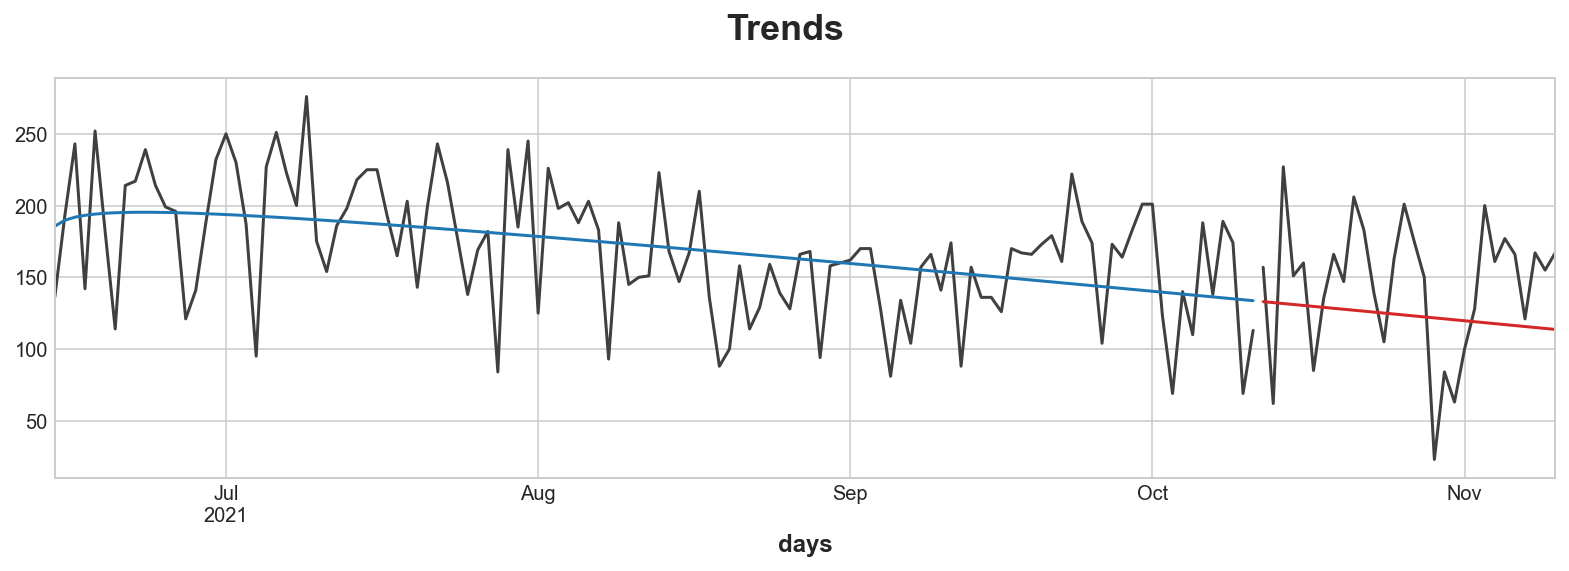

In [ ]:
# Test on the years 2016-2019. It will be easier for us later if we
# split the date index instead of the dataframe directly.
idx_traincd, idx_testcd = train_test_split(
    ycd.index, test_size=0.2, shuffle=False,
)


X_traincd, X_testcd = Xcd.loc[idx_traincd, :], Xcd.loc[idx_testcd, :]
y_traincd, y_testcd = ycd.loc[idx_traincd], ycd.loc[idx_testcd]

# Fit trend model
modelcd = LinearRegression(fit_intercept=True)
modelcd.fit(X_traincd, y_traincd)

# Make predictions
y_fitcd = pd.DataFrame(
    modelcd.predict(X_traincd),
    index=y_traincd.index,
    columns=[y_traincd.name],
)
y_predcd = pd.DataFrame(
    modelcd.predict(X_testcd),
    index=y_testcd.index,
    columns=[y_testcd.name],
)

# Plot
axs = y_traincd.plot(color='0.25', subplots=True, sharex=True)
axs = y_testcd.plot(color='0.25', subplots=True, sharex=True, ax=axs)
axs = y_fitcd.plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_predcd.plot(color='C3', subplots=True, sharex=True, ax=axs)
for ax in axs: ax.legend([])
_ = plt.suptitle("Trends")

rmsecd = mean_squared_error(y_traincd, y_fitcd, squared=False)

print(f"Train RMSE Days: {rmse:.2f}\n")
rmsecd = mean_squared_error(y_testcd, y_predcd, squared=False)

print(f"Test RMSE Days: {rmse:.2f}\n")

In [ ]:

Xcd = cd[["num_prod_LAG_1", "Temperatura"]]



X_traincd, X_testcd = Xcd.loc[idx_traincd, :], Xcd.loc[idx_testcd, :]
y_traincd, y_testcd = ycd.loc[idx_traincd], ycd.loc[idx_testcd]

In [ ]:
# Pivot wide to long (stack) and convert DataFrame to Series (squeeze)
from sklearn.neighbors import KNeighborsRegressor



# Create residuals (the collection of detrended series) from the training set
y_residcd = y_traincd - y_fitcd.T
y_residcd = y_residcd.T

est = [("XGB", XGBRegressor()),("LINEAR",LinearRegression()),
      ("Gradiente", GradientBoostingRegressor()), ("KNN",KNeighborsRegressor())]
# Train XGBoost on the residuals
modelcd = VotingRegressor(est)
#modelcd = KNeighborsRegressor()
#modelcd = GradientBoostingRegressor()
#modelcd = StackingRegressor(estimators=est, final_estimator=RandomForestRegressor())


#xgb = XGBRegressor()
modelcd.fit(X_traincd, y_residcd)

# Add the predicted residuals onto the predicted trends
y_fit_boostedcd = modelcd.predict(X_traincd) + y_fitcd.T
y_fit_boostedcd = y_fit_boostedcd.T
y_pred_boostedcd = modelcd.predict(X_testcd) + y_predcd.T
y_pred_boostedcd = y_pred_boostedcd.T

rmse = mean_squared_error(y_traincd, y_fit_boostedcd, squared = False)
print(f"RMSE train {rmse}")

rmse = mean_squared_error(y_testcd, y_pred_boostedcd, squared = False)
print(f"RMSE Test {rmse}")

RMSE train 20.550757068633693
RMSE Test 53.999171565844875


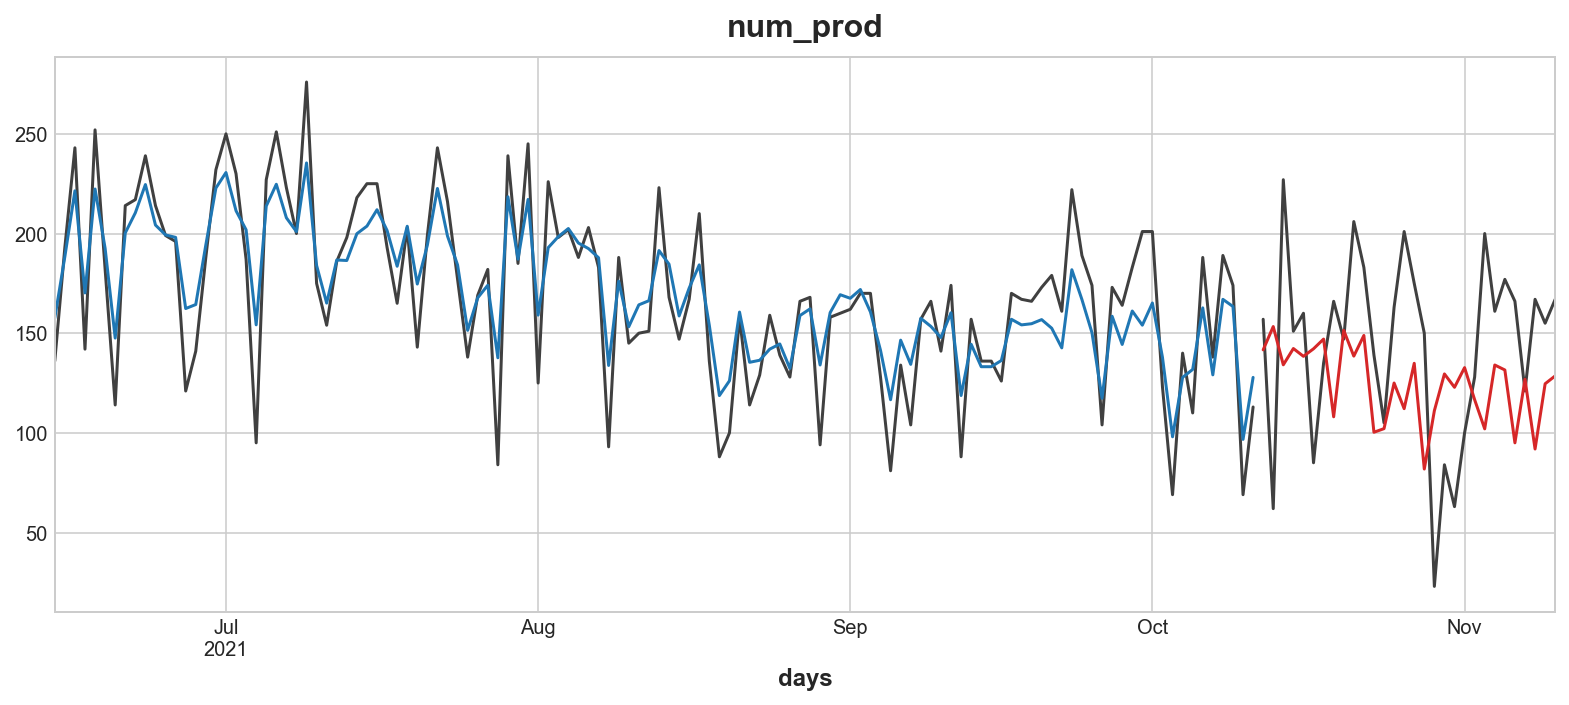

In [ ]:
axs = y_traincd.plot(
    color='0.25', figsize=(11, 5), subplots=True, sharex=True,
    title=['num_prod'],
)
axs = y_testcd.plot(
    color='0.25', subplots=True, sharex=True, ax=axs,
)
axs = y_fit_boostedcd.plot(
    color='C0', subplots=True, sharex=True, ax=axs,
)
axs = y_pred_boostedcd.plot(
    color='C3', subplots=True, sharex=True, ax=axs,
)
for ax in axs: ax.legend([])

# AULAS